## LIBRARIES


In [466]:
import json
import random
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
## NLP
import re
import spacy
## Language detection for cleaning
!pip install langdetect
from langdetect import detect, LangDetectException
from spacy.matcher import PhraseMatcher

## DATA IMPORT, CLEANING, MERGING META WITH REVIEWS

In [180]:
chunks = []

for chunk in pd.read_json(
    "Sports_and_Outdoors.jsonl",
    lines=True,
    chunksize=10000
):
    chunk["review_date"] = pd.to_datetime(chunk["timestamp"], unit="ms")
    chunk = chunk[chunk["review_date"] >= "2021-01-01"]
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

print(df.shape)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1038a9e80>>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


(5486533, 11)


In [181]:
with open("Sports_and_Outdoors.jsonl", "r", encoding="utf-8") as f:
    first_review = json.loads(next(f))

print(first_review.keys())

dict_keys(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'])


In [182]:
# Products with at least one helpful review
products_with_helpful = df.loc[df["helpful_vote"] > 0, "parent_asin"].nunique()

# Total products
total_products = df["parent_asin"].nunique()

print(f"Products with at least one helpful review: {products_with_helpful:,}")
print(f"Total products: {total_products:,}")
print(f"Percentage: {products_with_helpful / total_products:.2%}")

Products with at least one helpful review: 205,973
Total products: 583,929
Percentage: 35.27%


In [183]:
product_helpful = (
    df_2022.groupby("parent_asin")["helpful_vote"]
    .apply(lambda x: (x > 0).sum())
)

print(f">= 1 helpful review: {(product_helpful >= 1).sum():,}")
print(f">= 5 helpful reviews: {(product_helpful >= 5).sum():,}")
print(f">= 10 helpful reviews: {(product_helpful >= 10).sum():,}")
print(f">= 20 helpful reviews: {(product_helpful >= 20).sum():,}")
print(f">= 50 helpful reviews: {(product_helpful >= 50).sum():,}")

>= 1 helpful review: 38,241
>= 5 helpful reviews: 19,684
>= 10 helpful reviews: 8,604
>= 20 helpful reviews: 1,722
>= 50 helpful reviews: 31


In [184]:
# ==========================================================
# STEP 1 - Products with at least 15 helpful reviews
# ==========================================================

product_helpful = (
    df_2022.groupby("parent_asin")["helpful_vote"]
    .apply(lambda x: (x > 0).sum())
)

selected_products = product_helpful[
    product_helpful >= 15
].index

# ==========================================================
# STEP 2 - Keep only selected products
# ==========================================================

df_selected = df_2022[
    df_2022["parent_asin"].isin(selected_products)
].copy()

print("=" * 50)
print("SELECTED DATASET")
print("=" * 50)

print(f"Reviews: {len(df_selected):,}")
print(f"Products: {df_selected['parent_asin'].nunique():,}")
print(f"Users: {df_selected['user_id'].nunique():,}")

print("\nHelpful reviews (>0):")
print((df_selected["helpful_vote"] > 0).sum())

print("\nAverage reviews per product:")
print(
    round(
        df_selected.groupby("parent_asin").size().mean(),
        2
    )
)

print("\nMaximum reviews per product:")
print(
    df_selected.groupby("parent_asin").size().max()
)

print("\nMinimum reviews per product:")
print(
    df_selected.groupby("parent_asin").size().min()
)

print("\nRatings:")
print(df_selected["rating"].value_counts().sort_index())

print("\nDate range:")
print(df_selected["review_date"].min())
print(df_selected["review_date"].max())

SELECTED DATASET
Reviews: 163,165
Products: 3,819
Users: 153,791

Helpful reviews (>0):
80910

Average reviews per product:
42.72

Maximum reviews per product:
99

Minimum reviews per product:
15

Ratings:
rating
1.0     21558
2.0      9142
3.0     12254
4.0     19225
5.0    100986
Name: count, dtype: int64

Date range:
2022-01-01 00:01:15.532000
2022-12-31 23:58:00.055000


In [185]:
## META DATA

In [186]:
with open("meta_Sports_and_Outdoors.jsonl", "r", encoding="utf-8") as f:
    first = json.loads(next(f))

print(first.keys())

dict_keys(['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together'])


In [187]:
selected_products = set(df_selected["parent_asin"].unique())

print(len(selected_products))

3819


In [ ]:
meta_rows = []

with open("meta_Sports_and_Outdoors.jsonl", "r", encoding="utf-8") as f:

    for line in f:

        product = json.loads(line)

        if product["parent_asin"] in selected_products:

            meta_rows.append(product)

In [24]:
meta_df = pd.DataFrame(meta_rows)

In [25]:
meta_df = meta_df.rename(columns={"title": "product_title"})

In [28]:
meta_df = meta_df[
    [
        "parent_asin",
        "product_title",
        "store",
        "main_category",
        "categories",
        "price",
        "average_rating",
        "rating_number",
        "features"
    ]
]
print(meta_df.shape)

meta_df.head()

(3819, 9)


,parent_asin,product_title,store,main_category,categories,price,average_rating,rating_number,features
0,B0C2YRHBZZ,YZLSPORTS Metal Black Heavy Hand Grip and Wris...,YZLSPORTS,Sports & Outdoors,"[Sports & Outdoors, Exercise & Fitness, Streng...",9.99,4.4,1738,[✅Choice:100LBS hand gripper is suitable(ladie...
1,B018LIR2Q2,Brunswick Tzone Deep Space Bowling Ball,Brunswick,Sports & Outdoors,"[Sports & Outdoors, Sports, Leisure Sports & G...",61.03,4.7,2511,"[Features bullet point core, Finished with Roy..."
2,B09FJGT9XP,MEETSUN Polarized Sunglasses for Men Women Cla...,MEETSUN,AMAZON FASHION,"[Sports & Outdoors, Sports & Outdoor Recreatio...",15.99,4.4,868,[MEN’S POLARIZED SUNGLASSES - HD polarized tec...
3,B0842CF8YD,YETI Roadie 24 Cooler,YETI,Sports & Outdoors,"[Sports & Outdoors, Outdoor Recreation, Campin...",250.00,4.8,5895,[The Roadie 24 is 10% lighter in weight and ho...
4,B07MHM3D68,ASICS Kid's Matflex 6 Grade School Wrestling S...,ASICS,AMAZON FASHION,"[Sports & Outdoors, Sports, Team Sports, Other...",54.90,4.7,3070,"[100% Synthetic, Imported, Rubber sole, EVA So..."


In [29]:
df_final = df_selected.merge(
    meta_df,
    on="parent_asin",
    how="left"
)

In [31]:
df_final["main_category"].isna().sum()

np.int64(13953)

In [32]:
df_final["main_category"] = df_final["main_category"].fillna("Unknown")

In [33]:
missing = (
    df_final[
        [
            "product_title",
            "store",
            "main_category",
            "categories",
            "price",
            "average_rating",
            "rating_number",
            "features"
        ]
    ]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing)

price             12293
store               215
product_title         0
main_category         0
categories            0
average_rating        0
rating_number         0
features              0
dtype: int64


In [36]:
df_final = df_final.drop(columns="timestamp")

## FINAL DF DATA CLEANING

In [46]:
df_final["categories"].apply(tuple).unique()

array([('Sports & Outdoors', 'Exercise & Fitness', 'Strength Training Equipment', 'Racks & Cages', 'Power Cages'),
       ('Sports & Outdoors', 'Hunting & Fishing', 'Fishing', 'Accessories', 'Fishing Hats'),
       ('Sports & Outdoors', 'Outdoor Recreation', 'Camping & Hiking', 'Sleeping Bags & Camp Bedding', 'Foam Sleeping Mats'),
       ('Sports & Outdoors', 'Exercise & Fitness', 'Cardio Training', 'Rowers'),
       ('Sports & Outdoors', 'Outdoor Recreation', 'Camping & Hiking', 'Camp Kitchen', 'Freeze-Dried Food'),
       ('Sports & Outdoors', 'Outdoor Recreation', 'Camping & Hiking', 'Backpacks, Bags & Accessories', 'Backpacking Packs', 'Hiking Daypacks'),
       ('Sports & Outdoors', 'Outdoor Recreation', 'Camping & Hiking', 'Hydration & Filtration', 'Water Filters'),
       ('Sports & Outdoors', 'Outdoor Recreation', 'Camping & Hiking', 'Lights & Lanterns', 'Lanterns', 'Electric Lanterns'),
       ('Sports & Outdoors', 'Outdoor Recreation', 'Camping & Hiking', 'Camping Furniture'

In [47]:
# ==========================================================
# Extract category hierarchy
# ==========================================================

def extract_categories(cat_list):
    if not isinstance(cat_list, list):
        return pd.Series([None, None, None])

    # Remove the redundant first level
    if len(cat_list) > 0 and cat_list[0] == "Sports & Outdoors":
        cat_list = cat_list[1:]

    category = cat_list[0] if len(cat_list) > 0 else None
    subcategory = cat_list[1] if len(cat_list) > 1 else None
    product_group = cat_list[2] if len(cat_list) > 2 else None

    return pd.Series([category, subcategory, product_group])


df_final[["category", "subcategory", "product_group"]] = (
    df_final["categories"]
    .apply(extract_categories)
)

# Remove the original nested list
df_final = df_final.drop(columns="categories")

In [48]:
df_final.head()

,rating,title,text,asin,parent_asin,user_id,helpful_vote,verified_purchase,review_date,has_images,...,product_title,store,main_category,price,average_rating,rating_number,features,category,subcategory,product_group
0,5.0,Works as advertised,One of the beams arrived bent. I emailed the ...,B08LBQHRRT,B0BV5YVW94,AHE3DATFMO3Z3ETDV7AVGVVP4V2A,3,True,2022-12-16 04:23:51.415,False,...,ZENOVA Squat Rack with Pull Up Bar Power Rack ...,ZENOVA,Unknown,346.99,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages
1,4.0,Great value weight/fitness rack,"Set up was not bad, even for one person. Stur...",B08LBQHRRT,B0BV5YVW94,AEMEXZV5C3IFY5JXZHCMRJ2OR6UA,1,True,2022-12-22 19:25:43.487,False,...,ZENOVA Squat Rack with Pull Up Bar Power Rack ...,ZENOVA,Unknown,346.99,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages
2,1.0,"The quality is just ""wow."" And in such a horri...",It looks and feels like a kids Tonka Toy. The ...,B094NFVJCW,B0BV5YVW94,AGNFWBS6EQHRSWTGMM564XFDH66A,0,True,2022-04-05 14:34:28.194,False,...,ZENOVA Squat Rack with Pull Up Bar Power Rack ...,ZENOVA,Unknown,346.99,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages
3,3.0,Manufacturing defect.,One side has holes drilled but the opposite do...,B08LBQHRRT,B0BV5YVW94,AGERO4RR7NJCVIAGISRM4PXAYMQA,0,True,2022-10-25 00:11:22.075,True,...,ZENOVA Squat Rack with Pull Up Bar Power Rack ...,ZENOVA,Unknown,346.99,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages
4,5.0,Great budget at home rack,A little wobbly when you re-rack a heavy squat...,B08LBQHRRT,B0BV5YVW94,AG6YH5TTF2VKPW2CAO2L5OQZ536A,3,True,2022-12-10 19:25:54.614,False,...,ZENOVA Squat Rack with Pull Up Bar Power Rack ...,ZENOVA,Unknown,346.99,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages


In [50]:
df_final.describe()


,rating,helpful_vote,review_date,review_length,word_count,title_length,is_helpful,price,average_rating,rating_number
count,163165.000000,163165.000000,163165,163165.000000,163165.000000,163165.000000,163165.000000,150872.000000,163165.000000,163165.000000
mean,4.035387,1.637214,2022-07-22 02:52:18.232033536,258.416057,48.699936,24.068710,0.495878,103.849254,4.385004,1407.213575
min,1.000000,0.000000,2022-01-01 00:01:15.532000,1.000000,1.000000,1.000000,0.000000,2.890000,1.800000,1.000000
25%,3.000000,0.000000,2022-05-09 16:35:35.123000064,69.000000,13.000000,12.000000,0.000000,21.990000,4.300000,385.000000
50%,5.000000,0.000000,2022-07-31 20:52:16.867000064,154.000000,29.000000,20.000000,0.000000,39.990000,4.400000,766.000000
75%,5.000000,2.000000,2022-10-08 20:26:49.139000064,310.000000,59.000000,31.000000,1.000000,99.990000,4.600000,1576.000000
max,5.000000,420.000000,2022-12-31 23:58:00.055000,11677.000000,2130.000000,100.000000,1.000000,2799.000000,5.000000,90349.000000
std,1.451211,4.930466,NaN,358.919888,66.719353,16.259313,0.499985,196.124165,0.290237,2472.978538


In [51]:
df_final.nlargest(10, "review_length")[
    ["rating", "helpful_vote", "review_length", "title"]
]

,rating,helpful_vote,review_length,title
27445,3.0,2,11677,"Rough Initial Impression, Rough Experience Wit..."
58710,2.0,2,11244,Only an 8 mile real-world range with quality i...
145532,3.0,15,9871,Full Review and Updates on 1Plus Scooter
131524,5.0,0,9240,What a BEAST!!
87145,5.0,6,9130,SO Much More Than A Toy! This Changed My Mind ...
97646,5.0,57,8275,"TOSY UltraLED Receives ""Glowing"" Review"
47698,5.0,17,8204,"What you need to know about certifications, EP..."
137765,5.0,119,8079,Make mountains into molehills
152805,4.0,63,7629,"Affordable E-Bike, Worth Every Penny"
48746,4.0,49,7476,The end result will be a reflection of your pr...


In [ ]:
## Detect languages

def detect_language(text):

    try:
        return detect(str(text))

    except LangDetectException:
        return "unknown"

df_final["language"] = df_final["review"].apply(detect_language)

## Leave only English reviews

df_all = df_final.copy()

df_final = df_final[
    df_final["language"] == "en"
].copy()

df_final.drop(columns="language", inplace=True)

## EDA

In [52]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("========== DATASET OVERVIEW ==========\n")

print(f"Total reviews: {len(df_final):,}")
print(f"Unique products: {df_final['parent_asin'].nunique():,}")
print(f"Unique variants (ASIN): {df_final['asin'].nunique():,}")
print(f"Unique brands: {df_final['store'].nunique():,}")

print(f"\nAverage rating: {df_final['rating'].mean():.2f}")
print(f"Helpful review rate: {df_final['is_helpful'].mean()*100:.1f}%")
print(f"Verified purchase rate: {df_final['verified_purchase'].mean()*100:.1f}%")

========== DATASET OVERVIEW ==========

Total reviews: 163,165
Unique products: 3,819
Unique variants (ASIN): 17,615
Unique brands: 2,631

Average rating: 4.04
Helpful review rate: 49.6%
Verified purchase rate: 90.4%


In [54]:
# Distribution of the target variable
df_final["is_helpful"].value_counts()

is_helpful
0    82255
1    80910
Name: count, dtype: int64

In [55]:
df_final["is_helpful"].value_counts(normalize=True) * 100

is_helpful
0    50.412159
1    49.587841
Name: proportion, dtype: float64

In [56]:
df_final["helpful_vote"].describe()

count    163165.000000
mean          1.637214
std           4.930466
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         420.000000
Name: helpful_vote, dtype: float64

In [57]:
df_final["helpful_vote"].value_counts().head(20)

helpful_vote
0     82255
1     38157
2     15879
3      8367
4      4947
5      3170
6      2104
7      1559
8      1154
9       870
10      697
11      571
12      436
13      352
14      294
15      234
16      215
17      185
18      175
19      143
Name: count, dtype: int64

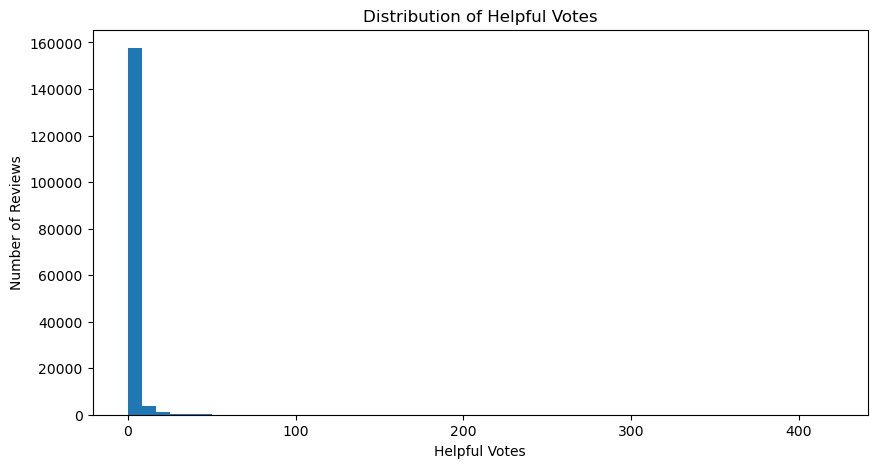

In [60]:
plt.figure(figsize=(10, 5))

plt.hist(df_final["helpful_vote"], bins=50)

plt.title("Distribution of Helpful Votes")
plt.xlabel("Helpful Votes")
plt.ylabel("Number of Reviews")

plt.show()

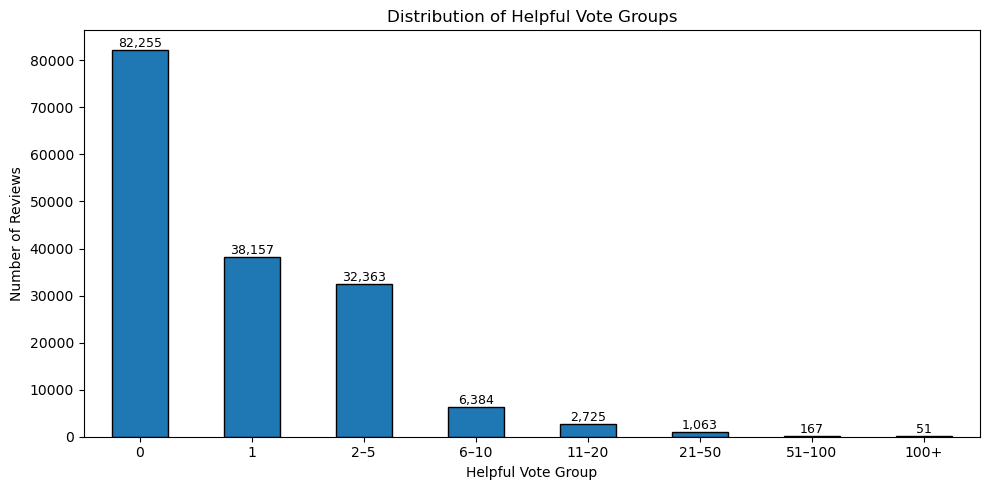

In [63]:
# Create helpful vote groups
bins = [-1, 0, 1, 5, 10, 20, 50, 100, float("inf")]
labels = [
    "0",
    "1",
    "2–5",
    "6–10",
    "11–20",
    "21–50",
    "51–100",
    "100+"
]

df_final["helpful_group"] = pd.cut(
    df_final["helpful_vote"],
    bins=bins,
    labels=labels
)

counts = df_final["helpful_group"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = counts.plot(kind="bar", edgecolor="black")

# Add count labels
for i, value in enumerate(counts):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Distribution of Helpful Vote Groups")
plt.xlabel("Helpful Vote Group")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [64]:
# Negative (1–3 stars) reviews with at least 20 helpful votes

negative_influential = df_2022[
    (df_2022["rating"] <= 3) &
    (df_2022["helpful_vote"] >= 20)
]

print(f"Negative influential reviews: {len(negative_influential):,}")

print("\nBy rating:")
print(negative_influential["rating"].value_counts().sort_index())

Negative influential reviews: 341

By rating:
rating
1.0    164
2.0     46
3.0    131
Name: count, dtype: int64


In [65]:
negative_influential = df_final[
    (df_final["rating"] <= 3) &
    (df_final["helpful_vote"] >= 20)
]

print(f"Negative influential reviews: {len(negative_influential):,}")

print("\nBy rating:")
print(negative_influential["rating"].value_counts().sort_index())

Negative influential reviews: 241

By rating:
rating
1.0    111
2.0     30
3.0    100
Name: count, dtype: int64


In [68]:
# ORIGINAL 2022 DATASET
count_original = (
    (df_2022["helpful_vote"] >= 10)
).sum()

print(f"Original 2022: {count_original:,} reviews with ≥10 helpful votes")


# FINAL DATASET
count_final = (
    (df_final["helpful_vote"] >= 10)
).sum()

print(f"Final dataset: {count_final:,} reviews with ≥10 helpful votes")

Original 2022: 7,891 reviews with ≥10 helpful votes
Final dataset: 4,703 reviews with ≥10 helpful votes


In [70]:
df_final["is_highly_helpful"] = (
    df_final["helpful_vote"] >= 10
).astype(int)

In [72]:
df_final["is_highly_helpful"].value_counts(normalize=True) * 100

is_highly_helpful
0    97.117642
1     2.882358
Name: proportion, dtype: float64

## HYPOTHESIS EXPLORATION

In [ ]:
## 🎯 Business Questions

## Does the review rating influence how helpful customers find a review?

## 💡 Hypothesis

## Reviews with extreme ratings (1★ or 5★) receive more helpful votes than neutral reviews.

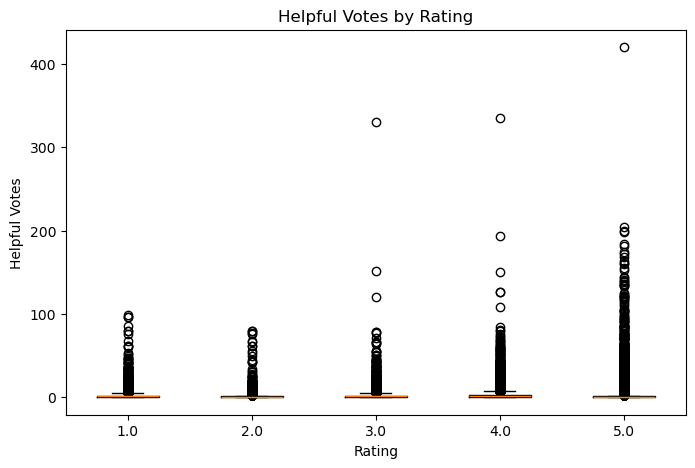

In [73]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [df_final[df_final["rating"] == r]["helpful_vote"] for r in sorted(df_final["rating"].unique())],
    tick_labels=sorted(df_final["rating"].unique())
)

plt.title("Helpful Votes by Rating")
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")

plt.show()

In [ ]:
## How likely is a review to become helpful?

In [74]:
helpful_rate = (
    df_final
    .groupby("rating")["is_helpful"]
    .mean()
    * 100
)

print(helpful_rate)

rating
1.0    60.706002
2.0    46.685627
3.0    51.052717
4.0    60.135241
5.0    45.291427
Name: is_helpful, dtype: float64


In [ ]:
## H2. Review Length ⭐

## Business Question

## Does review length affect perceived usefulness?

## Hypothesis

## Longer reviews are more likely to receive helpful votes because they provide more detailed information.

In [ ]:
## H3. Title Length

## Business Question

## Does a descriptive title improve review visibility?

## Hypothesis

## Reviews with longer, more descriptive titles are more likely to receive helpful votes.

In [ ]:
## H4. Images

## Business Question

## Do visual reviews provide more value?

## Hypothesis

## Reviews containing images are more likely to receive helpful votes.

In [ ]:
## H5. Brand

## Business Question

## Do some brands consistently receive more helpful reviews?

## Hypothesis

## Established brands receive more helpful reviews because their products attract more customer engagement.

In [ ]:
## H6. Category

## Business Question

## Are some product categories associated with more helpful reviews?

## Hypothesis

## Technical or high-involvement product categories generate more helpful reviews than simple consumer products.

In [76]:
print(f"Total reviews: {len(df_final):,}")
print(f"Unique products: {df_final['parent_asin'].nunique():,}")
print(f"Unique brands: {df_final['store'].nunique():,}")
print(f"Average rating: {df_final['rating'].mean():.2f}")
print(f"Average price: ${df_final['price'].mean():.2f}")

Total reviews: 163,165
Unique products: 3,819
Unique brands: 2,631
Average rating: 4.04
Average price: $103.85


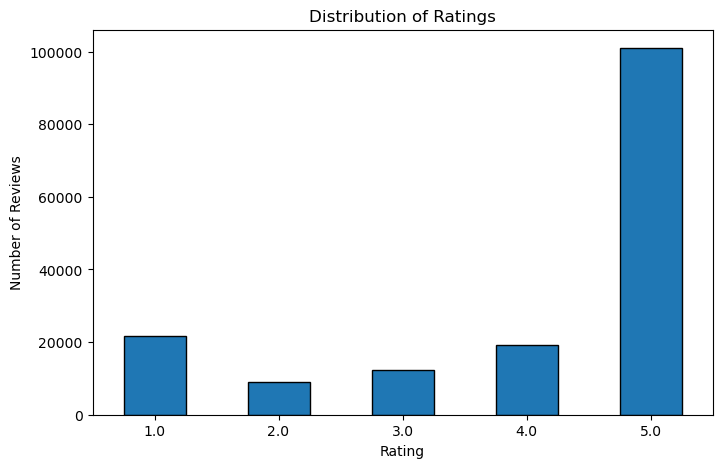

In [77]:
df_final["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

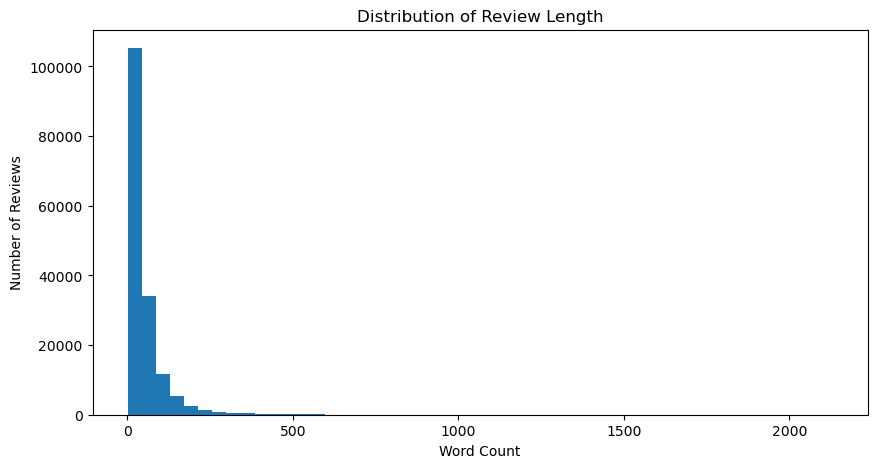

In [79]:
plt.figure(figsize=(10,5))

plt.hist(df_final["word_count"], bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")

plt.show()

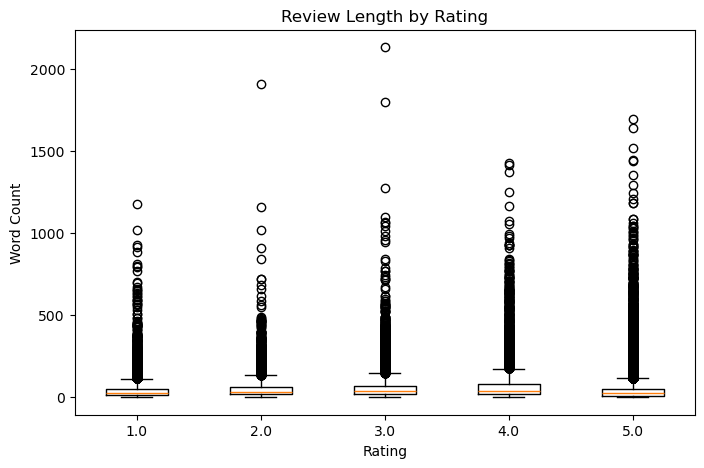

In [80]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [df_final[df_final["rating"] == r]["word_count"]
     for r in sorted(df_final["rating"].unique())],
    tick_labels=sorted(df_final["rating"].unique())
)

plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Word Count")

plt.show()

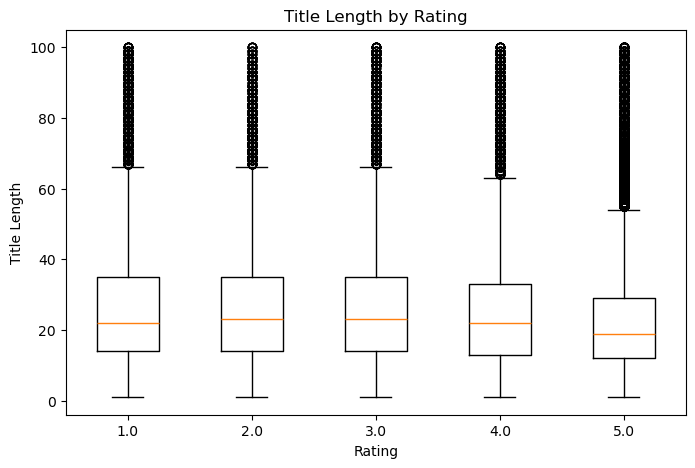

In [81]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [df_final[df_final["rating"] == r]["title_length"]
     for r in sorted(df_final["rating"].unique())],
    tick_labels=sorted(df_final["rating"].unique())
)

plt.title("Title Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Title Length")

plt.show()

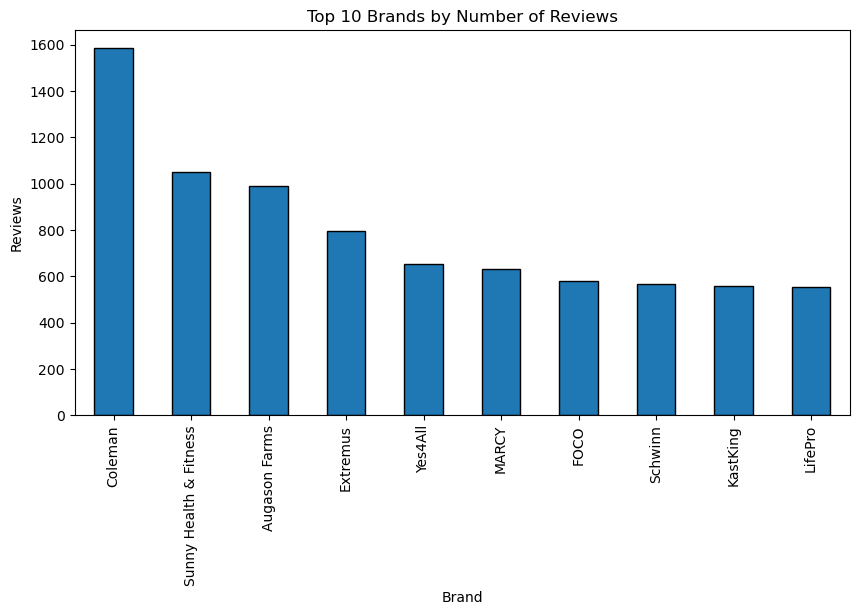

In [82]:
top_brands = df_final["store"].value_counts().head(10)

top_brands.plot(
    kind="bar",
    figsize=(10,5),
    edgecolor="black"
)

plt.title("Top 10 Brands by Number of Reviews")
plt.xlabel("Brand")
plt.ylabel("Reviews")

plt.show()

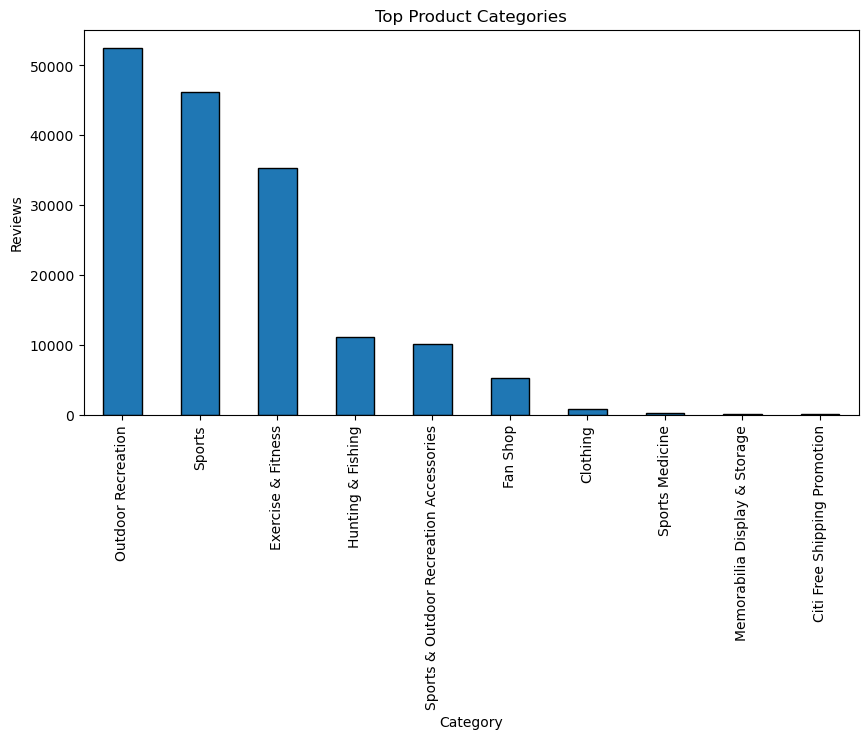

In [83]:
top_categories = df_final["category"].value_counts().head(10)

top_categories.plot(
    kind="bar",
    figsize=(10,5),
    edgecolor="black"
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Reviews")

plt.show()

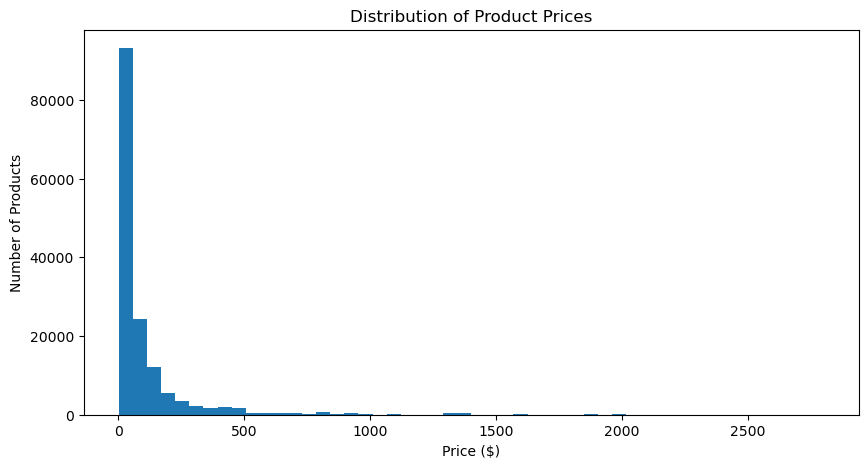

In [84]:
plt.figure(figsize=(10,5))

plt.hist(df_final["price"].dropna(), bins=50)

plt.title("Distribution of Product Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.show()

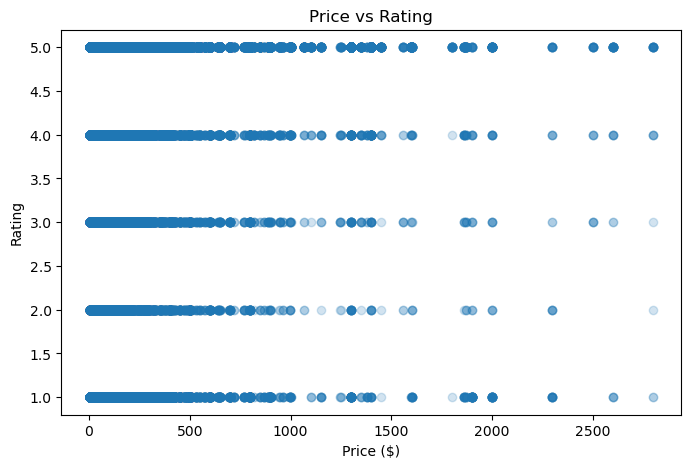

In [85]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_final["price"],
    df_final["rating"],
    alpha=0.2
)

plt.title("Price vs Rating")
plt.xlabel("Price ($)")
plt.ylabel("Rating")

plt.show()

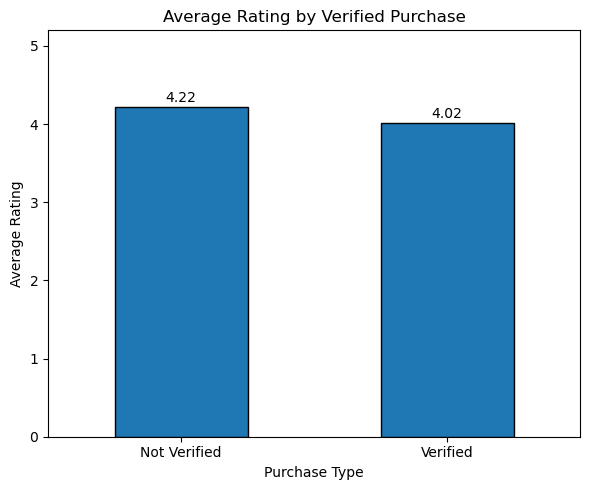

In [106]:
verified = (
    df_final
    .groupby("verified_purchase")["rating"]
    .mean()
)

plt.figure(figsize=(6, 5))

ax = verified.plot(
    kind="bar",
    edgecolor="black"
)

# Rename x-axis labels
ax.set_xticklabels(["Not Verified", "Verified"], rotation=0)

# Add value labels
for i, value in enumerate(verified):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Rating by Verified Purchase")
plt.xlabel("Purchase Type")
plt.ylabel("Average Rating")
plt.ylim(0, 5.2)

plt.tight_layout()
plt.show()

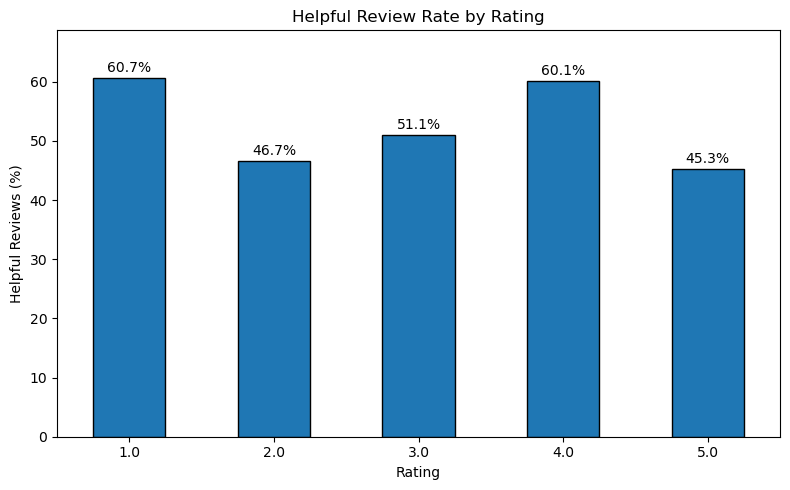

In [105]:
helpful_rate = (
    df_final
    .groupby("rating")["is_helpful"]
    .mean()
    * 100
)

plt.figure(figsize=(8, 5))

ax = helpful_rate.plot(
    kind="bar",
    edgecolor="black"
)

# Add percentage labels
for i, value in enumerate(helpful_rate):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Helpful Review Rate by Rating")
plt.xlabel("Rating")
plt.ylabel("Helpful Reviews (%)")
plt.xticks(rotation=0)
plt.ylim(0, helpful_rate.max() + 8)

plt.tight_layout()
plt.show()

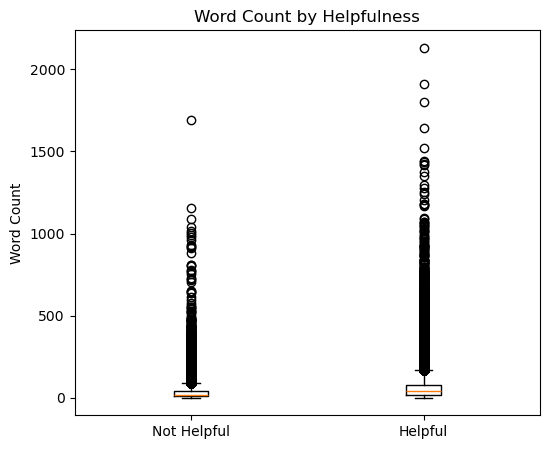

In [88]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        df_final[df_final["is_helpful"] == 0]["word_count"],
        df_final[df_final["is_helpful"] == 1]["word_count"]
    ],
    tick_labels=["Not Helpful", "Helpful"]
)

plt.title("Word Count by Helpfulness")
plt.ylabel("Word Count")

plt.show()

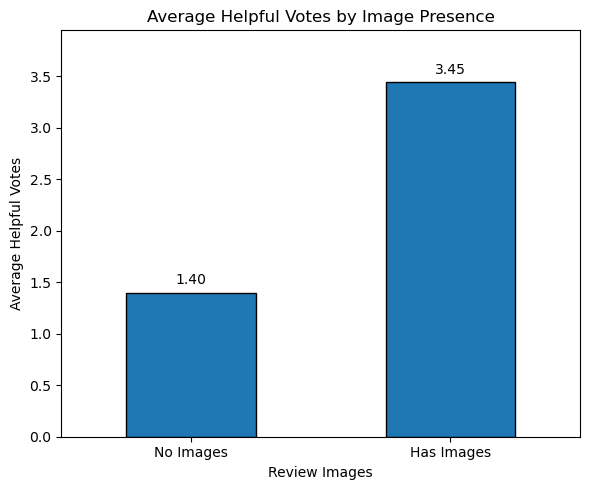

In [104]:
image_helpfulness = (
    df_final
    .groupby("has_images")["helpful_vote"]
    .mean()
)

plt.figure(figsize=(6, 5))

ax = image_helpfulness.plot(
    kind="bar",
    edgecolor="black"
)

# Rename x-axis labels
ax.set_xticklabels(["No Images", "Has Images"], rotation=0)

# Add value labels
for i, value in enumerate(image_helpfulness):
    ax.text(
        i,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Helpful Votes by Image Presence")
plt.xlabel("Review Images")
plt.ylabel("Average Helpful Votes")
plt.ylim(0, image_helpfulness.max() + 0.5)

plt.tight_layout()
plt.show()

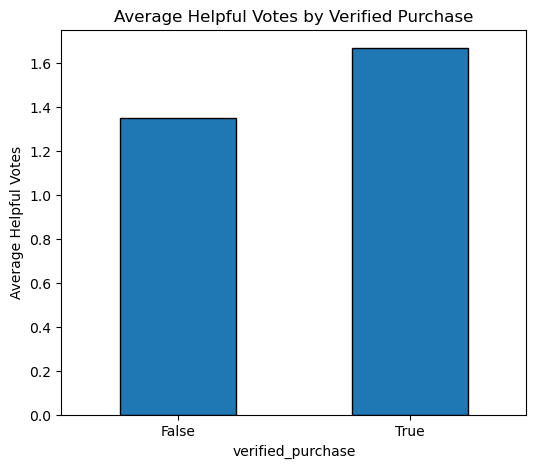

In [90]:
verified_helpfulness = (
    df_final
    .groupby("verified_purchase")["helpful_vote"]
    .mean()
)

verified_helpfulness.plot(
    kind="bar",
    figsize=(6,5),
    edgecolor="black"
)

plt.title("Average Helpful Votes by Verified Purchase")
plt.ylabel("Average Helpful Votes")
plt.xticks(rotation=0)

plt.show()

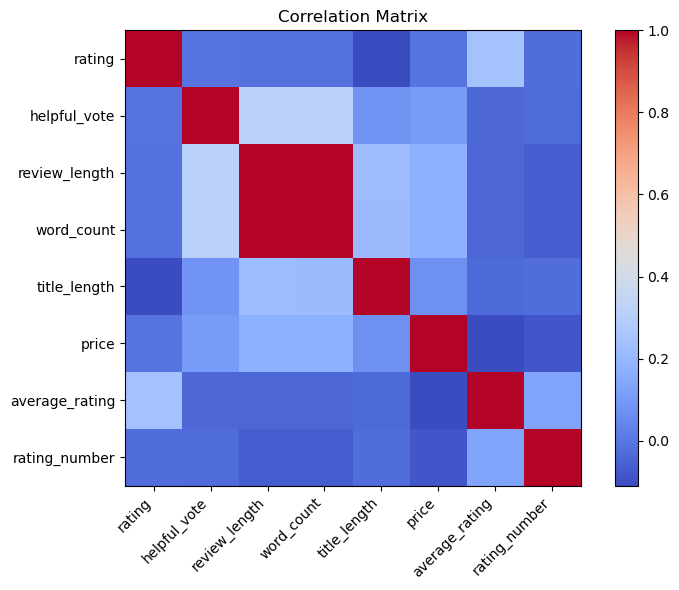

In [91]:
corr_cols = [
    "rating",
    "helpful_vote",
    "review_length",
    "word_count",
    "title_length",
    "price",
    "average_rating",
    "rating_number"
]

corr = df_final[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

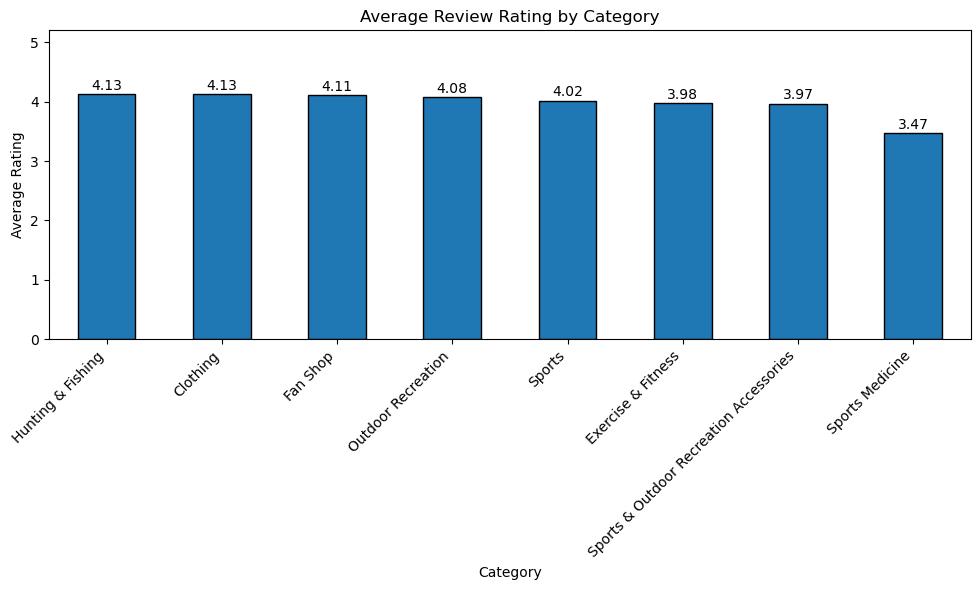

In [103]:
category_rating = (
    df_final
    .groupby("category")
    .agg(
        average_rating=("rating", "mean"),
        reviews=("rating", "count")
    )
)

category_rating = category_rating[
    category_rating["reviews"] >= 100
]

category_rating = category_rating.sort_values(
    "average_rating",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = category_rating["average_rating"].plot(
    kind="bar",
    edgecolor="black"
)

# Add value labels
for i, value in enumerate(category_rating["average_rating"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Review Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 5.2)

plt.tight_layout()
plt.show()

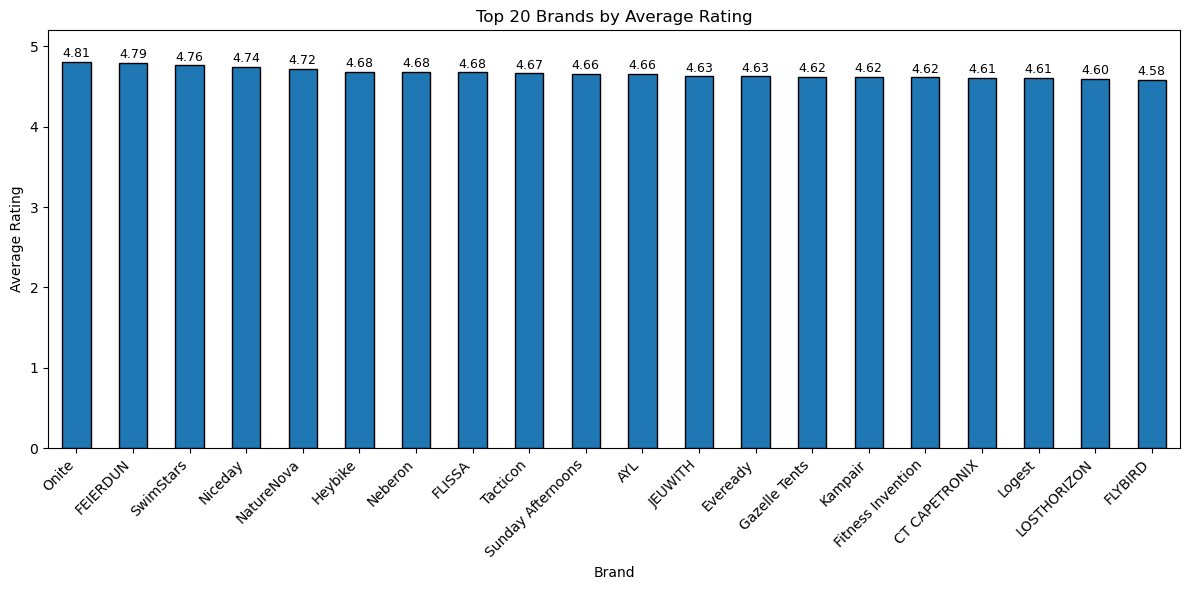

In [102]:
brand_rating = (
    df_final
    .groupby("store")
    .agg(
        average_rating=("rating", "mean"),
        reviews=("rating", "count")
    )
)

brand_rating = brand_rating[
    brand_rating["reviews"] >= 100
]

brand_rating = brand_rating.sort_values(
    "average_rating",
    ascending=False
).head(20)

plt.figure(figsize=(12, 6))

ax = brand_rating["average_rating"].plot(
    kind="bar",
    edgecolor="black"
)

# Add value labels
for i, value in enumerate(brand_rating["average_rating"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Top 20 Brands by Average Rating")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 5.2)

plt.tight_layout()
plt.show()

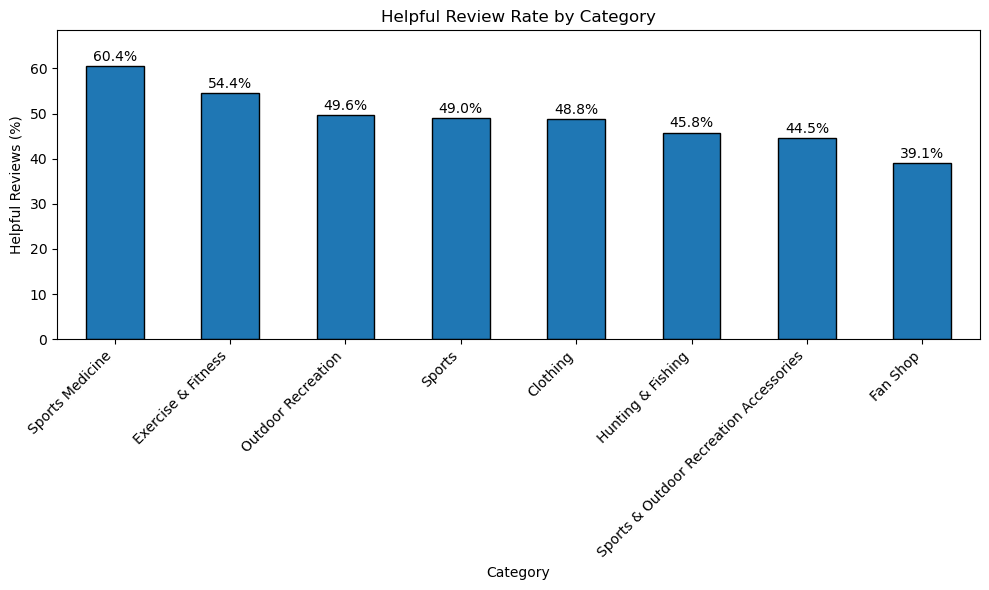

In [101]:
category_helpful = (
    df_final
    .groupby("category")
    .agg(
        helpful_rate=("is_helpful", "mean"),
        reviews=("rating", "count")
    )
)

category_helpful = category_helpful[
    category_helpful["reviews"] >= 100
]

category_helpful["helpful_rate"] *= 100

category_helpful = category_helpful.sort_values(
    "helpful_rate",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = category_helpful["helpful_rate"].plot(
    kind="bar",
    edgecolor="black"
)

# Add percentage labels
for i, value in enumerate(category_helpful["helpful_rate"]):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Helpful Review Rate by Category")
plt.ylabel("Helpful Reviews (%)")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, category_helpful["helpful_rate"].max() + 8)

plt.tight_layout()
plt.show()

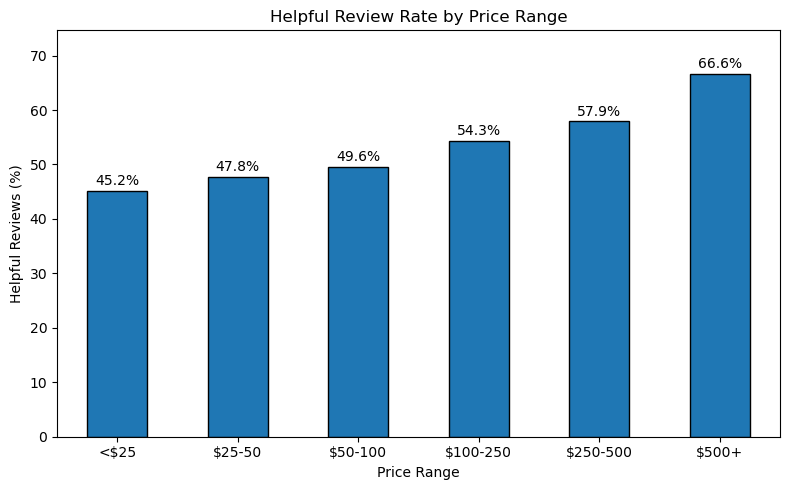

In [100]:
bins = [0, 25, 50, 100, 250, 500, 3000]
labels = [
    "<$25",
    "$25-50",
    "$50-100",
    "$100-250",
    "$250-500",
    "$500+"
]

df_final["price_group"] = pd.cut(
    df_final["price"],
    bins=bins,
    labels=labels
)

price_helpful = (
    df_final
    .groupby("price_group", observed=True)["is_helpful"]
    .mean()
    * 100
)

plt.figure(figsize=(8, 5))

ax = price_helpful.plot(
    kind="bar",
    edgecolor="black"
)

# Add percentage labels
for i, value in enumerate(price_helpful):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Helpful Review Rate by Price Range")
plt.ylabel("Helpful Reviews (%)")
plt.xlabel("Price Range")
plt.xticks(rotation=0)
plt.ylim(0, price_helpful.max() + 8)

plt.tight_layout()
plt.show()

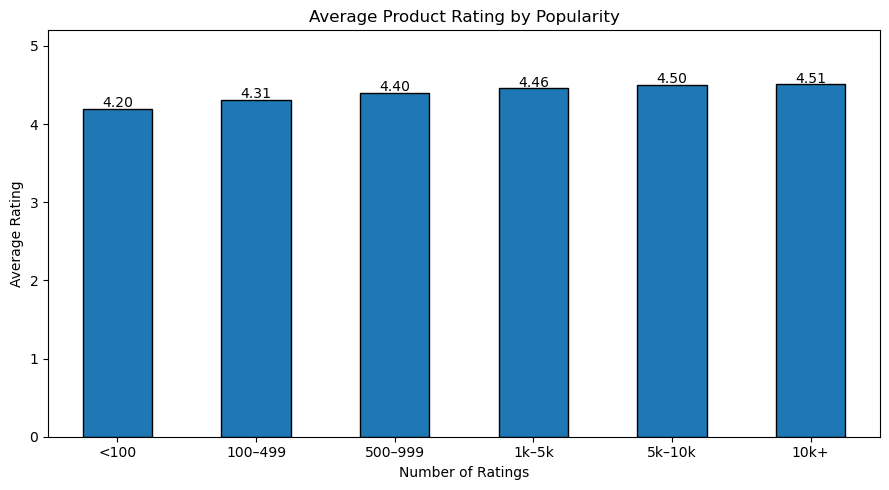

In [99]:
bins = [0, 100, 500, 1000, 5000, 10000, 100000]
labels = [
    "<100",
    "100–499",
    "500–999",
    "1k–5k",
    "5k–10k",
    "10k+"
]

product_summary = (
    df_final[
        ["parent_asin", "average_rating", "rating_number"]
    ]
    .drop_duplicates()
)

product_summary["popularity_group"] = pd.cut(
    product_summary["rating_number"],
    bins=bins,
    labels=labels
)

popularity = (
    product_summary
    .groupby("popularity_group", observed=True)["average_rating"]
    .mean()
)

plt.figure(figsize=(9,5))

ax = popularity.plot(
    kind="bar",
    edgecolor="black"
)

# Add value labels
for i, value in enumerate(popularity):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Average Product Rating by Popularity")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(0, 5.2)

plt.tight_layout()
plt.show()

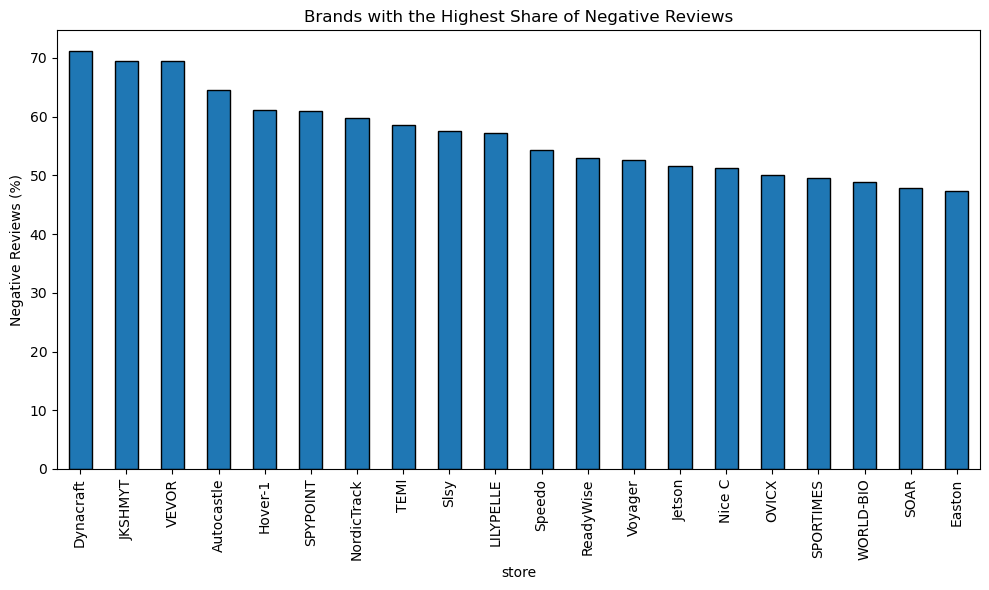

In [97]:
negative_rate = (
    df_final
    .assign(negative=df_final["rating"]<=3)
    .groupby("store")
    .agg(
        negative_rate=("negative","mean"),
        reviews=("rating","count")
    )
)

negative_rate = negative_rate[
    negative_rate["reviews"] >= 100
]

negative_rate["negative_rate"] *= 100

negative_rate = negative_rate.sort_values(
    "negative_rate",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

negative_rate["negative_rate"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Brands with the Highest Share of Negative Reviews")
plt.ylabel("Negative Reviews (%)")

plt.tight_layout()
plt.show()

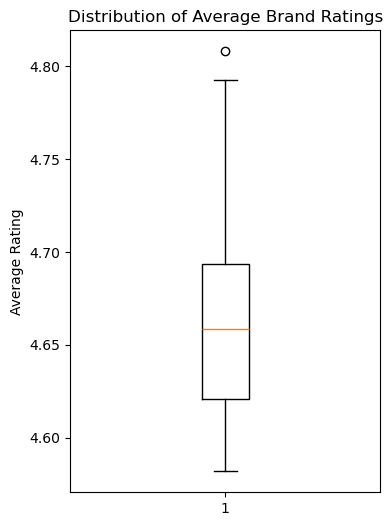

In [110]:
plt.figure(figsize=(4,6))

plt.boxplot(brand_rating["average_rating"])

plt.title("Distribution of Average Brand Ratings")
plt.ylabel("Average Rating")

plt.show()

In [127]:
df_final.head()

,rating,title,text,asin,parent_asin,user_id,helpful_vote,verified_purchase,review_date,has_images,...,average_rating,rating_number,features,category,subcategory,product_group,helpful_group,is_highly_helpful,price_group,review
0,5.0,Works as advertised,One of the beams arrived bent. I emailed the ...,B08LBQHRRT,B0BV5YVW94,AHE3DATFMO3Z3ETDV7AVGVVP4V2A,3,True,2022-12-16 04:23:51.415,False,...,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages,2–5,0,$250-500,Works as advertised One of the beams arrived b...
1,4.0,Great value weight/fitness rack,"Set up was not bad, even for one person. Stur...",B08LBQHRRT,B0BV5YVW94,AEMEXZV5C3IFY5JXZHCMRJ2OR6UA,1,True,2022-12-22 19:25:43.487,False,...,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages,1,0,$250-500,Great value weight/fitness rack Set up was not...
2,1.0,"The quality is just ""wow."" And in such a horri...",It looks and feels like a kids Tonka Toy. The ...,B094NFVJCW,B0BV5YVW94,AGNFWBS6EQHRSWTGMM564XFDH66A,0,True,2022-04-05 14:34:28.194,False,...,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages,0,0,$250-500,"The quality is just ""wow."" And in such a horri..."
3,3.0,Manufacturing defect.,One side has holes drilled but the opposite do...,B08LBQHRRT,B0BV5YVW94,AGERO4RR7NJCVIAGISRM4PXAYMQA,0,True,2022-10-25 00:11:22.075,True,...,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages,0,0,$250-500,Manufacturing defect. One side has holes drill...
4,5.0,Great budget at home rack,A little wobbly when you re-rack a heavy squat...,B08LBQHRRT,B0BV5YVW94,AG6YH5TTF2VKPW2CAO2L5OQZ536A,3,True,2022-12-10 19:25:54.614,False,...,4.5,198,[【Versatile】ZENOVA multifunctional squat rack ...,Exercise & Fitness,Strength Training Equipment,Racks & Cages,2–5,0,$250-500,Great budget at home rack A little wobbly when...


## NLP

In [112]:
df_final["review"] = (
    df_final["title"].fillna("") + " " +
    df_final["text"].fillna("")
)

In [113]:
df_final["review"].head()

0    Works as advertised One of the beams arrived b...
1    Great value weight/fitness rack Set up was not...
2    The quality is just "wow." And in such a horri...
3    Manufacturing defect. One side has holes drill...
4    Great budget at home rack A little wobbly when...
Name: review, dtype: object

In [114]:
print(df_final["review"].iloc[0])

Works as advertised One of the beams arrived bent.  I emailed the company and they immediately replaced the broken part.  Excellent customer service.  The structure is sturdy and worth the investment.


In [115]:
!pip install spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 35.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 19.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.1/788.1 kB 25.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.6 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [spacy]m14/15 [spacy]


In [116]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.5 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [119]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
## CLEANING

In [125]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^\w\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text


def preprocess_text(text):

    text = clean_text(text)

    doc = nlp(text)

    clean_tokens = []

    for token in doc:

        if (
            not token.is_stop
            and not token.is_punct
        ):

            clean_tokens.append(token.lemma_)

    return " ".join(clean_tokens)

In [126]:
sample = df_final["review"].sample(5, random_state=42)

for review in sample:

    print("="*100)
    print("ORIGINAL\n")
    print(review)

    print("\nPROCESSED\n")
    print(preprocess_text(review))

ORIGINAL

Misleading Not what is pictured

PROCESSED

mislead picture
ORIGINAL

Best camping purchase EVER!!!! I got this to use on a fly-in fishing trip w my husband. The cabin we were staying in had a bathroom w shower and sink, the only potty was an outhouse 30 yards away.  Besides my husband there were 4 other men (who could just pee off the deck), I was the only female.  I am 60 years old so usually have to pee about 3am every night.  This thing was literally a life-saver because there were 2 bears at our camp off and on the last 3 days, one even on our deck one night!  I never had a problem using this urinal and think it would work great for a wide range of sizes of women.  It worked so much easier than I ever imagined!  Sure it would be nice if it was bigger, but then it wouldn’t fit as well between my legs and this size never overflowed FOR ME (I did test it for a few nights before our trip to make sure.).  I don’t think I’d ever use it without toilet paper even though it’s adv

In [133]:
# Number of exclamation marks
df_final["exclamation_count"] = df_final["review"].str.count("!")

# Number of question marks
df_final["question_count"] = df_final["review"].str.count(r"\?")

# Number of ALL CAPS words (2 or more uppercase letters)
df_final["all_caps_words"] = (
    df_final["review"]
    .str.findall(r"\b[A-Z]{2,}\b")
    .str.len()
)

# Number of sentences
df_final["sentence_count"] = (
    df_final["review"]
    .str.count(r"[.!?]") + 1
)

# Average words per sentence
df_final["avg_words_per_sentence"] = (
    df_final["word_count"] /
    df_final["sentence_count"]
)

# Number of uppercase letters
uppercase_letters = df_final["review"].str.count(r"[A-Z]")

# Number of alphabetic characters
letters = df_final["review"].str.count(r"[A-Za-z]")

# Ratio of uppercase letters
df_final["uppercase_ratio"] = (
    uppercase_letters / letters
).fillna(0)

# Number of title words
df_final["title_word_count"] = (
    df_final["title"]
    .str.split()
    .str.len()
)

## Average word length

df_final["avg_word_length"] = (
    df_final["review_length"] /
    df_final["word_count"]
).fillna(0)

## Unique words

df_final["unique_word_count"] = (
    df_final["review"]
    .str.lower()
    .str.findall(r"\b\w+\b")
    .apply(lambda words: len(set(words)))
)

## Vocabulary richness

df_final["lexical_diversity"] = (
    df_final["unique_word_count"] /
    df_final["word_count"]
).fillna(0)

## Contains a URL?

df_final["contains_url"] = (
    df_final["review"]
    .str.contains(r"http|www", case=False)
    .astype(int)
)

## Contains a number?

df_final["contains_number"] = (
    df_final["review"]
    .str.contains(r"\d")
    .astype(int)
)

## Is review negative?

df_final["negative_review"] = (
    df_final["rating"] <= 3
).astype(int)

## DICTIONARY FOR CATEGORIZATION:

In [505]:
# ==========================================
# Aspect keyword dictionaries
# ==========================================

aspect_dictionary = {}

# ==========================================
# Phrase dictionaries
# ==========================================

phrase_dictionary = {}

## durability

In [506]:
aspect_dictionary["Durability"]= {

    # ==========================
    # General Failure
    # ==========================

    "break": 4,
    "broke": 4,
    "broken": 4,
    "breaking": 4,

    "fail": 4,
    "failed": 4,
    "failure": 4,

    "damage": 3,
    "damaged": 3,

    "destroy": 4,
    "destroyed": 4,

    "defect": 3,
    "defective": 4,

    "weak": 2,
    "fragile": 3,
    "brittle": 3,

    # ==========================
    # Cracks / Splits
    # ==========================

    "crack": 4,
    "cracked": 4,

    "split": 4,
    "splitting": 4,

    "fracture": 4,
    "fractured": 4,

    "shatter": 4,
    "shattered": 4,

    "chip": 3,
    "chipped": 3,

    # ==========================
    # Fabric
    # ==========================

    "tear": 4,
    "torn": 4,

    "rip": 4,
    "ripped": 4,

    "fray": 3,
    "frayed": 3,

    "unravel": 4,
    "unraveled": 4,

    "stitch": 3,
    "stitched": 3,
    "stitching": 3,

    "seam": 3,
    "seams": 3,

    "thread": 2,
    "threads": 2,

    # ==========================
    # Shape / Structure
    # ==========================

    "bend": 3,
    "bent": 3,

    "warp": 3,
    "warped": 3,

    "twist": 2,
    "twisted": 2,

    "collapse": 4,
    "collapsed": 4,

    "dent": 2,
    "dented": 2,

    # ==========================
    # Wear
    # ==========================

    "wear": 3,
    "worn": 3,

    "lasting": 2,
    "lasted": 2,

    "durable": 4,
    "sturdy": 3,

    # ==========================
    # Corrosion
    # ==========================

    "rust": 3,
    "rusted": 3,

    "corrosion": 3,

    # ==========================
    # Moving Parts
    # ==========================

    "loosen": 3,
    "loose": 2,

    "wobble": 3,
    "wobbly": 3,

    "jam": 3,
    "jammed": 3,

    "stuck": 3,

    "snap": 4,
    "snapped": 4,

    # ==========================
    # Product Components
    # ==========================

    "zipper": 2,
    "zip": 2,

    "buckle": 2,

    "strap": 2,

    "clip": 2,

    "clasp": 2,

    "hinge": 2,

    "handle": 2,

    "pole": 2,

    "frame": 2,

    "valve": 2,

    "lid": 2
}

phrase_dictionary["Durability"] = {

    "fell apart": 6,
    "falling apart": 6,

    "came apart": 6,
    "coming apart": 6,

    "broke after": 6,
    "broke within": 6,

    "stopped working": 6,
    "quit working": 6,

    "wear and tear": 5,

    "poor quality": 5,

    "wouldn't last": 6,
    "didn't last": 6,

    "lasted one day": 6,
    "lasted one week": 6,
    "lasted one month": 6,

    "zipper broke": 6,
    "strap broke": 6,
    "strap snapped": 6,

    "started leaking": 6,

    "lost pressure": 5,

    "came loose": 5,

    "started tearing": 6,

    "ripped apart": 6,

    "tore apart": 6,

    "fell off": 5
}

## performance

In [507]:
aspect_dictionary["Performance"]= {

    # ==========================
    # General Performance
    # ==========================

    "work": 3,
    "works": 3,
    "working": 3,
    "performed": 3,
    "perform": 3,
    "performance": 3,

    "function": 3,
    "functional": 3,

    "operate": 3,
    "operates": 3,
    "operation": 3,

    "effective": 3,
    "efficient": 3,
    "reliable": 2,

    # ==========================
    # Power / Battery
    # ==========================

    "battery": 4,
    "charge": 4,
    "charging": 4,
    "charger": 3,

    "power": 3,
    "powered": 3,

    "voltage": 2,

    "runtime": 3,

    # ==========================
    # Speed
    # ==========================

    "speed": 3,
    "fast": 2,
    "slow": 2,

    "responsive": 3,

    # ==========================
    # Accuracy
    # ==========================

    "accurate": 3,
    "accuracy": 3,
    "precise": 3,
    "precision": 3,
    "misleading": 3,

    # ==========================
    # Pressure / Air
    # ==========================

    "pressure": 3,

    "inflate": 3,
    "inflates": 3,
    "inflation": 3,

    "deflate": 3,

    "airflow": 2,
    "flow": 3,

    # ==========================
    # Water
    # ==========================

    "waterproof": 3,
    "waterproofing": 3,

    "leak": 3,
    "leaks": 3,
    "leaking": 3,

    # ==========================
    # Electronics
    # ==========================

    "sensor": 3,
    "signal": 3,
    "gps": 3,
    "bluetooth": 3,
    "connection": 3,
    "connect": 3,
    "sync": 3,

    # ==========================
    # Filtration / Flow
    # ==========================

    "filter": 3,

    "pump": 3,

    "flowrate": 2,

    # ==========================
    # Temperature
    # ==========================

    "temperature": 2,

    "cool": 2,
    "warm": 2,

    "insulation": 3
}

phrase_dictionary["Performance"] = {

    # General
    "works great": 6,
    "works perfectly": 6,
    "works well": 5,
    "works fine": 5,

    "doesn't work": 6,
    "didn't work": 6,
    "never worked": 6,

    "stopped working": 6,
    "does not spin": 5,

    # Battery
    "battery life": 6,
    "holds charge": 6,
    "lost charge": 6,
    "won't charge": 6,
    "stopped charging": 6,

    # Air / Pressure
    "holds air": 6,
    "loses air": 6,
    "lost pressure": 6,
    "wouldn't inflate": 6,
    "easy to inflate": 5,

    # Waterproof
    "water proof": 5,
    "keeps water out": 5,

    # Accuracy
    "very accurate": 5,
    "highly accurate": 5,

    # Speed
    "fast response": 5,
    "quick response": 5,

    # Performance
    "performed well": 5,
    "does not perform well": 5,
    "performs well": 5
}

## materials and build quality

In [508]:
aspect_dictionary["Materials & Build Quality"]= {

    # ==========================
    # Materials
    # ==========================

    "material": 3,
    "materials": 3,

    "plastic": 3,
    "metal": 3,
    "steel": 3,
    "aluminum": 3,
    "rubber": 3,
    "foam": 2,
    "fabric": 3,
    "mesh": 2,
    "canvas": 3,
    "nylon": 3,
    "polyester": 2,
    "vinyl": 2,
    "silicone": 2,
    "wood": 2,
    "leather": 3,
    "carbon": 3,
    "carbon fiber": 4,

    # ==========================
    # Construction
    # ==========================

    "build": 3,
    "built": 3,
    "construction": 3,
    "craftsmanship": 4,
    "manufacture": 2,
    "manufactured": 2,

    "quality": 3,

    "finish": 3,
    "coating": 3,
    "paint": 2,

    # ==========================
    # Positive Build
    # ==========================

    "premium": 4,
    "solid": 3,
    "robust": 3,
    "well-made": 4,
    "heavy-duty": 4,
    "thick": 2,

    # ==========================
    # Negative Build
    # ==========================

    "cheap": 4,
    "flimsy": 4,
    "thin": 3,
    "rough": 2,

    "unfinished": 3,
    "poorly": 3,

    # ==========================
    # Sewing / Assembly Quality
    # ==========================

    "stitch": 3,
    "stitches": 3,
    "stitching": 4,

    "seam": 3,
    "seams": 3,

    "thread": 2,
    "threads": 2,

    "glue": 2,
    "glued": 2,

    "weld": 3,
    "welded": 3,

    # ==========================
    # Surface / Appearance
    # ==========================

    "texture": 2,
    "smooth": 2,
    "matte": 2,
    "glossy": 2
}

phrase_dictionary["Materials & Build Quality"] = {

    # Positive
    "good quality": 6,
    "very good quality": 7,
    "high quality": 7,
    "great quality": 7,
    "excellent quality": 8,
    "premium quality": 8,

    "well made": 6,
    "very well made": 6,

    "solid construction": 6,
    "solid build": 6,

    "premium quality": 6,

    "heavy duty": 5,

    "high quality materials": 6,

    "feels solid": 5,

    "built to last": 6,

    # Negative
    "poor quality": 7,

    "poorly made": 6,

    "cheap plastic": 6,

    "feels cheap": 6,

    "very flimsy": 6,

    "thin material": 5,

    "low quality": 6,

    "bad quality": 6,

    "cheaply made": 6,

    "poor craftsmanship": 6,

    "rough finish": 5,

    "paint peeling": 6,

    "started peeling": 6
}

## size and fit

In [509]:
aspect_dictionary["Size & Fit"]= {

    # ==========================
    # General Fit
    # ==========================

    "fit": 4,
    "fits": 4,
    "fitting": 4,

    "size": 4,
    "sized": 3,

    "measure": 2,
    "measurement": 2,

    # ==========================
    # Too Small / Too Large
    # ==========================

    "small": 4,
    "large": 4,
    "big": 4,

    "tiny": 3,
    "huge": 3,

    "oversized": 3,
    "undersized": 3,

    # ==========================
    # Tight / Loose
    # ==========================

    "tight": 4,
    "loose": 4,

    "snug": 3,

    # ==========================
    # Dimensions
    # ==========================

    "short": 3,
    "long": 3,

    "wide": 3,
    "narrow": 3,

    "length": 2,
    "height": 2,
    "width": 2,

    # ==========================
    # Capacity
    # ==========================

    "capacity": 3,

    "roomy": 3,
    "spacious": 3,

    # ==========================
    # Adjustment
    # ==========================

    "adjust": 3,
    "adjustable": 3,

    "resize": 3,

    "expand": 2,
    "expandable": 2,

    "compress": 2
}

phrase_dictionary["Size & Fit"] = {

    # Too small
    "too small": 6,
    "runs small": 6,
    "way too small": 6,

    # Too large
    "too big": 6,
    "runs large": 6,
    "way too big": 6,

    # Fit
    "fits perfectly": 6,
    "perfect fit": 6,
    "fits well": 5,

    "doesn't fit": 6,
    "didn't fit": 6,

    # Tight / Loose
    "too tight": 6,
    "too loose": 6,

    "fits true to size": 6,
    "true to size": 6,

    "size up": 5,
    "size down": 5,

    # Capacity
    "plenty of room": 5,
    "enough room": 5,
    "not enough room": 6,

    # Adjustment
    "easy to adjust": 5,
    "fully adjustable": 5
}

## comfort

In [510]:
aspect_dictionary["Comfort"]= {

    # ==========================
    # General Comfort
    # ==========================

    "comfort": 4,
    "comfortable": 4,
    "comfortably": 4,

    "uncomfortable": 4,
    "discomfort": 4,

    # ==========================
    # Cushioning / Support
    # ==========================

    "cushion": 3,
    "cushioning": 3,

    "padding": 3,
    "padded": 3,

    "support": 3,
    "supportive": 3,

    "ergonomic": 4,

    # ==========================
    # Feel
    # ==========================

    "soft": 2,
    "firm": 2,

    "stiff": 3,
    "flexible": 2,

    "smooth": 2,

    # ==========================
    # Fatigue
    # ==========================

    "fatigue": 3,

    "pressure": 2,

    "ache": 3,
    "aches": 3,

    "pain": 4,

    "sore": 3,

    # ==========================
    # Weight
    # ==========================

    "lightweight": 2,

    "heavy": 2,

    # ==========================
    # Wearability
    # ==========================

    "wear": 2,
    "wearing": 2
}

phrase_dictionary["Comfort"] = {

    # Positive
    "very comfortable": 6,
    "super comfortable": 6,

    "extremely comfortable": 6,

    "comfortable enough": 5,

    "comfortable to wear": 6,

    "easy to wear": 5,

    "feels comfortable": 5,

    "great support": 5,

    "excellent support": 6,

    "well padded": 5,

    # Negative
    "not comfortable": 6,

    "very uncomfortable": 6,

    "too hard": 5,

    "too soft": 5,

    "hurts my": 6,

    "causes pain": 6,

    "back pain": 6,

    "neck pain": 6,

    "shoulder pain": 6,

    "pressure points": 5
}

## ease of use

In [511]:
aspect_dictionary["Ease of Use"]= {

    # ==========================
    # Easy
    # ==========================

    "easy": 4,
    "easier": 3,

    "simple": 4,
    "simplely": 2,

    "intuitive": 4,
    "straightforward": 4,

    "convenient": 3,
    "convenience": 3,

    "user-friendly": 4,

    # ==========================
    # Difficult
    # ==========================

    "hard": 4,
    "difficult": 4,

    "complicated": 4,
    "confusing": 4,

    "frustrating": 3,

    "awkward": 3,

    # ==========================
    # Learning
    # ==========================

    "learn": 3,
    "learning": 3,

    "understand": 3,

    "instruction": 2,
    "instructions": 2,

    "manual": 2,

    "guide": 2,

    # ==========================
    # Operation
    # ==========================

    "operate": 3,
    "operation": 3,

    "use": 3,
    "usable": 3,

    "handle": 2,

    "adjust": 2,
    "adjustment": 2,

    "control": 2,

    # ==========================
    # Installation
    # ==========================

    "install": 2,
    "installation": 2,

    "setup": 3,
    "configure": 3,

    # ==========================
    # Maintenance
    # ==========================

    "clean": 2,
    "cleaning": 2,

    "maintain": 2,
    "maintenance": 2
}

phrase_dictionary["Ease of Use"] = {

    # Positive
    "easy to use": 6,
    "very easy to use": 6,

    "easy to operate": 6,

    "easy to adjust": 5,

    "easy to clean": 5,

    "easy setup": 5,

    "simple to use": 6,

    "simple to operate": 5,

    "ready to use": 5,

    "plug and play": 6,

    "works out of the box": 6,

    "clear instructions": 5,

    "easy to follow": 5,

    # Negative
    "hard to use": 6,

    "difficult to use": 6,

    "hard to operate": 6,

    "difficult to understand": 6,

    "confusing instructions": 6,

    "poor instructions": 6,

    "instructions unclear": 6,

    "hard to adjust": 5,

    "hard to clean": 5,

    "not user friendly": 6,

    "steep learning curve": 6
}

## setup and installation

In [512]:
aspect_dictionary["Setup & Installation"]= {

    # General Setup
    "setup": 4,
    "set": 2,
    "configure": 3,
    "configuration": 3,
    "calibrate": 3,
    "calibration": 3,

    # Assembly
    "assemble": 4,
    "assembled": 4,
    "assembly": 4,

    # Installation
    "install": 4,
    "installed": 4,
    "installation": 4,

    "mount": 3,
    "mounted": 3,

    "attach": 3,
    "attached": 3,

    "connect": 3,
    "connected": 3,

    # Hardware
    "bolt": 3,
    "bolts": 3,
    "screw": 3,
    "screws": 3,
    "nut": 2,
    "washer": 2,
    "hardware": 3,
    "bracket": 2,
    "tool": 2,
    "wrench": 2,
    "allen": 2,
    "hex": 2,

    # Alignment
    "align": 2,
    "alignment": 2
}

phrase_dictionary["Setup & Installation"] = {

    # Positive

    "easy to assemble": 6,

    "easy assembly": 6,

    "easy installation": 6,

    "easy to install": 6,

    "assembled in minutes": 6,

    "took minutes": 5,

    "clear instructions": 5,

    "everything included": 5,

    "all parts included": 6,

    "ready in minutes": 5,

    # Negative

    "hard to assemble": 6,

    "difficult to assemble": 6,

    "difficult to install": 6,

    "missing hardware": 6,

    "missing screws": 6,

    "missing bolts": 6,

    "missing parts": 6,

    "parts missing": 6,

    "instructions unclear": 6,

    "poor instructions": 6,

    "assembly required": 4,

    "took forever": 5,

    "very difficult to assemble": 6
}

## delivery and packaging

In [513]:
aspect_dictionary["Delivery & Packaging"]= {

    # ==========================
    # Delivery
    # ==========================

    "delivery": 4,
    "deliver": 4,
    "delivered": 4,

    "shipping": 4,
    "ship": 4,
    "shipped": 4,

    "arrive": 4,
    "arrived": 4,
    "arrival": 3,

    "carrier": 2,
    "courier": 2,
    "mail": 2,
    "postal": 2,

    # ==========================
    # Delivery Speed
    # ==========================

    "late": 4,
    "delay": 4,
    "delayed": 4,

    "early": 2,
    "fast": 2,
    "quick": 2,
    "overnight": 2,

    # ==========================
    # Packaging
    # ==========================

    "package": 3,
    "packaged": 3,
    "packaging": 4,

    "box": 3,
    "sealed": 2,

    "wrap": 2,
    "wrapped": 2,

    "protective": 2,

    # ==========================
    # Arrival Condition
    # ==========================

    "damaged": 3,
    "opened": 2,
    "crushed": 3,
    "dented": 3,
    "broken": 2,

    # ==========================
    # Missing Items
    # ==========================

    "missing": 3,
    "incomplete": 4,

    "include": 2,
    "included": 2,

    "part": 2,
    "parts": 2,

    "piece": 2,
    "pieces": 2,

    "hardware": 2,

    "accessory": 2,
    "component": 2
}

phrase_dictionary["Delivery & Packaging"]: {

    # ==========================
    # Delivery
    # ==========================

    "arrived on time": 6,
    "arrived early": 5,
    "arrived late": 6,

    "delivered on time": 6,

    "fast shipping": 6,
    "quick shipping": 6,
    "shipping was fast": 6,

    "shipping delay": 6,
    "delayed shipping": 6,

    "took too long": 6,

    # ==========================
    # Packaging
    # ==========================

    "well packaged": 6,
    "poorly packaged": 6,
    "nicely packaged": 5,
    "securely packaged": 5,

    "damaged packaging": 6,
    "damaged box": 6,
    "box was damaged": 6,

    "package arrived damaged": 6,
    "arrived damaged": 6,
    "arrived broken": 6,
    "arrived opened": 6,

    "package was opened": 6,

    # ==========================
    # Missing Items
    # ==========================

    "missing parts": 6,
    "missing piece": 6,
    "missing pieces": 6,

    "missing hardware": 6,
    "missing screw": 6,
    "missing screws": 6,

    "missing bolt": 6,
    "missing bolts": 6,

    "missing from package": 6,

    "not included": 6,
    "wasn't included": 6,
    "didn't include": 6,

    "incomplete package": 6,
    "arrived incomplete": 6
}

## customer service

In [514]:
aspect_dictionary["Customer Service"]= {

    # ==========================
    # General Service
    # ==========================

    "service": 4,
    "support": 4,
    "customer": 2,
    "seller": 3,
    "vendor": 3,
    "manufacturer": 3,
    "company": 2,

    # ==========================
    # Refunds & Returns
    # ==========================

    "refund": 4,
    "refunded": 4,
    "return": 4,
    "returned": 4,
    "exchange": 3,
    "exchanged": 3,

    # ==========================
    # Replacement
    # ==========================

    "replace": 4,
    "replaced": 4,
    "replacement": 4,

    # ==========================
    # Warranty
    # ==========================

    "warranty": 4,
    "guarantee": 3,
    "covered": 2,

    # ==========================
    # Communication
    # ==========================

    "response": 3,
    "respond": 3,
    "responsive": 3,
    "contact": 3,
    "email": 2,
    "phone": 2,

    # ==========================
    # Resolution
    # ==========================

    "resolve": 4,
    "resolved": 4,
    "resolution": 4,

    "help": 3,
    "helpful": 3,

    "assist": 3,
    "assistance": 3,

    # ==========================
    # Satisfaction
    # ==========================

    "professional": 3,
    "courteous": 3,
    "friendly": 3
}

phrase_dictionary["Customer Service"] = {

    # Positive
    "excellent customer service": 6,
    "great customer service": 6,
    "amazing customer service": 6,

    "customer support": 6,

    "very responsive": 5,
    "quick response": 5,

    "seller responded": 5,
    "company responded": 5,

    "problem resolved": 6,
    "issue resolved": 6,

    "sent replacement": 6,
    "replacement sent": 6,

    "received refund": 6,
    "full refund": 6,

    "easy return": 5,

    "highly recommend seller": 5,

    # Negative
    "poor customer service": 6,
    "terrible customer service": 6,

    "never responded": 6,
    "no response": 6,

    "would not refund": 6,
    "refused refund": 6,

    "refused replacement": 6,

    "customer service ignored": 6,

    "difficult to contact": 6,

    "warranty denied": 6,

    "still waiting": 5,

    "not helpful": 5
}

## value for money

In [515]:
aspect_dictionary["Value for Money"]= {

    # ==========================
    # Price
    # ==========================

    "price": 4,
    "priced": 3,
    "cost": 3,
    "costly": 3,

    "expensive": 4,
    "overpriced": 4,
    "pricey": 4,

    "cheap": 3,
    "inexpensive": 3,
    "affordable": 3,
    "budget": 3,

    # ==========================
    # Value
    # ==========================

    "value": 4,
    "worth": 4,
    "worthy": 3,

    "money": 2,

    "deal": 3,
    "bargain": 4,

    "investment": 2,

    # ==========================
    # Savings
    # ==========================

    "save": 2,
    "saving": 2,

    "discount": 2,

    "sale": 2
}

phrase_dictionary["Value for Money"] = {

    # Positive
    "worth the money": 6,
    "worth every penny": 6,

    "good value": 6,
    "great value": 7,
    "excellent value": 6,

    "good for the price": 6,
    "great for the price": 6,

    "good price": 4,
    "great price": 5,

    "excellent price": 7,

    "money well spent": 6,

    "best value": 7,

    "can't beat the price": 7,

    "good deal": 5,

    # Negative
    "waste of money": 6,

    "not worth it": 6,

    "not worth the price": 6,

    "too expensive": 6,

    "way too expensive": 6,

    "overpriced": 6,

    "poor value": 6,

    "bad value": 6,

    "not worth the money": 6,

    "would not buy again": 5,

    "buyer beware": 6
}

## design and appearance

In [516]:
aspect_dictionary["Design & Appearance"]= {

    # ==========================
    # General Design
    # ==========================

    "design": 4,
    "appearance": 4,
    "style": 4,
    "stylish": 4,

    "look": 4,
    "looks": 4,
    "looking": 3,

    "aesthetic": 4,
    "aesthetics": 4,

    # ==========================
    # Visual Quality
    # ==========================

    "beautiful": 4,
    "attractive": 4,
    "nice": 3,
    "elegant": 4,
    "sleek": 4,
    "modern": 3,
    "classic": 3,

    "ugly": 4,

    # ==========================
    # Color
    # ==========================

    "color": 3,
    "colour": 3,

    "bright": 2,
    "dark": 2,
    "vibrant": 3,
    "faded": 3,

    # ==========================
    # Finish
    # ==========================

    "finish": 3,

    "matte": 2,
    "glossy": 2,

    "polished": 3,

    "scratch": 2,
    "scratches": 2,

    # ==========================
    # Shape
    # ==========================

    "shape": 2,

    "profile": 2,

    "compact": 2,

    "bulky": 3
}

phrase_dictionary["Design & Appearance"] = {

    # Positive

    "looks great": 6,

    "looks amazing": 6,

    "looks awesome": 6,

    "looks fantastic": 6,

    "beautiful design": 6,

    "great design": 6,

    "nice design": 5,

    "well designed": 6,

    "love the design": 6,

    "love the color": 6,

    "nice color": 5,

    "looks premium": 6,

    "modern design": 5,

    "sleek design": 6,

    # Negative

    "looks cheap": 6,

    "poor design": 6,

    "bad design": 6,

    "cheap looking": 6,

    "not very sturdy": 6,

    "looks ugly": 6,

    "wrong color": 6,

    "different color": 5,

    "color faded": 6,

    "scratches easily": 6,

    "poor finish": 6
}

## taste & flavor

In [517]:
aspect_dictionary["Taste & Flavor"] = {

    "taste": 4,
    "flavor": 4,
    "flavour": 4,

    "tasty": 3,
    "delicious": 3,

    "sweet": 2,
    "bitter": 2,
    "bland": 2,
    "aftertaste": 2
}

phrase_dictionary["Taste & Flavor"] = {

    "great taste": 7,
    "good taste": 6,
    "bad taste": 7,

    "tastes great": 7,
    "tastes good": 6,
    "tastes bad": 7,

    "love the taste": 8,

    "too sweet": 6,
    "too bitter": 6
}

## DICTIONARY KEYS TEST

In [518]:
print(aspect_dictionary.keys())

dict_keys(['Durability', 'Performance', 'Materials & Build Quality', 'Size & Fit', 'Comfort', 'Ease of Use', 'Setup & Installation', 'Delivery & Packaging', 'Customer Service', 'Value for Money', 'Design & Appearance', 'Taste & Flavor'])


## APPLY ASPECT DETECTION

In [519]:
# ============================================================
# Detect Aspects
# ============================================================

def detect_aspects(text):

    text_lower = text.lower()

    doc = nlp(text_lower)

    lemmas = {
        token.lemma_.lower()
        for token in doc
        if (
            token.is_alpha
            and not token.is_stop
            and not token.is_punct
        )
    }

    aspect_scores = {}

    aspect_matches = {}

    # ========================================================
    # Phrase matching (highest priority)
    # ========================================================

    for aspect, phrases in phrase_dictionary.items():

        for phrase, weight in phrases.items():

            if re.search(
                rf"\b{re.escape(phrase)}\b",
                text_lower
            ):

                aspect_scores[aspect] = (
                    aspect_scores.get(aspect, 0)
                    + weight
                )

                aspect_matches.setdefault(
                    aspect,
                    []
                ).append(phrase)

    # ========================================================
    # Keyword matching
    # ========================================================

    for aspect, keywords in aspect_dictionary.items():

        matched_words = lemmas & keywords.keys()

        if matched_words:

            score = sum(
                keywords[word]
                for word in matched_words
            )

            aspect_scores[aspect] = (
                aspect_scores.get(aspect, 0)
                + score
            )

            aspect_matches.setdefault(
                aspect,
                []
            ).extend(
                sorted(matched_words)
            )

    # ========================================================
    # Build detected aspects
    # ========================================================

    detected = []

    for aspect in aspect_scores:

        detected.append({

            "aspect": aspect,

            "keywords": sorted(
                set(
                    aspect_matches[aspect]
                )
            ),

            "score": aspect_scores[aspect]

        })

    return detected


# ============================================================
# Summarize Aspects
# ============================================================

def summarize_aspects(aspect_list):

    if not aspect_list:

        return pd.Series([
            "Other",
            None,
            None,
            "Low"
        ])

    aspect_list = sorted(
        aspect_list,
        key=lambda x: x["score"],
        reverse=True
    )

    primary_aspect = aspect_list[0]["aspect"]

    secondary_aspect = (
        aspect_list[1]["aspect"]
        if len(aspect_list) > 1
        else None
    )

    aspect_keywords = ", ".join(
        aspect_list[0]["keywords"]
    )

    score = aspect_list[0]["score"]

    if score >= 9:

        confidence = "High"

    elif score >= 4:

        confidence = "Medium"

    else:

        confidence = "Low"

    return pd.Series([
        primary_aspect,
        secondary_aspect,
        aspect_keywords,
        confidence
    ])


# ============================================================
# Apply
# ============================================================

df_final["detected_aspects"] = (
    df_final["review"]
    .apply(detect_aspects)
)

df_final["aspect_count"] = (
    df_final["detected_aspects"]
    .apply(len)
)

df_final[
    [
        "primary_aspect",
        "secondary_aspect",
        "aspect_keywords",
        "aspect_confidence"
    ]
] = (
    df_final["detected_aspects"]
    .apply(summarize_aspects)
)


# ============================================================
# Validation
# ============================================================

# Aspect distribution
print(df_final["primary_aspect"].value_counts())

# Percentage distribution
print(
    (
        df_final["primary_aspect"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    )
)

# Confidence distribution
print(df_final["aspect_confidence"].value_counts())

# Number of detected aspects
print(
    df_final["aspect_count"]
    .value_counts()
    .sort_index()
)

# Random sample
display(
    df_final[
        [
            "rating",
            "review",
            "primary_aspect",
            "secondary_aspect",
            "aspect_keywords",
            "aspect_confidence",
            "aspect_count"
        ]
    ].sample(30, random_state=42)
)

primary_aspect
Size & Fit                   24036
Performance                  24013
Ease of Use                  19873
Materials & Build Quality    15309
Durability                   13854
Value for Money              13228
Other                        12502
Comfort                       8770
Design & Appearance           8756
Customer Service              7652
Setup & Installation          5916
Delivery & Packaging          3592
Taste & Flavor                 748
Name: count, dtype: int64
primary_aspect
Size & Fit                   15.2
Performance                  15.2
Ease of Use                  12.6
Materials & Build Quality     9.7
Durability                    8.8
Value for Money               8.4
Other                         7.9
Comfort                       5.5
Design & Appearance           5.5
Customer Service              4.8
Setup & Installation          3.7
Delivery & Packaging          2.3
Taste & Flavor                0.5
Name: proportion, dtype: float64
aspect_confide

,rating,review,primary_aspect,secondary_aspect,aspect_keywords,aspect_confidence,aspect_count
65151,5.0,Super comfort I use to skating and it is so helpful!,Comfort,Ease of Use,comfort,Medium,3
7367,5.0,"English & Espanol review- Everything you need to go fishing, minus the fishing rod and floats :) [[VIDEOID:8db383e404cdb7734cff735aaa6d3db4]] Everything you need to go fishing! This kit is super complete, it brings has many different, for both fresh and saltwater fishing. All seem of very good material and a good amount of supplies, different sizes, and colors.<br /><br />A great option, I recommend it 100%.<br /><br />Todo lo necesario para ir a pescar!!!<br />ESte kit es super completo trae muchos distintos elementos para pescar en agua fresca y salada todo muy buen material y buena cantidad distintos tamanos y colores.<br />Excelente opcion lo recomienod 100x 100.",Size & Fit,Materials & Build Quality,size,Medium,2
26406,5.0,Great Fitness Tracker for the Price! I've had several more expensive trackers over the years and they always break down within a short time. So I decided to try a less expensive one this time. Does the same things as the expensive trackers for a fraction of the price. Needs to be charged about once a week and is convenient as you just plug the tracker right into a USB port. Everything seems accurate so far. App is user friendly too. Very happy with this purchase.,Value for Money,Performance,"expensive, price",Medium,6
86583,5.0,"SUPER DEAL FOR ELECTRIC WHEELS! Can't say enough about the quality of these bikes, and for AVANTREK's customer service! Excellent on both counts!",Customer Service,Materials & Build Quality,"customer, service",Medium,3
78785,2.0,"Zipper broke. Buy a better suit First use at the beach, zipper broke. Major L",Durability,Ease of Use,"break, zipper, zipper broke",High,2
120027,4.0,Great Helps cushion a hard seat,Ease of Use,Comfort,hard,Medium,3
97209,1.0,"I left these behind in my hotel room and bought new ones. I thought these were more light weight than they turned out to be. They were thick, heavy plastic that were awkward to use in a backpack when traveling. After a week of fussing with them, my adult granddaughter and I went to an outdoor store on our trip to England and bought new travel bottles. We left these behind in our hotel room as not worth keeping.",Ease of Use,Materials & Build Quality,"awkward, use",Medium,4
134452,1.0,Poorly made The ALPHA CAMP camping chair ripped the first time it was used. Combined wait of the two people sitting on chair was well below the 450 pound limit. Even more disappointing is the fact that a return option is not offered for this product. Don’t buy this chair!!,Materials & Build Quality,Durability,"poorly, poorly made",High,3
80418,1.0,rust. installed on my brand new car. and had two days of rain and then we had sun. come to find out the bars were rusting and dripping on my car. sometimes buying cheaper doesnt always work. would not recommend.<br /><br />But they did take back the bars and refund me my money. so thank you,Value for Money,Materials & Build Quality,"cheap, money",Medium,5
61147,5.0,Great for futons! This thing is amazing! I used it on my futon bc I was basically sleeping on a metal bar and it saved my back! I didn’t leave it open for 1-2 day period it said to and I still slept great! Definitely worth the money and you can take it wherever you need to! Awesome sauce :D,Value for Money,Materials & Build Quality,"money, save, worth, worth the money",High,2


In [520]:
df_final["review_type"].value_counts()

review_type
Strength     118050
Complaint     40199
Name: count, dtype: int64

In [521]:
df_final["review"].str.contains(
    "taste|flavor|flavour",
    case=False,
    na=False
).sum()

np.int64(1435)

In [522]:
pd.crosstab(
    df_final["rating"],
    df_final["review_type"],
    normalize="index"
).round(2)

review_type,Complaint,Strength
rating,,
1.0,0.95,0.05
2.0,0.88,0.12
3.0,0.80,0.20
4.0,0.07,0.93
5.0,0.02,0.98


In [523]:
df_final["review_reason"].value_counts()

review_reason
Rating                         150884
Positive sentiment override      4551
Negative sentiment override      2814
Name: count, dtype: int64

## FINDINGS DICTIONARY

In [598]:
# ============================================================
# Finding Mapping
# ============================================================

finding_mapping = {

    # ========================================================
    # Durability
    # ========================================================

    "Durability": {

        "Broken": [
            "break",
            "snap",
            "collapse",
            "fell off",
            "bent"
        ],

        "Cracked": [
            "crack"
        ],

        "Ripped": [
            "rip",
            "tear"
        ],

        "Rusted": [
            "rust",
            "corrosion"
        ],

        "Worn Out": [
            "wear",
            "wear out"
        ]

    },

    # ========================================================
    # Performance
    # ========================================================

    "Performance": {

        "Doesn't Work": [
            "doesn't work",
            "does not work",
            "dead",
            "defective",
            "faulty",
            "malfunction",
            "useless"
        ],

        "Stopped Working": [
            "stopped working",
            "quit working",
            "stop working"
        ],

        "Slow Performance": [
            "too slow",
            "runs slow",
            "runs slowly",
            "works slowly",
            "slow performance",
            "slow to respond"
        ],

        "Weak Performance": [
            "weak power",
            "low power",
            "underpowered"
        ],

        "Inaccurate": [
            "inaccurate",
            "incorrect"
        ],

        "Poor Battery Life": [
            "poor battery life",
            "short battery life",
            "battery doesn't last",
            "battery does not last",
            "battery dies quickly",
            "battery drains quickly",
            "battery drains fast",
            "doesn't hold a charge",
            "does not hold a charge"
        ],

        "Charging Problem": [
            "won't charge",
            "won't recharge",
            "doesn't charge",
            "does not charge",
            "stopped charging",
            "not charging",
            "charging stopped"
        ],

        "Connectivity Problem": [
            "connection problem",
            "connection issue",
            "won't connect",
            "doesn't connect",
            "does not connect",
            "keeps disconnecting",
            "loses connection",
            "connection keeps dropping"
        ],

        "Works Well": [
            "works well",
            "works great",
            "works perfectly",
            "works as expected",
            "does what it states",
            "does what it's supposed to",
            "gets the job done",
            "does the job"
        ]

    },

    # ========================================================
    # Materials & Build Quality
    # ========================================================

    "Materials & Build Quality": {

        "Cheap Material": [
            "cheaply made",
            "cheap material",
            "cheaply constructed"
        ],

        "Flimsy": [
            "flimsy",
            "fragile"
        ],

        "Lightweight": [
            "lightweight",
            "very light",
            "extremely light",
            "light to carry",
            "light to hold"
        ],
        
        "Heavy": [
            "heavy",
            "too heavy",
            "heavier than expected",
            "heavy to carry",
            "heavy to hold"
        ],

        "Manufacturing Defect": [
            "manufacturing defect",
            "manufacturing flaw",
            "manufacturing issue",
            "defective from the factory",
            "factory defect",
            "factory flaw"
        ],

        "Well Made": [
            "well made",
            "well-built"
        ],

        "Solid Construction": [
            "solid construction",
            "solidly built",
            "sturdy",
            "robust"
        ],

        "Poor Finish": [
            "poor finish",
            "unfinished",
            "rough finish"
        ]

    },

    # ========================================================
    # Size & Fit
    # ========================================================

    "Size & Fit": {

        "Too Small": [
            "too small",
            "run small",
            "runs small",
            "runs a little small",
            "run short",
            "runs short"
        ],

        "Too Large": [
            "too big",
            "too large",
            "run big",
            "runs big",
            "runs a little big",
            "run large",
            "runs large"
            
        ],

        "Doesn't Fit": [
            "doesn't fit",
            "does not fit",
            "too wide",
            "too high",
            "too low"
        ],

        "Perfect Fit": [
            "perfect fit",
            "fits perfectly"
        ],

        "Loose Fit": [
            "too loose"
        ],

        "Tight Fit": [
            "too tight"
        ],

        "Incorrect Product Information": [
            "not as advertised",
            "not as described",
            "different from description",
            "description was incorrect",
            "description is incorrect",
            "incorrect product information",
            "misleading description",
            "misleading information",
            "advertised incorrectly"
        ]

    },

    # ========================================================
    # Comfort
    # ========================================================

    "Comfort": {

        "Comfortable": [
            "comfortable",
            "very comfortable"
        ],

        "Uncomfortable": [
            "uncomfortable",
            "not comfortable"
        ],

        "Too Hard": [
            "too hard"
        ],

        "Too Soft": [
            "too soft"
        ]

    },

    # ========================================================
    # Ease of Use
    # ========================================================

    "Ease of Use": {

        "Easy to Use": [
            "easy to use",
            "user friendly"
        ],

        "Difficult to Use": [
            "hard to use",
            "difficult to use",
            "not user friendly",
            "confusing"
        ],

        "Easy Inflation": [
            "easy to inflate",
            "easy to fill",
            "inflates easily"
        ],
        
        "Difficult Inflation": [
            "difficult to inflate",
            "hard to inflate",
            "difficult to fill",
            "hard to fill",
            "inflation was difficult"
        ]

    },

    # ========================================================
    # Setup & Installation
    # ========================================================

    "Setup & Installation": {

        "Easy Setup": [
            "easy to assemble",
            "easy setup",
            "fast setup"
        ],

        "Difficult Setup": [
            "hard to assemble",
            "difficult setup",
            "difficult to assemble"
        ],

        "Missing Instructions": [
            "missing instructions",
            "no instructions"
        ],

        "Installation Problems": [
            "installation problem",
            "installation issue",
            "difficult installation"
        ]

    },

    # ========================================================
    # Delivery & Packaging
    # ========================================================

    "Delivery & Packaging": {

        "Arrived Damaged": [
            "arrived damaged",
            "damaged on arrival",
            "package was opened"
        ],

        "Received Wrong Product": [
            "wrong product",
            "wrong item",
            "received the wrong product",
            "received the wrong item",
            "sent the wrong product",
            "sent the wrong item",
            "not what I ordered"
        ],

        "Received Wrong Size": [
            "wrong size",
            "received the wrong size",
            "sent the wrong size",
            "different size than ordered",
            "size was not what I ordered"
        ],

        "Received Wrong Color": [
            "wrong color",
            "received the wrong color",
            "sent the wrong color",
            "different color than ordered",
            "color was not what I ordered",
            "color is different from what I ordered"
        ],

        "Missing Parts": [
            "missing part",
            "missing parts",
            "missing piece",
            "missing pieces",
            "missing component",
            "missing components",
            "part was missing",
            "parts were missing"
        ],

        "Incomplete Order": [
            "incomplete order",
            "order was incomplete",
            "part of my order was missing",
            "item was missing from my order",
            "only received one",
            "only received part of my order"
        ],
        
        "Poor Packaging": [
            "poor packaging",
            "package damaged"
        ],

        "Late Delivery": [
            "late delivery",
            "delivery delay",
            "arrived late"
        ],

        "Fast Delivery": [
            "fast shipping",
            "arrived quickly",
            "quick delivery"
        ]

    },

    # ========================================================
    # Customer Service
    # ========================================================

    "Customer Service": {

        "Refund Issued": [
            "refund issued",
            "refund was issued",
            "refund has been issued",
            "refund was processed",
            "refund has been processed",
            "got refunded",
            "got the refund",
            "received my refund",
            "received a refund",
            "refund received"
        ],

        "Refund Requested": [
            "requested a refund",
            "requesting a refund",
            "want a refund",
            "need a refund",
            "asked for a refund",
            "asking for a refund",
            "get my money back",
            "would like a refund"
        ],
    
        "Poor Customer Service": [
            "poor customer service",
            "terrible customer service",
            "bad customer service",
            "awful customer service",
            "terrible support",
            "poor support",
            "no response",
            "never responded",
            "didn't respond",
            "did not respond",
            "did not fix the issue"
        ],
    
        "Helpful Customer Support": [
            "great customer service",
            "excellent customer service",
            "helpful support",
            "great support",
            "responsive support",
            "fixed the issue"
        ],

    
        "Replacement Sent": [
            "got the replacement",
            "received the replacement",
            "replacement sent",
            "replacement received",
            "replaced"
        ]
    

    },

    # ========================================================
    # Value for Money
    # ========================================================

    "Value for Money": {

        "Worth the Money": [
            "worth the money",
            "worth the price",
            "worth every penny",
            "worth the investment",
            "good value for money",
            "outstanding value"
        ],

        "Overpriced": [
            "overpriced",
            "too expensive",
            "not worth the price"
        ]

    },

    # ========================================================
    # Design & Appearance
    # ========================================================

    "Design & Appearance": {

        "Poor Design": [
            "poor design",
            "horrible design",
            "bad design",
            "design flaw"
        ],

         "Good Design": [
            "good design",
            "great design",
            "excellent design",
            "well designed",
            "beautifully designed"
            "love the design",
            "love the way it looks"
        ],

        "Wrong Color": [
            "wrong color",
            "different color"
        ]

    },

    # ========================================================
    # Taste & Flavor
    # ========================================================

    "Taste & Flavor": {

        "Great Taste": [
            "tastes great",
            "delicious"
        ],

        "Bad Taste": [
            "bad taste",
            "tasteless",
            "horrible taste"
        ],

        "Too Sweet": [
            "too sweet",
            "too much sugar"
        ],

        "Bland": [
            "bland"
        ]

    }

}

## APPLY FINDINGS DETECTION

In [599]:
# ============================================================
# Build PhraseMatcher
# ============================================================

phrase_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

phrase_to_finding = {}

for aspect, findings in finding_mapping.items():

    for finding, keywords in findings.items():

        for keyword in keywords:

            if " " in keyword:

                phrase = nlp.make_doc(keyword)

                pattern_name = f"{aspect}__{finding}__{keyword}"

                phrase_matcher.add(
                    pattern_name,
                    [phrase]
                )

                phrase_to_finding[pattern_name] = (
                    aspect,
                    finding,
                    keyword
                )

In [600]:
# ============================================================
# Negation Mapping
# ============================================================

NEGATION_MAP = {

    "Comfortable": "Uncomfortable",
    "Uncomfortable": "Comfortable",

    "Easy to Use": "Difficult to Use",
    "Difficult to Use": "Easy to Use",

    "Easy Setup": "Difficult Setup",
    "Difficult Setup": "Easy Setup",

    "Well Made": "Poor Finish",
    "Poor Finish": "Well Made",

    "Perfect Fit": "Doesn't Fit",
    "Doesn't Fit": "Perfect Fit",

    "Worth the Money": "Overpriced",
    "Overpriced": "Worth the Money",

    "Great Taste": "Bad Taste",
    "Bad Taste": "Great Taste"

}

# ============================================================
# Check if a token is negated
# ============================================================

def is_negated(token):

    NEGATION_WORDS = {
        "not",
        "n't",
        "never",
        "no",
        "hardly",
        "barely"
    }

    # Direct negation dependency
    if token.dep_ == "neg":
        return True

    if any(child.dep_ == "neg" for child in token.children):
        return True
    
    if token.head.dep_ == "neg":
        return True

    # Nearby negation words (window of 3 tokens)
    start = max(0, token.i - 3)
    
    for t in reversed(token.doc[start:token.i]):
    
        if t.is_punct:
            break
    
        if t.lower_ in NEGATION_WORDS:
            return True

    return False

# ============================================================
# Detect Findings
# ============================================================

def detect_finding(review, aspect):

    doc = nlp(review.lower())

    finding_scores = {}

    finding_matches = {}

    finding_aspects = {}

    matched_findings = set()

    # ========================================================
    # PhraseMatcher
    # ========================================================

    matches = phrase_matcher(doc)

    for match_id, start, end in matches:

        pattern_name = nlp.vocab.strings[match_id]

        matched_aspect, finding, keyword = (
            phrase_to_finding[pattern_name]
        )

        span = doc[start:end]

        final_finding = finding
        
        # Check whether the matched phrase itself
        # already contains an explicit negation
        phrase_contains_negation = any(
            token.lower_ in {
                "not",
                "n't",
                "never",
                "no"
            }
            for token in span
        )
        
        # Only reverse the finding when the negation
        # comes from outside the matched phrase
        if (
            not phrase_contains_negation
            and any(
                is_negated(token)
                for token in span
                if token.is_alpha
            )
        ):
        
            final_finding = NEGATION_MAP.get(
                finding,
                finding
            )

        finding_scores[final_finding] = (
            finding_scores.get(final_finding, 0) + 2
        )

        finding_matches.setdefault(
            final_finding,
            set()
        ).add(keyword)

        finding_aspects[final_finding] = matched_aspect

        matched_findings.add(final_finding)

    # ========================================================
    # Lemma matching
    # ========================================================

    for matched_aspect, aspect_findings in finding_mapping.items():

        for finding, keywords in aspect_findings.items():

            for keyword in keywords:

                if " " in keyword:
                    continue

                for token in doc:

                    if (
                        token.is_alpha
                        and token.lemma_.lower() == keyword
                    ):

                        final_finding = finding

                        if is_negated(token):

                            final_finding = NEGATION_MAP.get(
                                finding,
                                finding
                            )

                        # Skip if already detected by PhraseMatcher
                        if final_finding in matched_findings:
                            continue

                        finding_scores[final_finding] = (
                            finding_scores.get(
                                final_finding,
                                0
                            ) + 1
                        )

                        finding_matches.setdefault(
                            final_finding,
                            set()
                        ).add(keyword)

                        finding_aspects[
                            final_finding
                        ] = matched_aspect

    if not finding_scores:

        return []

    detected = []

    for finding, score in sorted(
        finding_scores.items(),
        key=lambda x: x[1],
        reverse=True
    ):

        detected.append({

            "finding": finding,

            "aspect": finding_aspects[finding],

            "keywords": sorted(
                finding_matches[finding]
            ),

            "score": score

        })

    return detected

In [601]:
# ============================================================
# Summarize Findings
# ============================================================

def summarize_findings(finding_list):

    if not finding_list:

        return pd.Series([
            "Other",
            None,
            None,
            None,
            "Low"
        ])

    finding_list = sorted(
        finding_list,
        key=lambda x: x["score"],
        reverse=True
    )

    primary_finding = finding_list[0]["finding"]

    finding_aspect = finding_list[0]["aspect"]

    secondary_finding = (
        finding_list[1]["finding"]
        if len(finding_list) > 1
        else None
    )

    finding_keywords = ", ".join(
        finding_list[0]["keywords"]
    )

    score = finding_list[0]["score"]

    if score >= 4:
        confidence = "High"

    elif score >= 2:
        confidence = "Medium"

    else:
        confidence = "Low"

    return pd.Series([
        primary_finding,
        finding_aspect,
        secondary_finding,
        finding_keywords,
        confidence
    ])

# ============================================================
# Apply Findings
# ============================================================

df_final["detected_findings"] = df_final.apply(
    lambda row: detect_finding(
        row["review"],
        row["primary_aspect"]
    ),
    axis=1
)

df_final["finding_count"] = (
    df_final["detected_findings"]
    .apply(len)
)

df_final[
    [
        "primary_finding",
        "secondary_finding",
        "finding_aspect",
        "finding_keywords",
        "finding_confidence"
    ]
] = (
    df_final["detected_findings"]
    .apply(summarize_findings)
)

## SENTIMENT DICTIONARY

In [562]:
# ============================================================
# Sentiment Dictionaries
# ============================================================

positive_words = {

    # ========================================================
    # Strong Positive
    # ========================================================

    "excellent": 3,
    "perfect": 3,
    "amazing": 3,
    "awesome": 3,
    "fantastic": 3,
    "brilliant": 3,
    "outstanding": 3,
    "flawless": 3,
    "exceptional": 3,
    "superb": 3,

    # ========================================================
    # Happiness
    # ========================================================

    "love": 2,
    "adore": 3,
    "enjoy": 2,
    "happy": 1,
    "delighted": 3,
    "thrilled": 3,
    "pleased": 2,
    "grateful": 2,

    # ========================================================
    # Satisfaction
    # ========================================================

    "satisfied": 1,
    "impressed": 2,
    "impressive": 2,
    "recommend": 2,
    "recommended": 2,
    "favorite": 1,

    # ========================================================
    # Appreciation
    # ========================================================

    "wonderful": 2,
    "nice": 1,
    "good": 1,
    "great": 2,
    "remarkable": 2,
    "valuable": 2,
    "pleased": 2,

    # ========================================================
    # Positive Surprise
    # ========================================================

    "surprised": 1,
    "unexpectedly": 1,
    "exceeded": 2,

    # ========================================================
    # Loyalty
    # ========================================================

    "repeat": 1,

    # ========================================================
    # Product Evaluation
    # ========================================================

    "durable": 2,
    "sturdy": 2,
    "reliable": 2,

    "comfortable": 2,

    "smooth": 1,

    "effective": 2,
    "efficient": 2,
    
    "well-made": 2,
    "solid": 1,
    "robust": 1,

    "accurate": 2,

    "convenient": 1,

    "useful": 2,

    "stable": 2,

    "secure": 2
}


negative_words = {

    # Strong negative
    "terrible": -3,
    "awful": -3,
    "horrible": -3,
    "dreadful": -3,
    "appalling": -3,
    "unacceptable": -3,
    "pathetic": -3,

    # Strong dissatisfaction
    "hate": -3,
    "worthless": -3,
    "useless": -3,
    "nightmare": -3,
    "regret": -3,
    "unhappy": -3,

    # Anger
    "frustrating": -3,
    "frustrated": -3,
    "furious": -3,
    "angry": -3,
    "annoying": -2,
    "annoyed": -2,
    "upset": -2,

    # Disappointment
    "disappointed": -3,
    "disappointing": -3,
    "underwhelmed": -2,

    # Negative opinion
    "bad": -1,
    "poor": -1,
    "mediocre": -2,

    # Strong criticism
    "junk": -3,
    "garbage": -3,
    "crap": -3,
    "rubbish": -3,
    "ridiculous": -3,
    "absurd": -3,
    "shocking": -2,

    # Buying regret
    "waste": -2,

    # Recommendation
    "avoid": -3,
    "warning": -2,

    # Negative Product Evaluation

    "broken": -3,
    "break": -3,
    "broke": -3,
    
    "defective": -3,
    "faulty": -3,
    
    "cracked": -3,
    "crack": -3,
    
    "damaged": -3,
    "damage": -2,
    
    "ripped": -3,
    "rip": -3,
    
    "torn": -3,
    "tear": -3,
    
    "leaking": -3,
    "leak": -3,
    
    "failed": -3,
    "fail": -3,
    
    "difficult": -2,
    
    "uncomfortable": -2,
    
    "unstable": -2,
    
    "unreliable": -3,
    
    "weak": -2,
    
    "flimsy": -3,
    "WTF": -3,
    
    "poorly": -2,
    "frustrating": -2,
    "annoying": -2, 
    
    "inaccurate": -2,
    
    "inconvenient": -2
    }

# ============================================================
# Sentiment Phrase Dictionaries
# ============================================================

positive_phrases = {

    "love it": 8,
    "loved it": 8,
    "loves it": 8,
    "absolutely love": 9,

    "highly recommend": 8,
    "definitely recommend": 8,

    "worth every penny": 8,
    "money well spent": 8,

    "exceeded expectations": 8,
    "better than expected": 7,

    "very satisfied": 7,
    "very nice": 6,
    "extremely satisfied": 8,
    "does the job": 6,

    "pleasantly surprised": 7,

    "couldn't be happier": 9,

    "best purchase": 8,
    "get this": 8,
    "best investment": 8,

    "would buy again": 8,
    "will buy again": 7,

    "five stars": 7,

    "very impressed": 8,
    "very pleased": 8,
    "beyond expectations": 8,

    "exactly what i wanted": 7,
    "everything I hoped for": 7,

    "works like a charm": 7,

    "thank you": 5,

    "works perfectly": 7,
    "works great": 7,
    "works flawlessly": 8,

    "very comfortable": 7,
    "super comfortable": 8,

    "excellent quality": 8,
    "very good quality": 7,
    "great quality": 7,

    "well made": 7,
    "well built": 7,

    "fits perfectly": 7,

    "easy to use": 6,

    "easy to assemble": 6,

    "very reliable": 7,

    "high quality": 8
}

negative_phrases = {

    "waste of money": -9,

    "piece of junk": -9,
    "piece of crap": -9,
    "no thank you": -6,
    "not very good quality": -7,
    "doesn't work perfectly": -7,
    "doesn't work great": -7,
    "not exactly what i wanted": -5,
    "not well made": -7,
    "not well built": -7,
    "not high quality": -8,
    "does not fit perfectly": -6,
    "doesn't fit perfectly": -6,
    "not impressed": -6,
    "not very impressed": -6,
    "throw away": -6,

    "very disappointed": -8,
    "extremely disappointed": -9,

    "do not recommend": -9,
    "would not recommend": -9,

    "not reliable": -7,
    "not the best purchase": -7,
    "not the best investment": -7,

    "worst purchase": -9,
    "biggest regret": -9,
    "not very reliable": -7,

    "regret buying": -8,

    "not worth it": -8,
    "not worth the money": -9,

    "never again": -8,

    "stay away": -9,
    "get my money back": -9,

    "avoid this": -9,

    "completely useless": -9,

    "total disappointment": -8,

    "wish i had returned": -8,

    "save your money": -9,

    "don't waste your money": -10,
    "won't waste my money": -10,

    "would never buy again": -9,

    "do not recommend": -8,
    "don't recommend": -8,

    "not recommend": -8,
    "wouldn't recommend": -8,
    "wouldn't buy again": -8,

    "never recommend": -8,

    "not buy again": -8,
    "wouldn't buy again": -8,
    "never buy again": -8,

    "do not waste your money": -9,
    "wasted my money": -9,

    "don't waste your time": -9,
    "do not waste your time": -9,
    "buy from somewhere else": -10,

    "not worth the money": -8,
    "not worth": -5,

    "save your money": -8,

    "doesn't work": -8,
    "didn't work": -8,
    "never worked": -8,

    "stopped working": -8,

    "poor quality": -7,

    "cheaply made": -7,

    "poorly made": -7,

    "arrived broken": -8,

    "arrived damaged": -8,

    "fell apart": -8,

    "came apart": -8,

    "broke after": -8,

    "stopped working after": -8,

    "very uncomfortable": -7,

    "hard to use": -6,

    "difficult to use": -6
}

    # Escalation Phrases

escalation_phrases = {

    # Legal
    "lawsuit": -10,
    "legal action": -10,
    "my lawyer": -10,
    "attorney": -10,
    "i will sue": -10,
    "sue you": -10,

    # Complaints
    "file a complaint": -8,
    "consumer protection": -9,
    "compensation": -9,
    "better business bureau": -9,
    "not responding": -8,

    # Amazon / Marketplace
    "report to amazon": -8,
    "report this to": -8,
    "reported this to": -8,
    "reported to amazon": -8,
    "report this seller": -8,
    "report this company": -8,

    # Payment disputes
    "chargeback": -9,
    "credit card dispute": -9,
    "paypal dispute": -9,
    "thiefs": -9,
    "stole my money": -9,
    "I want my money back": -10,

    # Reputation
    "buyer beware": -9,
    "customer beware": -9,
    "leave a bad review": -8,
    "negative review": -7,
    "post on social media": -7,
    "post on facebook": -8,
    "post on twitter": -8,
    "post on instagram": -8,
    "warn everyone": -8,

    # Customer loss
    "never buying again": -8,
    "never buy again": -8,
    "lost a customer": -8,
    "taking my business elsewhere": -8
}

intensifiers = {

    "very": 1,
    "really": 1,
    "so": 1,
    "super": 1,

    "extremely": 2,
    "absolutely": 2,
    "completely": 2,
    "totally": 2,
    "incredibly": 2,
    "exceptionally": 2
}




## APPLY SENTIMENT DETECTION

In [563]:
# ============================================================
# Sentiment Detection
# ============================================================

def detect_sentiment(text):

    # -------------------------------------------------------
    # Preserve original text
    # -------------------------------------------------------

    original_text = text
    text = text.lower()

    # -------------------------------------------------------
    # Handle common negations
    # -------------------------------------------------------

    text = text.replace("not bad", "good")
    text = text.replace("not great", "good")

    text = text.replace("isn't", "not")
    text = text.replace("wasn't", "not")
    text = text.replace("aren't", "not")
    text = text.replace("weren't", "not")
    text = text.replace("can't", "not")
    text = text.replace("couldn't", "not")
    text = text.replace("don't", "not")
    text = text.replace("didn't", "not")
    text = text.replace("doesn't", "not")

    # -------------------------------------------------------
    # Phrase scoring
    # -------------------------------------------------------

    positive_score = 0
    negative_score = 0
    escalation_score = 0

    matched_positive_phrases = []
    matched_negative_phrases = []
    matched_escalation_phrases = []

    for phrase, weight in positive_phrases.items():

        if re.search(rf"\b{re.escape(phrase)}\b", text):

            positive_score += weight
            matched_positive_phrases.append(phrase)

    for phrase, weight in negative_phrases.items():
    
        if re.search(rf"\b{re.escape(phrase)}\b", text):
    
            negative_score += weight
            matched_negative_phrases.append(phrase)
    
    
    # -------------------------------------------------------
    # Escalation phrase scoring
    # -------------------------------------------------------
    
    for phrase, weight in escalation_phrases.items():
    
        if re.search(rf"\b{re.escape(phrase)}\b", text):
    
            escalation_score += abs(weight)
    
            matched_escalation_phrases.append(
                phrase
            )
    # Prevent extremely large scores
    escalation_score = min(escalation_score, 20)  

    # -------------------------------------------------------
    # Prevent phrase double-counting
    # -------------------------------------------------------
    
    skip_positive = set()
    skip_negative = set()
    
    # -------------------------
    # Positive phrases
    # -------------------------
    
    if "love it" in matched_positive_phrases:
        skip_positive.add("love")
    
    if "works perfectly" in matched_positive_phrases:
        skip_positive.update({
            "work",
            "perfect"
        })
    
    if "works great" in matched_positive_phrases:
        skip_positive.update({
            "work",
            "great"
        })
    
    if "works flawlessly" in matched_positive_phrases:
        skip_positive.update({
            "work",
            "flawless"
        })
    
    if "high quality" in matched_positive_phrases:
        skip_positive.add("quality")
    
    if "excellent quality" in matched_positive_phrases:
        skip_positive.update({
            "excellent",
            "quality"
        })
    
    if "great quality" in matched_positive_phrases:
        skip_positive.update({
            "great",
            "quality"
        })
    
    if "very good quality" in matched_positive_phrases:
        skip_positive.update({
            "good",
            "quality"
        })
    
    if "worth the money" in matched_positive_phrases:
        skip_positive.add("worth")
    
    if "worth every penny" in matched_positive_phrases:
        skip_positive.add("worth")
    
    if "easy to use" in matched_positive_phrases:
        skip_positive.add("easy")
    
    # -------------------------
    # Negative phrases
    # -------------------------
    
    if "doesn't work" in matched_negative_phrases:
        skip_negative.add("work")
    
    if "didn't work" in matched_negative_phrases:
        skip_negative.add("work")
    
    if "never worked" in matched_negative_phrases:
        skip_negative.add("work")
    
    if "stopped working" in matched_negative_phrases:
        skip_negative.add("work")
    
    if "poor quality" in matched_negative_phrases:
        skip_negative.update({
            "poor",
            "quality"
        })
    
    if "cheaply made" in matched_negative_phrases:
        skip_negative.add("cheap")
    
    if "poorly made" in matched_negative_phrases:
        skip_negative.add("poor")
    
    if "waste of money" in matched_negative_phrases:
        skip_negative.add("waste")
    
    if "too small" in matched_negative_phrases:
        skip_negative.add("small")
    
    if "too big" in matched_negative_phrases:
        skip_negative.add("big")

    # -------------------------------------------------------
    # spaCy processing
    # -------------------------------------------------------

    doc = nlp(text)

    # -------------------------------------------------------
    # Keyword scoring (with negation + intensifiers)
    # -------------------------------------------------------

    matched_positive_words = []
    matched_negative_words = []

    for token in doc:

        if (
            not token.is_alpha
            or token.is_stop
        ):
            continue

        lemma = token.lemma_.lower()


        # -------------------------------------------------------
        # Detect preceding intensifier
        # -------------------------------------------------------

        multiplier = 1

        previous_token = (
            token.nbor(-1)
            if token.i > 0
            else None
        )

        if (
            previous_token is not None
            and previous_token.lemma_.lower() in intensifiers
        ):

            multiplier += intensifiers[
                previous_token.lemma_.lower()
            ]

        # -------------------------------------------------------
        # Detect negation
        # -------------------------------------------------------

        negated = any(
            child.dep_ == "neg"
            for child in token.children
        )

        # -------------------------------------------------------
        # Positive words
        # -------------------------------------------------------

        if lemma in positive_words:

            if lemma not in skip_positive:

                score = (
                    positive_words[lemma]
                    * multiplier
                )

                if negated:

                    score *= -1
        
                    negative_score += score
        
                    matched_negative_words.append(
                        f"not {lemma}"
                    )

                else:

                    positive_score += score
        
                    matched_positive_words.append(
                        lemma
                    )

        # -------------------------------------------------------
        # Negative words
        # -------------------------------------------------------

        elif lemma in negative_words:

            if lemma not in skip_negative:

                score = (
                    negative_words[lemma]
                    * multiplier
                )

                if negated:
    
                    score *= -1
    
                    positive_score += score
        
                    matched_positive_words.append(
                        f"not {lemma}"
                    )
    
                else:
    
                    negative_score += score
        
                    matched_negative_words.append(
                        lemma
                    )

    # -------------------------------------------------------
    # Emotion intensity
    # -------------------------------------------------------

    exclamation_count = text.count("!")

    if exclamation_count >= 3:

        if positive_score > abs(negative_score):

            positive_score += 2

        elif abs(negative_score) > positive_score:

            negative_score -= 2

    elif exclamation_count == 2:

        if positive_score > abs(negative_score):

            positive_score += 1

        elif abs(negative_score) > positive_score:

            negative_score -= 1

    # -------------------------------------------------------
    # ALL CAPS
    # -------------------------------------------------------

    caps_words = re.findall(
        r"\b[A-Z]{3,}\b",
        original_text
    )
    
    caps_bonus = min(
        len(caps_words),
        5
    )

    if caps_bonus:

        if positive_score > abs(negative_score):

            positive_score += caps_bonus

        elif abs(negative_score) > positive_score:

            negative_score -= caps_bonus

    # -------------------------------------------------------
    # Final Sentiment Score
    # -------------------------------------------------------

    sentiment_score = (
        positive_score +
        negative_score
    )

    # -------------------------------------------------------
    # Sentiment Label
    # -------------------------------------------------------

    if sentiment_score >= 4:

        sentiment = "Positive"

    elif sentiment_score <= -4:

        sentiment = "Negative"

    else:

        sentiment = "Neutral"

    # -------------------------------------------------------
    # Matched terms
    # -------------------------------------------------------

    positive_matches = sorted(
        set(
            matched_positive_words +
            matched_positive_phrases
        )
    )

    negative_matches = sorted(
        set(
            matched_negative_words +
            matched_negative_phrases
        )
    )

    return pd.Series([

    positive_score,

    negative_score,

    sentiment_score,

    escalation_score,

    sentiment,

    ", ".join(positive_matches)
    if positive_matches
    else None,

    ", ".join(negative_matches)
    if negative_matches
    else None,

    ", ".join(matched_escalation_phrases)
    if matched_escalation_phrases
    else None

])



In [564]:
# ============================================================
# Apply Sentiment Detection
# ============================================================

df_final[
    [
        "positive_score",
        "negative_score",
        "sentiment_score",
        "escalation_score",
        "sentiment",
        "positive_keywords",
        "negative_keywords",
        "escalation_phrases"
    ]
] = (
    df_final["review"]
    .apply(detect_sentiment)
)

In [565]:
# ============================================================
# Validation
# ============================================================

# Sentiment distribution
print(df_final["sentiment"].value_counts())

# Sentiment score statistics
print(df_final["sentiment_score"].describe())

# Positive score statistics
print(df_final["positive_score"].describe())

# Negative score statistics
print(df_final["negative_score"].describe())

# Escalation score statistics
print(df_final["escalation_score"].describe())

# Sentiment by rating
print(
    pd.crosstab(
        df_final["rating"],
        df_final["sentiment"],
        normalize="index"
    ).round(2)
)

# Random inspection
display(
    df_final[
        [
            "rating",
            "review",
            "positive_score",
            "negative_score",
            "sentiment_score",
            "sentiment",
            "positive_keywords",
            "negative_keywords"
        ]
    ].sample(30, random_state=42)
)

# Reviews with escalation

display(

    df_final[
        df_final["escalation_score"] > 0
    ][
        [
            "rating",
            "review",
            "sentiment",
            "sentiment_score",
            "escalation_score",
            "escalation_phrases"
        ]
    ]
    .sort_values(
        "escalation_score",
        ascending=False
    )
    .head(30)

)

# Escalation by rating

print(

    pd.crosstab(

        df_final["rating"],

        df_final["escalation_score"] > 0,

        normalize="index"

    ).round(2)

)

# Random escalation sample

display(

    df_final[
        df_final["escalation_score"] > 0
    ]
    .sample(
        min(
            20,
            len(
                df_final[
                    df_final["escalation_score"] > 0
                ]
            )
        ),
        random_state=42
    )[
        [
            "rating",
            "review",
            "sentiment",
            "escalation_score",
            "escalation_phrases"
        ]
    ]

)

sentiment
Positive    75219
Neutral     65906
Negative    17124
Name: count, dtype: int64
count    158249.000000
mean          3.907052
std           8.367517
min         -67.000000
25%           0.000000
50%           3.000000
75%           8.000000
max          88.000000
Name: sentiment_score, dtype: float64
count    158249.000000
mean          5.642443
std           6.424477
min           0.000000
25%           1.000000
50%           4.000000
75%           8.000000
max          92.000000
Name: positive_score, dtype: float64
count    158249.000000
mean         -1.735392
std           4.487358
min         -91.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.000000
Name: negative_score, dtype: float64
count    158249.000000
mean          0.020563
std           0.428757
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          17.000000
Name: escalation_score, dtype: float64
sentiment  Negative  Ne

,rating,review,positive_score,negative_score,sentiment_score,sentiment,positive_keywords,negative_keywords
65151,5.0,Super comfort I use to skating and it is so helpful!,0,0,0,Neutral,None,None
7367,5.0,"English & Espanol review- Everything you need to go fishing, minus the fishing rod and floats :) [[VIDEOID:8db383e404cdb7734cff735aaa6d3db4]] Everything you need to go fishing! This kit is super complete, it brings has many different, for both fresh and saltwater fishing. All seem of very good material and a good amount of supplies, different sizes, and colors.<br /><br />A great option, I recommend it 100%.<br /><br />Todo lo necesario para ir a pescar!!!<br />ESte kit es super completo trae muchos distintos elementos para pescar en agua fresca y salada todo muy buen material y buena cantidad distintos tamanos y colores.<br />Excelente opcion lo recomienod 100x 100.",10,0,10,Positive,"good, great, recommend",None
26406,5.0,Great Fitness Tracker for the Price! I've had several more expensive trackers over the years and they always break down within a short time. So I decided to try a less expensive one this time. Does the same things as the expensive trackers for a fraction of the price. Needs to be charged about once a week and is convenient as you just plug the tracker right into a USB port. Everything seems accurate so far. App is user friendly too. Very happy with this purchase.,8,-3,5,Positive,"accurate, convenient, great, happy",break
86583,5.0,"SUPER DEAL FOR ELECTRIC WHEELS! Can't say enough about the quality of these bikes, and for AVANTREK's customer service! Excellent on both counts!",10,0,10,Positive,excellent,None
78785,2.0,"Zipper broke. Buy a better suit First use at the beach, zipper broke. Major L",0,-6,-6,Negative,None,break
120027,4.0,Great Helps cushion a hard seat,2,0,2,Neutral,great,None
97209,1.0,"I left these behind in my hotel room and bought new ones. I thought these were more light weight than they turned out to be. They were thick, heavy plastic that were awkward to use in a backpack when traveling. After a week of fussing with them, my adult granddaughter and I went to an outdoor store on our trip to England and bought new travel bottles. We left these behind in our hotel room as not worth keeping.",0,-5,-5,Negative,None,not worth
134452,1.0,Poorly made The ALPHA CAMP camping chair ripped the first time it was used. Combined wait of the two people sitting on chair was well below the 450 pound limit. Even more disappointing is the fact that a return option is not offered for this product. Don’t buy this chair!!,0,-18,-18,Negative,None,"disappointing, poorly, poorly made, rip"
80418,1.0,rust. installed on my brand new car. and had two days of rain and then we had sun. come to find out the bars were rusting and dripping on my car. sometimes buying cheaper doesnt always work. would not recommend.<br /><br />But they did take back the bars and refund me my money. so thank you,5,-17,-12,Negative,thank you,"not recommend, would not recommend"
61147,5.0,Great for futons! This thing is amazing! I used it on my futon bc I was basically sleeping on a metal bar and it saved my back! I didn’t leave it open for 1-2 day period it said to and I still slept great! Definitely worth the money and you can take it wherever you need to! Awesome sauce :D,12,0,12,Positive,"amazing, awesome, great",None


,rating,review,sentiment,sentiment_score,escalation_score,escalation_phrases
151824,5.0,"UPDATED REVIEW: UNSAFE and Gyroor is NOT HELPFUL! [[VIDEOID:f5fc917c8de2fe72d3f7ae404c344f04]] Recently, I was sent a replacement scooter to replace the defective one. I’m grateful that they did this for me. It took quite a long time to get to this solution and much back and forth with both the manufacturer, the distributor and also Amazon.<br /><br />It truly is an awesome scooter and my husband and I both love them!<br /><br />Previous review below:<br /><br />I purchased two of these on January 26, 2022. Recently, while riding one of them, I tried braking to stop while cruise control was engaged. The brakes would not stop the scooter and cruise control did not disengage and the drive wheel kept going. This resulted in a crash - thankfully with no bodily or property damage.<br /><br />I have been communicating with Gyroor since April 22nd, hopeful that perhaps this is a glitch that could be reset. Unfortunately, there seems to be a language barrier or misunderstanding in communication because they're telling me now that this is ""normal"".<br /><br />This is NOT NORMAL and will lead to serious injury for which I will SUE if they don't help me fix this!<br /><br />We loved our scooters until this happened and we would still love them if the company would respond in a helpful manner. As it is...I have to leave a negative review and tell you all who are considering buying these that THE GYROOR SCOOTERS ARE UNSAFE!",Positive,15,17,"i will sue, negative review"
91252,2.0,"REVIEW UPDATE - BUYER BEWARE! Feels thin. I am being BOMBARDED with messages from the seller offering me ever- increasing amounts of Amazon gift cards if I will only change my negative review. I can’t get them to stop, despite replying that I won’t do it. It’s UNETHICAL. I just changed my stars to 2. I would not trust this company or their products!<br /><br />Original Review: Feels thinner than another I bought. Returned it.",Neutral,0,16,"buyer beware, negative review"
123867,1.0,"Had issue, replaced [Update #2, 11/6/22] UPDATE #2: Two months after receiving a replacement unit, that one died too. Failure to lock on the flag, a continuous scanning without stopping, I wrote the following<br />update. Customer service contacted me and ""promised"" a newer model IF I TOOK DOWN MY NEGATIVE REVIEW. I refused as I stood behind what I wrote, plus consumers should be informed. After I refused to remove the negative post, ""poof"" no more contact. I now have two $99 paperweights. Buyer beware.<br /><br /> UPDATE: The original unit was replaced (noted below) and worked 'okay' for the first two months. Then, the same issue as the first one showed up. The unit fails to aquire the flag (or any target) and won't lock on. The yardage just spins around never locking onto the flag. This unit - like the first unit - is a $99 paper weight. Like the first unit, it sits in a drawer.<br />- - - - -<br />Had an issue with the unit not locking on a target. Contacted seller and Aimi was great. After a couple of email exchanges, seller is sending a new unit. Aimi was great customer service, appreciate her commitment.",Positive,6,16,"buyer beware, negative review"
22354,1.0,"*** UPDATE888 Working intermittently after 2 months UPDATE: THE COMPANY NEVER RESPONDED ASKING FOR THEM TO REPLACE THE 2 MONTH OLD CAMERA...THEY DID HOWEVER SEND ME THIS....I CAN'T BE BOUGHT<br /><br />Thank you for choosing Vikeri. I am an after sales worker at Vikeri.<br /><br />I have noticed that you are having problems with our product and have written a negative review.<br /><br />We're sorry we couldn't let you satisfied.<br /><br />Vikeri is now working hard to do every job well to ensure better purchase and service to customers.<br /><br />It is believed that in the near future, Vikeri will be better. It's your suggestions that make Vikeri better and better.<br /><br />Are you still interested in our product or can you a

escalation_score  False  True 
rating                        
1.0                0.99   0.01
2.0                0.99   0.01
3.0                1.00   0.00
4.0                1.00   0.00
5.0                1.00   0.00


,rating,review,sentiment,escalation_score,escalation_phrases
144054,1.0,"Buyer beware! Broke after first use. It looks like a great heavy duty auger. However it broke the very first time my husband tried to use it. The driving tip snapped off just as he started to use it. Not impressed, this was a birthday gift and he didn’t get to use it until now. I’d give it 0 stars if I could.",Negative,9,buyer beware
12820,1.0,"Didn’t get what I purchased They sent the vest and it looks like 1 arm and 1 leg, not satisfied after spending money on this item. Buyer beware. Will contact.",Neutral,9,buyer beware
7560,1.0,Good for 3 days The treadmill worked great for 3 days then an error message appeared that basically meant the entire electronic portion has to be replaced. Buyer beware!,Neutral,9,buyer beware
151205,1.0,"Broke within 20 seconds of operation. When it arrived, I unpackaged it, put it on, I took 10 steps and stopped to check accuracy-and it literally fell apart in my hands. Screen also would not predictably display numbers, unless it was locked back in its packaging. I even purchased a brand new battery to troubleshoot the screen issue. No good. In the end I was going to return this or request a replacement and then realized it was going to become a major hassle to do so with the policy. I would have given zero stars for this transaction if possible. Big fail. Buyer beware…",Negative,9,buyer beware
27991,1.0,Find another product brand. BUYER BEWARE! Faulty product sent. The company said they would replace under warranty. So I paid an additional $30 for returning item. Company never replaced and won’t refund any money. Been dealing with it more than a year!,Negative,9,buyer beware
112703,1.0,"Thanks for the used hoop. Just opened this and it's obviously used. Can't get pics since the scratches are on white and get washed out, but there are definitely scratches and some wear. A few parts had dirt on them. No part of the packaging was sealed, and the hoop was almost entirely assembled. No happy that I paid for a brand new item and received an obviously returned item. I definitely didn't think this would show up dirty and covered in who knows what. So buyer beware: You're paying for a new item and could likely receive a hoop that someone returned, possibly as defective. I haven't tried it, since Im already upset. Feels like someone is trying to pass off used hoops as new so they don't have to lose any money. I'm not the first to post a review about receiving a used hoop. Disappointed, and I do not recommend.",Negative,9,buyer beware
38718,1.0,Buyer beware very uncomfortable to use Don’t buy this product.Very cumbersome to use.Very uncomfortable-complete waste of money.I’m 6’3” and 230. Lbs.Not good for tall people.120 bucks down the drain,Negative,9,buyer beware
55971,2.0,"Great looking,, easy to assemble, but LOW QUALITY As a business owner I hardly ever give a negative review because I know how impactful they can be, but for the cost of these scooters I don't feel honest NOT giving people a heads up.<br /><br />PROS:<br />*fun and stylish<br />*easy-ish to assemble<br />*easy to charge<br />*charge lasts a decent amount of time if not carrying too much weight or having unreal expectations<br />*folds down and is easy to store and transport.<br />* max speed 15-20 (for us this was a pro, you decide if it is a pro or con)<br /><br />CONS:<br />*low quality (explained below)<br /><br />The rider was a 110 lb boy who is cautious by nature - does not engage in risky things or enjoy pushing limits.<br /><br />The first one we bought broke in the 1st week. The lever that allows the handle-stem to fold down is weak. My son was enjoying this scooter enough that we had a mechanic fix it. 2 days later the charger prong randomly fell out of the cord while I was winding the cord up. We contacted the company and asked for a new cord. Instead they sent an entire new machine and asked us to ship the 1st back.<br /><br />My son rode the 2nd scoote

In [566]:
df_final["review_type"].value_counts()

review_type
Strength     118050
Complaint     40199
Name: count, dtype: int64

In [567]:
df_final["review_type"].value_counts(normalize=True) * 100

review_type
Strength     74.597628
Complaint    25.402372
Name: proportion, dtype: float64

In [568]:
display(
    df_final.nlargest(
        5,
        "positive_score"
    )[
        [
            "positive_score",
            "negative_score",
            "positive_keywords",
            "review"
        ]
    ]
)

positive_score  negative_score  \
84489               92              -4   
84541               78             -17   
154597              77              -7   
109896              76               0   
143295              74             -10   

                                                                                                                                                            positive_keywords  \
84489   absolutely love, amazing, awesome, durable, easy to use, enjoy, good, highly recommend, love, not difficult, recommend, smooth, stable, works flawlessly, works great   
84541               awesome, excellent, good, great, highly recommend, impressed, love it, money well spent, recommend, secure, smooth, solid, stable, sturdy, very impressed   
154597          comfortable, convenient, good, happy, nice, outstanding, perfect, recommend, reliable, repeat, smooth, solid, sturdy, very comfortable, very nice, well built   
109896                                        comfortable, excellent quality, good, great quality, happy, high quality, nice, outstanding, perfect, recommend, smooth, stable   
143295                                                  amazing, comfortable, convenient, fantastic, favorite, fits perfectly, good, perfect, solid, sturdy, very comfortable   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [569]:
## Cross tab with rating

pd.crosstab(
    df_final["rating"],
    df_final["review_type"],
    normalize="index"
).round(2)

review_type,Complaint,Strength
rating,,
1.0,0.95,0.05
2.0,0.88,0.12
3.0,0.80,0.20
4.0,0.07,0.93
5.0,0.02,0.98


In [570]:
## Inspect mixed cases
    
df_final.loc[
    (df_final["rating"] == 5) &
    (df_final["review_type"] == "Complaint"),
    ["rating", "review_reason", "review"]
].head(20)

,rating,review_reason,review
125,5.0,Negative sentiment override,"No resistance I am 5’8 166 lbs and this machines does not do anything for me, unfortunately I missed the return window 2 days ago after trying it out for a month when I was clear to workout. The timer is defective, only half the numbers displays."
152,5.0,Negative sentiment override,"For long term storage Bought these for long term storage, I am sure they are broken up from sound of can, but I will keep them."
285,5.0,Negative sentiment override,Failure to prepare is a preparation for failure. You won't regret buying the button WILL regret NOT buying them. Believe me.
423,5.0,Negative sentiment override,I got the wrong size sent to me These pants are very nice the only problem is that I ordered a 2x and got a small shipped to me. I was very disappointed the only reason I did not send them back is because the fir my 11 year old daughter. She tried them on and them fit her perfectly.
747,5.0,Negative sentiment override,"We use it at home! Get this! This product has come in handy a bunch of times. We used these at Coachella to stay cool! It def helped. But recently, my AC broke during CA hot summer -_- however, we used these throughout the house and even too bed. Def helped us fall asleep at night"
756,5.0,Negative sentiment override,I’m disappointed. I purchased 3 #10 cans of various products and received today. And expecting 2 more next week. All 3 cans were dented and 2 with labels torn. Was at a reduced price but description described as new. Not a dent and scratch sale.Dented cans for health reasons should never be stored long term. 1 product has a 30 year shelf life but a dented/ breached seal or seam can cause botulism and assorted bacteria. I’m moving it to short term use instead of long term. I like the product but just disappointed.
807,5.0,Negative sentiment override,"Roomy, decent constructed but better get a pump to blow this thing up My wife purchased this a couple months ago but we only recently got the chance to use it at our cottage as the temperatures have finally made it into the 80's. This float is decently constructed and similar to many of the better floats that one might purchase for a pool or lake. The picture accompanying it in the ad is true to form and fitting three adults on it is not a problem - it's big. Blowing it up either requires having multiple people take turns or using a pump. My days blowing up floats for the kids are over and I purchased a cordless inflator a few years ago which made quick work of it without getting light headed or passing out in the process.<br />Being that it is a standard grade float sharp objects should obviously be avoided but however the seams and overall construction seem to be pretty decent"
917,5.0,Negative sentiment override,"Bad A$$ Tent!!!! This tent is everything. Double doors, easy to set up:/break down and roomy for 2 adults. We decided to camp in the back yard in it to test it out tonight. Will update with recommendations."
928,5.0,Negative sentiment override,"Easy setup We do a lot of camping throughout the summer and have decided to replace all our old tents with instant setup. No regrets lol. This one is simple and quick to setup, less than 5 minutes and we were placing our air mattresses inside. It's made of quality materials that can hold up to a light wind and drizzle (haven't dealt with anything more severe yet). There's a decent amount of ventilation to keep us from suffocating at night. Definitely a purchase worth making"
937,5.0,Negative sentiment override,huge but hard to close super big and spacious but its very difficult to close back. i had to you tube a video on how to close it back. and that still was a struggle. me and my husband were trying to get it back closed. we finally succeeded.


In [571]:
df_final.loc[
    (df_final["rating"] == 1) &
    (df_final["review_type"] == "Strength"),
    ["rating", "review_reason", "review"]
].head(20)

,rating,review_reason,review
38,1.0,Positive sentiment override,Odd hat This hat is awkward. I won’t ever wear or buy again.
118,1.0,Positive sentiment override,Very easy to assemble when you go by the direction I feel like if your looking for something to help with butt do no purchase this item I feel like I waisted my money wish I could send it back. For sure thumbs down 👎👎👎 wish I could get my money back
258,1.0,Positive sentiment override,No information on manufacture date I am sure this product is great like all other lifestraw products However it has a 5 year life form date of manufacture and there doesnt seem to be a way to get that date as it is not supplied on product bought form Amazon. I have emailed Lifestraw 2 times now and they have not replied. If i don get an answer soon i will return as I have no idea if this was made 2 weeks ago or 3 years ago.<br />To bad I had great repect for Lifestraw until this .
373,1.0,Positive sentiment override,Don't waste your money!!! Unfortunately this sticker was trash I tried to peel it off to put it on my car would not come off the paper
856,1.0,Positive sentiment override,Deflates almost instantly or doesn't fill period. bought this for my daughter's 9th bday. It inflated&deflated within a hour..my girls loved it so much I decided to try again w/ this product...you sent another with a hole so it didn't even fill up! I'd like full refund....then I'll leave a review that the seller was happy to rectify the situation. This is not right!! VERY unhappy with this!
1054,1.0,Positive sentiment override,"Cheap cheap! Based on the pictures, description, and price, we believed this to be a nice indoor ball with ""greater softness."" It's a cheap, rubber ball. Same one was in our local sporting goods store for $19.99."
1119,1.0,Positive sentiment override,Overpriced First of all the app is terrible! Almost returned it because the scooter won't work to full capacity without the app. Finally got the app working after 3 days. Battery life is not what is advertised and if you use the headlight the battery depletes even faster. It's like they force you to get the extra battery pack and spend more money to get use out of a almost $600 scooter. I am not sure I recommend. I'm not saying it's all bad it is really sturdy cause I'm a solid 250lbs. But I definitely wish it gave you the battery life and mileage as promised on the box/website
1157,1.0,Positive sentiment override,No wheels! [[VIDEOID:4c794dc763dc74ff8ceb7f4d2c3456de]] I was so excited to receive this cooler. It had such great reviews.<br /><br />Our cooler arrived with no wheels😔<br />Return has started.<br /><br />Will update
1384,1.0,Positive sentiment override,Do not buy! The medium band snapped and hit me in the face on the 5th or 6th time I used them. Fortunately I was not seriously injured but will never buy an item from this company again. And I highly recommend that no one buys this product. These bands are highly dangerous.
1424,1.0,Positive sentiment override,Does Extremus Mean Extremely Poor? This product just plain does not work well! I walk a great deal and bought it to light relatively small diameter cigars. Takes a long time but gets the job done. Then freezing weather comes which happens most winters in the northern states. If this lighter gets too cold it will not stay lit! I guess when you go camping with these it has to be in the summer. Better just bring some matches or a real lighter if you don't want to have an emergency.<br /><br />I thought engineers and reliable companies tested their products before putting them on the market. This is absolutely not weatherproof!


In [572]:
## Check reasons

df_final["review_reason"].value_counts()

review_reason
Rating                         150884
Positive sentiment override      4551
Negative sentiment override      2814
Name: count, dtype: int64

In [573]:
## Manual inspecting

df_final[
    [
        "rating",
        "review_type",
        "review_reason",
        "review"
    ]
].sample(30, random_state=42)

,rating,review_type,review_reason,review
65151,5.0,Strength,Rating,Super comfort I use to skating and it is so helpful!
7367,5.0,Strength,Rating,"English & Espanol review- Everything you need to go fishing, minus the fishing rod and floats :) [[VIDEOID:8db383e404cdb7734cff735aaa6d3db4]] Everything you need to go fishing! This kit is super complete, it brings has many different, for both fresh and saltwater fishing. All seem of very good material and a good amount of supplies, different sizes, and colors.<br /><br />A great option, I recommend it 100%.<br /><br />Todo lo necesario para ir a pescar!!!<br />ESte kit es super completo trae muchos distintos elementos para pescar en agua fresca y salada todo muy buen material y buena cantidad distintos tamanos y colores.<br />Excelente opcion lo recomienod 100x 100."
26406,5.0,Strength,Rating,Great Fitness Tracker for the Price! I've had several more expensive trackers over the years and they always break down within a short time. So I decided to try a less expensive one this time. Does the same things as the expensive trackers for a fraction of the price. Needs to be charged about once a week and is convenient as you just plug the tracker right into a USB port. Everything seems accurate so far. App is user friendly too. Very happy with this purchase.
86583,5.0,Strength,Rating,"SUPER DEAL FOR ELECTRIC WHEELS! Can't say enough about the quality of these bikes, and for AVANTREK's customer service! Excellent on both counts!"
78785,2.0,Complaint,Rating,"Zipper broke. Buy a better suit First use at the beach, zipper broke. Major L"
120027,4.0,Strength,Rating,Great Helps cushion a hard seat
97209,1.0,Complaint,Rating,"I left these behind in my hotel room and bought new ones. I thought these were more light weight than they turned out to be. They were thick, heavy plastic that were awkward to use in a backpack when traveling. After a week of fussing with them, my adult granddaughter and I went to an outdoor store on our trip to England and bought new travel bottles. We left these behind in our hotel room as not worth keeping."
134452,1.0,Complaint,Rating,Poorly made The ALPHA CAMP camping chair ripped the first time it was used. Combined wait of the two people sitting on chair was well below the 450 pound limit. Even more disappointing is the fact that a return option is not offered for this product. Don’t buy this chair!!
80418,1.0,Complaint,Rating,rust. installed on my brand new car. and had two days of rain and then we had sun. come to find out the bars were rusting and dripping on my car. sometimes buying cheaper doesnt always work. would not recommend.<br /><br />But they did take back the bars and refund me my money. so thank you
61147,5.0,Strength,Rating,Great for futons! This thing is amazing! I used it on my futon bc I was basically sleeping on a metal bar and it saved my back! I didn’t leave it open for 1-2 day period it said to and I still slept great! Definitely worth the money and you can take it wherever you need to! Awesome sauce :D


In [574]:
# Highest positive scores
df_final.nlargest(20, "positive_score")

# Lowest sentiment scores
df_final.nsmallest(20, "sentiment_score")

# Highest escalation scores
df_final.nlargest(20, "escalation_score")

# Positive reviews classified as Negative
df_final[
    (df_final["rating"] >= 4)
    & (df_final["sentiment"] == "Negative")
]

# Negative reviews classified as Positive
df_final[
    (df_final["rating"] <= 2)
    & (df_final["sentiment"] == "Positive")
]

,rating,title,text,asin,parent_asin,user_id,helpful_vote,verified_purchase,review_date,has_images,...,escalation_phrases,detected_findings,finding_count,finding,secondary_finding,finding_keywords,finding_confidence,primary_finding,finding_aspect,language
17,2.0,You get what you pay for.,"The product is not very sturdy, if you want to wrap a band around it to do some band work out the unit will tip over. The dip bars are way to far apart to do dips. For a few extra bucks there are better products out there.",B08LBQHRRT,B0BV5YVW94,AG3DY2FKFAEG4VGZO4ICGH37VYQQ,0,True,2022-04-15 16:54:07.682,False,...,None,"[{'finding': 'Solid Construction', 'aspect': 'Materials & Build Quality', 'keywords': ['sturdy'], 'score': 1}]",1,Other,Materials & Build Quality,sturdy,Low,Solid Construction,None,en
106,2.0,Bolt didn’t fit,It was easy to assemble but one of the bolts was too short so it’s sitting here until I hear back from the company. So far no word. Will review once in either go buy a part or get one from the company.,B08SSFZN4P,B08SSFZN4P,AFLUGCXWILVDSZV4BV3MQRZLEHCA,0,True,2022-04-08 21:07:46.161,False,...,None,"[{'finding': 'Easy Setup', 'aspect': 'Setup & Installation', 'keywords': ['easy to assemble'], 'score': 2}]",1,Easy Assembly,Setup & Installation,easy to assemble,Medium,Easy Setup,None,en
373,1.0,Don't waste your money!!!,Unfortunately this sticker was trash I tried to peel it off to put it on my car would not come off the paper,B08H6NWJHB,B08H6NWJHB,AG5GSFX2KU7TYAP3ZPGQHSFMCS2A,1,True,2022-11-14 15:43:39.479,False,...,None,[],0,Other,None,None,Low,Other,None,en
487,2.0,Does Not Fit Lego Minifigures well at all,"IF you are authentic LEGO Minifigure collector, you better rethink your purchase of this item, as<br />some lego figures sit nicely on the shelves; but if you are love keeping your MFigs together, not happening in this beautiful cabinets.<br />Loved at first sight! After a few minutes of inspection; since I paid so much for them, was totally disappointed that the Lego Minifigures that I collect don't fit properly on the shelves. And the Lock and Key that came with it...DOES NOT LOCK THE CABINET!<br /><br />I love keeping my minifigures sets together; NOT happening! I have a vast collection<br /> and wanted to protect the ones I have; however so many of them do not fit on the shelves; because of the accessories that make them complete and valuable, the whole reason for purchasing these cabinets in the first place. Especially the lock attracted me, disappointing I'm unable to LOCK either of them.<br />especially my more valuable one: Starwars, Super Heroes, and other MF's that may have back packs, wings, or armory can't be stored in these beautiful cabinets.<br />Only shelf that is tall enough is the bottom. And the depth of each shelf makes it difficult to close the doors if any back packs, armory pieces, wings, or etc, ae part of the MF's design; if you can close it at all.<br /><br />Depth and height of each shelf needs to be seriously redesigned.<br />Hope the producer of this cabinet will be notified for future use.<br />Thank you",B09N6S8R66,B09D9JVYS6,AEZS7SHV4PHJKC6YO3YSGOGDP5TQ,1,True,2022-07-31 21:44:39.978,False,...,None,"[{'finding': 'Doesn't Fit', 'aspect': 'Size & Fit', 'keywords': ['does not fit'], 'score': 2}]",1,Other,Size & Fit,does not fit,Medium,Doesn't Fit,None,en
644,2.0,Great product!! But...,This product was great!! Pack stays cold for a long time! But they don't last for long. I got maybe a good month and a half out of mine. They're now leaking. The packs have gel inside.. so it gel I'm having to clean off my lunch.,B099N8YXW3,B099N6QRFN,AFWYSKR3X4QAW6VEAQU7QXVCEAEA,0,True,2022-11-20 04:38:36.018,False,...,None,[],0,Other,None,None,Low,Other,None,en
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157954,2.0,Support is responsive,"1)Rim arrived bent but only on the single of a double wall. NBpower Anne whatsapp response ""Engineer says is fine"" You will need 

## APPLY COMPLETE REVIEW CLASSIFICATION

In [575]:
# ============================================================
# Review Classification
# ============================================================

def classify_review(rating, sentiment_score):

    # --------------------------------------------------------
    # 1-2 star reviews → Complaint
    # --------------------------------------------------------

    if rating <= 2:

        review_type = "Complaint"

        if sentiment_score >= 3:
            reason = "Low rating override"
        else:
            reason = "Rating"

    # --------------------------------------------------------
    # 4-5 star reviews → Strength
    # --------------------------------------------------------

    elif rating >= 4:

        review_type = "Strength"

        if sentiment_score <= -3:
            review_type = "Complaint"
            reason = "Negative sentiment override"
        else:
            reason = "Rating"

    # --------------------------------------------------------
    # 3-star reviews → use sentiment
    # --------------------------------------------------------

    else:

        if sentiment_score >= 3:

            review_type = "Strength"
            reason = "Positive sentiment"

        elif sentiment_score <= -3:

            review_type = "Complaint"
            reason = "Negative sentiment"

        else:

            review_type = "Mixed"
            reason = "Neutral sentiment"

    return pd.Series([
        review_type,
        reason
    ])

# ============================================================
# Apply
# ============================================================

df_final[
    [
        "review_type",
        "review_reason"
    ]
] = (
    df_final.apply(
        lambda row:
            classify_review(
                row["rating"],
                row["sentiment_score"]
            ),
        axis=1
    )
)


# ============================================================
# Validation
# ============================================================

# Review type distribution
print(df_final["review_type"].value_counts())

# Percentage distribution
print(
    (
        df_final["review_type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    )
)

# Review type by rating
print(
    pd.crosstab(
        df_final["rating"],
        df_final["review_type"],
        normalize="index"
    ).round(2)
)

# Classification reason
print(df_final["review_reason"].value_counts())

# Review type by sentiment
print(
    pd.crosstab(
        df_final["review_type"],
        df_final["sentiment"],
        normalize="index"
    ).round(2)
)

# Complaint vs Strength by aspect
print(
    pd.crosstab(
        df_final["review_type"],
        df_final["primary_aspect"],
        normalize="index"
    ).round(2)
)

# Random inspection
display(
    df_final[
        [
            "rating",
            "sentiment_score",
            "sentiment",
            "review_type",
            "review_reason",
            "primary_aspect",
            "review"
        ]
    ].sample(30, random_state=42)
)

# Positive reviews classified as complaints
display(
    df_final[
        (df_final["rating"] >= 4)
        &
        (df_final["review_type"] == "Complaint")
    ][
        [
            "rating",
            "sentiment_score",
            "review_reason",
            "review"
        ]
    ].head(20)
)

# Negative reviews classified as strengths
display(
    df_final[
        (df_final["rating"] <= 3)
        &
        (df_final["review_type"] == "Strength")
    ][
        [
            "rating",
            "sentiment_score",
            "review_reason",
            "review"
        ]
    ].head(20)
)

review_type
Strength     116123
Complaint     35368
Mixed          6758
Name: count, dtype: int64
review_type
Strength     73.4
Complaint    22.3
Mixed         4.3
Name: proportion, dtype: float64
review_type  Complaint  Mixed  Strength
rating                                 
1.0               1.00   0.00      0.00
2.0               1.00   0.00      0.00
3.0               0.22   0.56      0.22
4.0               0.07   0.00      0.93
5.0               0.02   0.00      0.98
review_reason
Rating                         141232
Neutral sentiment                6758
Negative sentiment override      2784
Negative sentiment               2669
Positive sentiment               2594
Low rating override              2212
Name: count, dtype: int64
sentiment    Negative  Neutral  Positive
review_type                             
Complaint        0.48     0.47      0.05
Mixed            0.00     1.00      0.00
Strength         0.00     0.37      0.63
primary_aspect  Comfort  Customer Service  Deliver

,rating,sentiment_score,sentiment,review_type,review_reason,primary_aspect,review
65151,5.0,0,Neutral,Strength,Rating,Comfort,Super comfort I use to skating and it is so helpful!
7367,5.0,10,Positive,Strength,Rating,Size & Fit,"English & Espanol review- Everything you need to go fishing, minus the fishing rod and floats :) [[VIDEOID:8db383e404cdb7734cff735aaa6d3db4]] Everything you need to go fishing! This kit is super complete, it brings has many different, for both fresh and saltwater fishing. All seem of very good material and a good amount of supplies, different sizes, and colors.<br /><br />A great option, I recommend it 100%.<br /><br />Todo lo necesario para ir a pescar!!!<br />ESte kit es super completo trae muchos distintos elementos para pescar en agua fresca y salada todo muy buen material y buena cantidad distintos tamanos y colores.<br />Excelente opcion lo recomienod 100x 100."
26406,5.0,5,Positive,Strength,Rating,Value for Money,Great Fitness Tracker for the Price! I've had several more expensive trackers over the years and they always break down within a short time. So I decided to try a less expensive one this time. Does the same things as the expensive trackers for a fraction of the price. Needs to be charged about once a week and is convenient as you just plug the tracker right into a USB port. Everything seems accurate so far. App is user friendly too. Very happy with this purchase.
86583,5.0,10,Positive,Strength,Rating,Customer Service,"SUPER DEAL FOR ELECTRIC WHEELS! Can't say enough about the quality of these bikes, and for AVANTREK's customer service! Excellent on both counts!"
78785,2.0,-6,Negative,Complaint,Rating,Durability,"Zipper broke. Buy a better suit First use at the beach, zipper broke. Major L"
120027,4.0,2,Neutral,Strength,Rating,Ease of Use,Great Helps cushion a hard seat
97209,1.0,-5,Negative,Complaint,Rating,Ease of Use,"I left these behind in my hotel room and bought new ones. I thought these were more light weight than they turned out to be. They were thick, heavy plastic that were awkward to use in a backpack when traveling. After a week of fussing with them, my adult granddaughter and I went to an outdoor store on our trip to England and bought new travel bottles. We left these behind in our hotel room as not worth keeping."
134452,1.0,-18,Negative,Complaint,Rating,Materials & Build Quality,Poorly made The ALPHA CAMP camping chair ripped the first time it was used. Combined wait of the two people sitting on chair was well below the 450 pound limit. Even more disappointing is the fact that a return option is not offered for this product. Don’t buy this chair!!
80418,1.0,-12,Negative,Complaint,Rating,Value for Money,rust. installed on my brand new car. and had two days of rain and then we had sun. come to find out the bars were rusting and dripping on my car. sometimes buying cheaper doesnt always work. would not recommend.<br /><br />But they did take back the bars and refund me my money. so thank you
61147,5.0,12,Positive,Strength,Rating,Value for Money,Great for futons! This thing is amazing! I used it on my futon bc I was basically sleeping on a metal bar and it saved my back! I didn’t leave it open for 1-2 day period it said to and I still slept great! Definitely worth the money and you can take it wherever you need to! Awesome sauce :D


,rating,sentiment_score,review_reason,review
47,4.0,-6,Negative sentiment override,"Pretty and Cute but... Style is great. Quality is poor. Very unique, glad I purchased it and will most likely keep it because it's so unusual - not ""just another hat."" But don't look too closely!! Fit is great, theres a bit of stretch to the material/construction. No drawstring included despite claiming there is one, wind could take it away. The stitching is way off - it's all over the hat - tan thread is off-center almost everywhere - doesn't stay on the tan piping nor is it intended to be where it is in most cases - sloppy. For $17 I wasn't expecting a bespoke hat but didn't expect something so rough around the edges. Inexpensive and cheaply made but looks expensive from a slight distance!"
84,4.0,-3,Negative sentiment override,Zipper broke and stitching on bag is fragile Cheap case
125,5.0,-3,Negative sentiment override,"No resistance I am 5’8 166 lbs and this machines does not do anything for me, unfortunately I missed the return window 2 days ago after trying it out for a month when I was clear to workout. The timer is defective, only half the numbers displays."
152,5.0,-3,Negative sentiment override,"For long term storage Bought these for long term storage, I am sure they are broken up from sound of can, but I will keep them."
285,5.0,-10,Negative sentiment override,Failure to prepare is a preparation for failure. You won't regret buying the button WILL regret NOT buying them. Believe me.
345,4.0,-8,Negative sentiment override,"Really good for the price I originally purchased this product to replace a coleman trailhead I had bought due to the setup time. This cot took me less than 7 minutes on the first try, including removing the ridiculous amount of packaging around the rods and legs.<br />First, the good:<br />It's a short cot, which is useful in a tent, because it means you won't hit your head when getting up.<br />It's not SUPER heavy. I wouldn't recommend this for a backpacker, but for a car camper such as myself, it's perfect.<br />Again, the setup was quick and so easy.<br />I weigh around 220, and this cot feels perfectly sturdy and keeps me lifted off the ground.<br />The bad:<br />There doesn't seem to be a support directly below the top of the cot, meaning that if you have an inflatable pillow it's liable to slip off during the night.<br /><br />Overall I really like this cot, and given the price, I absolutely think it's worth it"
423,5.0,-6,Negative sentiment override,I got the wrong size sent to me These pants are very nice the only problem is that I ordered a 2x and got a small shipped to me. I was very disappointed the only reason I did not send them back is because the fir my 11 year old daughter. She tried them on and them fit her perfectly.
591,4.0,-3,Negative sentiment override,"They have sharp-ish edges when frozen I like these, but they were a little small for my needs. Really, the main reason I didn't give 5 * is because they have kinda sharp edges when frozen, and it caused a rip in a couple silicone storage bags I had. And that was mostly my fault.<br />Great, otherwise."
630,4.0,-3,Negative sentiment override,"Works well! Keeps cooler very cold. Product works as described. I am satisfied with the product. Something to keep in mind, after my packs were frozen, one of them slide out of my freezer (old style, freezer on top of refrigerator) and the corner of the bag cracked which caused it to leak... Overall thou, I would recommend the product."
756,5.0,-9,Negative sentiment override,I’m disappointed. I purchased 3 #10 cans of various products and received today. And expecting 2 more next week. All 3 cans were dented and 2 with labels torn. Was at a reduced price but description described as new. Not a dent and scratch sale.Dented cans for health reasons should never be stored long term. 1 product has a 30 year shelf life but a dented/ breached seal or seam can cause botulism and assorted bacteria. I’m moving it t

,rating,sentiment_score,review_reason,review
16,3.0,6,Positive sentiment,"It's alright; get what you pay for I mean, it does the job but the base after assemble was a wobbly. Took awhile to fix it. The tools for assemble were the cheapest tools ever that they bent during assemble. Make sure you already have a wrench set ready."
154,3.0,5,Positive sentiment,Okay product I love this brand. These are good for ever product Ive gotten from them. The prices are getting to high for me to get. I do think the meat is WAY to high prices. I cant even afford that. But maybe one day they will have a sale on the meat ones and I can afford it. Good product brand though
227,3.0,8,Positive sentiment,Wasn’t what I needed but a good bag The bag felt great as for as durability goes but I was looking for something bigger and with more pockets the bag looks big but there just wasn’t that much room in it and I’m a drummer that used to drive a 2 Door Ford Focus hatchback so believe me when I tell you I know how to use the space you have as efficiently as possible I like to carry a ton of stuff with me maybe you don’t and that’s ok if so this would make a great bag the quality is awesome just not enough room for me that’s all
238,3.0,6,Positive sentiment,"Water bottle pockets too small! I really wanted to like this bag, but the water bottle pockets were too small to hold anything. Even the small narrow disposable bottles would not fit, and the drawstrings weren't even tightened! The rest of the bag was very nice. Just right to hold a tablet, phone, and other items you'd want to carry around. But the useless bottle pockets made it a return for refund item."
452,3.0,5,Positive sentiment,"Great pants, but listing not great. These are very well constructed and quite comfortable. However, the color was not at all like that shown. Instead of Light Green they are a sort of medium Spruce color. Luckily, I like it, too. They are also shorter than I prefer. Even so, I would buy these again."
539,3.0,5,Positive sentiment,Half and Half I LOVE the sign itself. I put it on my she shes and within a couple weeks the hanger warped and sags. The wood is not suitable for exterior. But like I said I love the sign
573,3.0,11,Positive sentiment,"Better than expected - Had to Modify Review These legitimately last two days. Better than expected. They also freeze quickly.<br /><br />My first pack was great and better than expected. A couple months later I purchases a second pack of five. This pack had hardly any of the crystals that form the gel and are hardly any better than just frozen water. When it is right, they are great, but now I'm not sure what to say."
678,3.0,5,Positive sentiment,"Nice goggles but you can't get yelloe night lenses anywhere! Great value, nice quality. But I spent countless hours trying to find replacement lenses, specifically night lenses and they are not anywhere! I thought for sure Amazon would have them, since they touted this product so much. I am not sure if other manufacturers lenses would fit, but if they do it would be ideal."
764,3.0,4,Positive sentiment,"Good on popcorn Got this to try to make my Mac and cheese a little more cheesy and it didn't really taste that good. But as a cheese powder for popcorn, it's really good."
840,3.0,5,Positive sentiment,Great until it small holes developed It was awesome for about 4 weeks. It then had so many holes it had to be trashed.


In [576]:
df_final["sentiment_score"].describe()

count    158249.000000
mean          3.907052
std           8.367517
min         -67.000000
25%           0.000000
50%           3.000000
75%           8.000000
max          88.000000
Name: sentiment_score, dtype: float64

In [577]:
display(

    df_final[
        df_final["review_reason"] == "Positive sentiment override"
    ][
        [
            "rating",
            "positive_score",
            "negative_score",
            "sentiment_score",
            "positive_keywords",
            "negative_keywords",
            "review"
        ]
    ]
    .sort_values(
        "sentiment_score",
        ascending=False
    )
    .head(50)

)

,rating,positive_score,negative_score,sentiment_score,positive_keywords,negative_keywords,review


In [578]:
df_final["sentiment_score"].value_counts().sort_index()

sentiment_score
-67    1
-54    2
-53    1
-52    1
-51    1
      ..
 68    1
 69    1
 70    1
 76    1
 88    1
Name: count, Length: 125, dtype: int64

In [579]:
df_final[
    df_final["review_reason"] == "Strong positive wording"
][[
    "rating",
    "positive_score",
    "negative_score",
    "sentiment_score",
    "positive_keywords",
    "negative_keywords",
    "review"
]].head(20)

,rating,positive_score,negative_score,sentiment_score,positive_keywords,negative_keywords,review


## ADD FINAL REVIEW COLUMNS

In [546]:
df_final.columns

Index(['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id',
       'helpful_vote', 'verified_purchase', 'review_date', 'has_images',
       'review_length', 'word_count', 'title_length', 'is_helpful',
       'product_title', 'store', 'main_category', 'price', 'average_rating',
       'rating_number', 'features', 'category', 'subcategory', 'product_group',
       'helpful_group', 'is_highly_helpful', 'price_group', 'review',
       'exclamation_count', 'question_count', 'all_caps_words',
       'sentence_count', 'avg_words_per_sentence', 'uppercase_ratio',
       'title_word_count', 'avg_word_length', 'unique_word_count',
       'lexical_diversity', 'contains_url', 'contains_number',
       'negative_review', 'duration_expressions', 'duration_count',
       'contains_duration', 'duration_text', 'detected_issues', 'issue_count',
       'primary_issue', 'secondary_issue', 'issue_keywords',
       'issue_confidence', 'review_type', 'review_reason', 'detected_aspects',
       'aspec

In [547]:
display(
    df_final[
        [
            "review",
            "detected_findings"
        ]
    ].sample(10)
)

,review,detected_findings
152810,not as I expected shaky at best after one summer use it burned out and rusted way to fast,"[{'finding': 'Rusted', 'aspect': 'Durability', 'keywords': ['rust'], 'score': 1}]"
76947,"Perfect backpack for the price At 5lb empty with the trays the backpack is very comfortable, I did noticed that the plastic accordion holder didn’t close once I put my soft lures and gulp grubs in it so I modified it by putting two Velcro straps ans now it keep closed perfect allowing for more space inside.<br />Perfect durability and even after I put more than 20 lbs of equipment inside its very comfortable to carry","[{'finding': 'Comfortable', 'aspect': 'Comfort', 'keywords': ['very comfortable'], 'score': 4}]"
136188,"worth the price, but only because of fuel cans included If they have them in your local walmart , the base unit is around 24.00, but the fuel cans are $4.00 a piece, So with 4 cans included. the $41.oo dollars I paid was within cost.",[]
129965,"Great bottle Purchased for a European vacation. It arrived 30 mins before I left for the airport, so I quickly followed the “soak in lemon water” tip for as long as I could wait. I never had odd flavors or smells with this water bottle. I carried it everywhere on our trip. I will say that the initial learning curve took a few times to get adjusted to, but I’m very pleased with this water bottle. I kept it full 99% of the time, and only collapsed it a couple times until I could find a fountain. Over all, I’m glad I took it with me.","[{'finding': 'Broken', 'aspect': 'Durability', 'keywords': ['collapse'], 'score': 1}]"
100126,Too small for 9 y. o. Too small for 9 y. o.,"[{'finding': 'Too Small', 'aspect': 'Size & Fit', 'keywords': ['too small'], 'score': 4}]"
1460,Sturdy Using it mostly for my back. Soft enough to lay on the foam roller without the ache and hard enough for it not to bend.,"[{'finding': 'Solid Construction', 'aspect': 'Materials & Build Quality', 'keywords': ['sturdy'], 'score': 1}]"
106653,"So effective that it will put back specialists out of business. This inversion table is a life saver and doctors don’t want you to know about it because of how effective it is. I have a degenerative disc in my thoracic area and only options I was given was stem cell therapy or spinal fusion surgery. Seeing as how I was in my 20’s I knew there had to be something out there that could help me. My doctor/orthopedic surgeon did not once mention any sort of decompression therapy or an inversion table. I understand NOW why these surgeons and back specialists never mention an inversion table. It would put them out of business. Since purchasing this teeter inversion table, it has saved both me and my dad from disc surgery. It has relieved close to all of our pain just from using it couple times a week. I have recommended this table to serval others at my job and they have had the same great experience. Just goes to show how even doctors are just in the money making business, I EVEN ASKED MY SURGEON IF AN INVERSION TABLE WOULD HELP AND HE SAID IT WOULD NOT HAVE ANY AFFECT AND IS A WASTE OF MONEY. Nothing but lies, this inversion table is a life saver.",[]
103842,"Read instructions first! Important I have a 21-oz that was given to me. Love the app. Bottle was old and puck came out a lot. Decided to buy the bigger one, 32-oz. I didn’t know that when I take off the battery puck, I need to recalculate it again. Each time. If it gets inaccurate, just recalculate it again! In the app of course. My lights weren’t working until I recalculated again. It works great. If bottle leaks, you have a defective lid, contact seller! I’ve not had that problem. Tip: when refilling bottle, don’t set it down until you refill and put lid back on and then set it down. Light goes on in 10 sec. To say it’s been calculated. Go to app and sink so that it will read correctly till you fill again. App gives you rewards stickers. Check it out. Remember to recalculate after you charge the battery.

In [548]:
display(
    df_final.loc[
        df_final.index.isin([29361, 75640]),
        [
            "review",
            "primary_aspect",
            "primary_finding",
            "finding_keywords",
            "finding_confidence"
        ]
    ]
)

,review,primary_aspect,primary_finding,finding_keywords,finding_confidence
29361,"Comfortable The shorts were good, but they run a little big. So definitely go with a size smaller if your child is slim.",Size & Fit,Comfortable,comfortable,Low
75640,"Good Cleaner, Bad Drawstring The brush itself cleans clubs excellently, and the tool to get in the grooves is very nice.<br /><br />The very first time I went to attach this to my bag the retractable string that connects the brush to the clip snapped and is not unusable. I attached the brush to another part of my bag using an old clip and had to throw away the one that came with it.",Setup & Installation,Broken,snap,Low


In [549]:
pd.set_option("display.max_colwidth", None)

In [550]:
other_reviews = df_final[
    df_final["primary_aspect"] == "Other"
]

print(len(other_reviews))

display(
    other_reviews[
        [
            "rating",
            "review",
            "aspect_keywords"
        ]
    ].sample(100, random_state=29)
)

12502


,rating,review,aspect_keywords
137498,5.0,"Great trampoline, perfect for my kiddos! Great trampoline, perfect for my kiddos! Thanks!",None
81450,5.0,Keeps hair in place Does the job,None
53278,1.0,"Unreliable Gets stuck, for no reason, can't be trusted",None
81907,5.0,"Love It Love the 3 different options for drinking. It also comes with case for the water bottle, which is great!<br />Ice stays ice for 24 hours.<br />Great Gift",None
127344,5.0,"Great game We love this dart game, just don't leave it out in the winter months",None
...,...,...,...
111186,4.0,No doubles Gum was gross! Good variety of cards,None
66561,3.0,Will not keep ice cold I’ve lasts about two maybe 3 hours,None
118677,5.0,Great bag for events Have taken this clear backpack to a couple of concerts and theme parks already and it is perfect. Highly recommend.,None
101493,5.0,Everything i hoped for and more! Loved it....,None


In [551]:
from langdetect import detect, LangDetectException

def detect_language(text):

    try:
        return detect(str(text))

    except LangDetectException:
        return "unknown"

df_final["language"] = df_final["review"].apply(detect_language)

In [602]:
df_final["language"].value_counts()

language
en    158007
af        66
ca        18
da        17
de        17
cy        16
nl        15
ro        12
no        11
fr        11
so         9
es         8
sv         6
et         5
sl         5
hr         4
tl         3
hu         3
it         2
fi         2
pt         2
cs         2
pl         2
sw         1
lt         1
id         1
tr         1
sq         1
sk         1
Name: count, dtype: int64

In [604]:
## Leave only EN

df_final = df_final[
    df_final["language"] == "en"
].copy()

df_final.reset_index(drop=True, inplace=True)

## Drop language column

df_final = df_final.drop(columns=["language"])

## FINAL VALIDATION

In [553]:
# ============================================================
# Final Validation
# ============================================================

# Dataset information
print(df_final.info())

# Missing values
print("\nMissing values:")
print(df_final.isna().sum())

# Random inspection
display(
    df_final[
        [
            "rating",
            "review",
            "review_type",
            "review_reason",
            "primary_aspect",
            "secondary_aspect",
            "aspect_keywords",
            "aspect_confidence",
            "aspect_count",
            "positive_score",
            "negative_score",
            "sentiment_score",
            "sentiment",
            "positive_keywords",
            "negative_keywords"
          
        ]
    ].sample(20, random_state=42)
)

# ============================================================
# Final Dataset Preview
# ============================================================

print("\nDataset shape:")
print(df_final.shape)

print("\nColumns:")
print(df_final.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158249 entries, 0 to 158248
Data columns (total 76 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   rating                  158249 non-null  float64       
 1   title                   158249 non-null  object        
 2   text                    158249 non-null  object        
 3   asin                    158249 non-null  object        
 4   parent_asin             158249 non-null  object        
 5   user_id                 158249 non-null  object        
 6   helpful_vote            158249 non-null  int64         
 7   verified_purchase       158249 non-null  bool          
 8   review_date             158249 non-null  datetime64[ns]
 9   has_images              158249 non-null  bool          
 10  review_length           158249 non-null  int64         
 11  word_count              158249 non-null  int64         
 12  title_length            158249

,rating,review,review_type,review_reason,primary_aspect,secondary_aspect,aspect_keywords,aspect_confidence,aspect_count,positive_score,negative_score,sentiment_score,sentiment,positive_keywords,negative_keywords
65151,5.0,Super comfort I use to skating and it is so helpful!,Strength,Rating,Comfort,Ease of Use,comfort,Medium,3,0,0,0,Neutral,None,None
7367,5.0,"English & Espanol review- Everything you need to go fishing, minus the fishing rod and floats :) [[VIDEOID:8db383e404cdb7734cff735aaa6d3db4]] Everything you need to go fishing! This kit is super complete, it brings has many different, for both fresh and saltwater fishing. All seem of very good material and a good amount of supplies, different sizes, and colors.<br /><br />A great option, I recommend it 100%.<br /><br />Todo lo necesario para ir a pescar!!!<br />ESte kit es super completo trae muchos distintos elementos para pescar en agua fresca y salada todo muy buen material y buena cantidad distintos tamanos y colores.<br />Excelente opcion lo recomienod 100x 100.",Strength,Rating,Size & Fit,Materials & Build Quality,size,Medium,2,10,0,10,Positive,"good, great, recommend",None
26406,5.0,Great Fitness Tracker for the Price! I've had several more expensive trackers over the years and they always break down within a short time. So I decided to try a less expensive one this time. Does the same things as the expensive trackers for a fraction of the price. Needs to be charged about once a week and is convenient as you just plug the tracker right into a USB port. Everything seems accurate so far. App is user friendly too. Very happy with this purchase.,Strength,Rating,Value for Money,Performance,"expensive, price",Medium,6,8,-3,5,Positive,"accurate, convenient, great, happy",break
86583,5.0,"SUPER DEAL FOR ELECTRIC WHEELS! Can't say enough about the quality of these bikes, and for AVANTREK's customer service! Excellent on both counts!",Strength,Rating,Customer Service,Materials & Build Quality,"customer, service",Medium,3,10,0,10,Positive,excellent,None
78785,2.0,"Zipper broke. Buy a better suit First use at the beach, zipper broke. Major L",Complaint,Rating,Durability,Ease of Use,"break, zipper, zipper broke",High,2,0,-6,-6,Negative,None,break
120027,4.0,Great Helps cushion a hard seat,Strength,Rating,Ease of Use,Comfort,hard,Medium,3,2,0,2,Neutral,great,None
97209,1.0,"I left these behind in my hotel room and bought new ones. I thought these were more light weight than they turned out to be. They were thick, heavy plastic that were awkward to use in a backpack when traveling. After a week of fussing with them, my adult granddaughter and I went to an outdoor store on our trip to England and bought new travel bottles. We left these behind in our hotel room as not worth keeping.",Complaint,Rating,Ease of Use,Materials & Build Quality,"awkward, use",Medium,4,0,0,0,Neutral,None,None
134452,1.0,Poorly made The ALPHA CAMP camping chair ripped the first time it was used. Combined wait of the two people sitting on chair was well below the 450 pound limit. Even more disappointing is the fact that a return option is not offered for this product. Don’t buy this chair!!,Complaint,Rating,Materials & Build Quality,Durability,"poorly, poorly made",High,3,0,-18,-18,Negative,None,"disappointing, poorly, poorly made, rip"
80418,1.0,rust. installed on my brand new car. and had two days of rain and then we had sun. come to find out the bars were rusting and dripping on my car. sometimes buying cheaper doesnt always work. would not recommend.<br /><br />But they did take back the bars and refund me my money. so thank you,Complaint,Rating,Value for Money,Materials & Build Quality,"cheap, money",Medium,5,5,-17,-12,Negative,thank you,"not recommend, would not recommend"
61147,5.0,Great for futons! This thing is amazing! I used it on my futon bc I was basically sleeping on a metal bar and it saved my back! I didn’t leave it open for 1-2 day period it said to and I still slept great! Definitely worth


Dataset shape:
(158249, 76)

Columns:
['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'helpful_vote', 'verified_purchase', 'review_date', 'has_images', 'review_length', 'word_count', 'title_length', 'is_helpful', 'product_title', 'store', 'main_category', 'price', 'average_rating', 'rating_number', 'features', 'category', 'subcategory', 'product_group', 'helpful_group', 'is_highly_helpful', 'price_group', 'review', 'exclamation_count', 'question_count', 'all_caps_words', 'sentence_count', 'avg_words_per_sentence', 'uppercase_ratio', 'title_word_count', 'avg_word_length', 'unique_word_count', 'lexical_diversity', 'contains_url', 'contains_number', 'negative_review', 'duration_expressions', 'duration_count', 'contains_duration', 'duration_text', 'detected_issues', 'issue_count', 'primary_issue', 'secondary_issue', 'issue_keywords', 'issue_confidence', 'review_type', 'review_reason', 'detected_aspects', 'aspect_count', 'primary_aspect', 'secondary_aspect', 'aspect_keywords'

In [554]:
df_final = df_final.reset_index(drop=True)

In [555]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158249 entries, 0 to 158248
Data columns (total 76 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   rating                  158249 non-null  float64       
 1   title                   158249 non-null  object        
 2   text                    158249 non-null  object        
 3   asin                    158249 non-null  object        
 4   parent_asin             158249 non-null  object        
 5   user_id                 158249 non-null  object        
 6   helpful_vote            158249 non-null  int64         
 7   verified_purchase       158249 non-null  bool          
 8   review_date             158249 non-null  datetime64[ns]
 9   has_images              158249 non-null  bool          
 10  review_length           158249 non-null  int64         
 11  word_count              158249 non-null  int64         
 12  title_length            158249

In [556]:
df_final.head()

,rating,title,text,asin,parent_asin,user_id,helpful_vote,verified_purchase,review_date,has_images,...,escalation_phrases,detected_findings,finding_count,finding,secondary_finding,finding_keywords,finding_confidence,primary_finding,finding_aspect,language
0,5.0,Works as advertised,One of the beams arrived bent. I emailed the company and they immediately replaced the broken part. Excellent customer service. The structure is sturdy and worth the investment.,B08LBQHRRT,B0BV5YVW94,AHE3DATFMO3Z3ETDV7AVGVVP4V2A,3,True,2022-12-16 04:23:51.415,False,...,None,"[{'finding': 'Helpful Customer Support', 'aspect': 'Customer Service', 'keywords': ['excellent customer service'], 'score': 2}, {'finding': 'Solid Construction', 'aspect': 'Materials & Build Quality', 'keywords': ['sturdy'], 'score': 1}]",2,Other,Customer Service,excellent customer service,Medium,Helpful Customer Support,Solid Construction,en
1,4.0,Great value weight/fitness rack,"Set up was not bad, even for one person. Sturdy for me as I’m not very heavy nor tall. Does everything I need it to do. I like the options for pull-ups and for attaching bands, etc.. The dip handles are an excellent feature (although just an inch or two narrower would be better). Only complaint is that the holes for setting height of the weights are perfectly offset from where I need them to be, making them either too high or too low for me, but I’m getting by. A different height bench may make a difference?",B08LBQHRRT,B0BV5YVW94,AEMEXZV5C3IFY5JXZHCMRJ2OR6UA,1,True,2022-12-22 19:25:43.487,False,...,None,"[{'finding': 'Solid Construction', 'aspect': 'Materials & Build Quality', 'keywords': ['sturdy'], 'score': 1}]",1,Other,Materials & Build Quality,sturdy,Low,Solid Construction,None,en
2,1.0,"The quality is just ""wow."" And in such a horrible way.","It looks and feels like a kids Tonka Toy. The bench is just a straight up joke. I weigh 180lbs, and it creaks and moans under my weight. It sucks so bad to put together, and even after torquing everything down it still wobbles and squeaks. The dip bars are so far apart that you can barely use them without feeling like you are going to blow out both shoulders. Not worth $100, let alone almost $400. Save your money and buy from somewhere else.",B094NFVJCW,B0BV5YVW94,AGNFWBS6EQHRSWTGMM564XFDH66A,0,True,2022-04-05 14:34:28.194,False,...,None,[],0,Other,None,None,Low,Other,None,en
3,3.0,Manufacturing defect.,One side has holes drilled but the opposite does not! I was on the last step! WTF,B08LBQHRRT,B0BV5YVW94,AGERO4RR7NJCVIAGISRM4PXAYMQA,0,True,2022-10-25 00:11:22.075,True,...,None,[],0,Other,None,None,Low,Other,None,en
4,5.0,Great budget at home rack,"A little wobbly when you re-rack a heavy squat load but other than that it works great for a home gym rack. I'm 6'1"" 240lbs and the pull-up bar works with swaying or wobbling the rack. Perfect width for an Olympic bar. Haven't used the dip handles but my wife says they're too wide for her. Rack is mainly used for incline bench, squats, military press and pull ups. Wife hangs rubber bands over the top for back movements. Took 20 minute to assemble by myself. I used a standard wrench and a socket",B08LBQHRRT,B0BV5YVW94,AG6YH5TTF2VKPW2CAO2L5OQZ536A,3,True,2022-12-10 19:25:54.614,False,...,None,[],0,Other,None,None,Low,Other,None,en


In [605]:
df_final.columns

Index(['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id',
       'helpful_vote', 'verified_purchase', 'review_date', 'has_images',
       'review_length', 'word_count', 'title_length', 'is_helpful',
       'product_title', 'store', 'main_category', 'price', 'average_rating',
       'rating_number', 'features', 'category', 'subcategory', 'product_group',
       'helpful_group', 'is_highly_helpful', 'price_group', 'review',
       'exclamation_count', 'question_count', 'all_caps_words',
       'sentence_count', 'avg_words_per_sentence', 'uppercase_ratio',
       'title_word_count', 'avg_word_length', 'unique_word_count',
       'lexical_diversity', 'contains_url', 'contains_number',
       'negative_review', 'duration_expressions', 'duration_count',
       'contains_duration', 'duration_text', 'detected_issues', 'issue_count',
       'primary_issue', 'secondary_issue', 'issue_keywords',
       'issue_confidence', 'review_type', 'review_reason', 'detected_aspects',
       'aspec

In [606]:
## Drop duration columns

df_final = df_final.drop(
    columns=[
        "duration_expressions",
        "duration_count",
        "contains_duration",
        "duration_text"
    ]
)

## SAVE TO CSV

In [607]:
df_dashboard = df_final.copy()

In [608]:
df_final.to_csv("reviews_processed2.csv", index=False)

In [609]:
dashboard_columns = [

    # =====================================================
    # Product Information
    # =====================================================

    "asin",
    "parent_asin",
    "product_title",
    "store",
    "main_category",
    "category",
    "subcategory",
    "product_group",

    # =====================================================
    # Product Metrics
    # =====================================================

    "price",
    "average_rating",
    "rating_number",

    # =====================================================
    # Customer
    # =====================================================

    "user_id",

    # =====================================================
    # Review
    # =====================================================

    "review",
    "rating",
    "review_date",
    "verified_purchase",
    "has_images",

    # =====================================================
    # Helpfulness
    # =====================================================

    "helpful_vote",
    "is_helpful",
    "helpful_group",
    "is_highly_helpful",

    # =====================================================
    # Review Statistics
    # =====================================================

    "review_length",
    "word_count",
    "sentence_count",
    
    # =====================================================
    # Writing Style
    # =====================================================

    "exclamation_count",
    "question_count",
    "all_caps_words",
    "uppercase_ratio",

    # =====================================================
    # Complaint Classification
    # =====================================================

    "review_type",
    "review_reason",

    # =====================================================
    # Findings
    # =====================================================

    "primary_finding",
    "secondary_finding",
    "finding_aspect",
    "finding_count",
    "finding_keywords",
    "finding_confidence",

    # =====================================================
    # Aspects
    # =====================================================

    "primary_aspect",
    "secondary_aspect",
    "aspect_keywords",
    "aspect_count",
    "aspect_confidence",

    # =====================================================
    # Sentiment
    # =====================================================

    "positive_score",
    "negative_score",
    "sentiment_score",
    "sentiment",

    # =====================================================
    # Escalation
    # =====================================================

    "escalation_score",
    "escalation_phrases",

    # =====================================================
    # Risk
    # =====================================================

    "risk_score",
    "risk_level"

]

In [610]:
# ============================================================
# Risk Score for Dashboard
# ============================================================

import numpy as np

helpful_risk = np.where(
    df_dashboard["rating"].between(1, 3),
    np.minimum(
        df_dashboard["helpful_vote"],
        5
    ),
    0
)

df_dashboard["risk_score"] = (

    np.maximum(
        0,
        -df_dashboard["sentiment_score"]
    )

    + df_dashboard["escalation_score"]

    + helpful_risk

)

# ============================================================
# Risk Level
# ============================================================

df_dashboard["risk_level"] = pd.cut(

    df_dashboard["risk_score"],

    bins=[
        -1,
        4,
        9,
        19,
        np.inf
    ],

    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]

)

# ============================================================
# Validation
# ============================================================

print(df_dashboard["risk_level"].value_counts())

display(

    df_dashboard[
        [
            "rating",
            "helpful_vote",
            "sentiment_score",
            "escalation_score",
            "risk_score",
            "risk_level",
            "review"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)

)

risk_level
Low         139147
Medium        9540
High          6780
Critical      2540
Name: count, dtype: int64


rating  helpful_vote  sentiment_score  escalation_score  risk_score  \
35652      1.0             1              -67                 0          68   
26577      3.0             2              -49                 9          60   
113756     1.0            10              -53                 0          58   
12825      1.0             2              -54                 0          56   
41416      1.0            25              -51                 0          56   
130615     2.0             0              -54                 0          54   
19694      2.0             1              -52                 0          53   
54474      1.0             2              -50                 0          52   
12760      1.0             6              -47                 0          52   
107327     1.0             3              -48                 0          51   
152370     1.0             2              -49                 0          51   
116224     1.0             4              -46                 0          50   
24061      1.0             0              -50                 0          50   
117737     3.0             2              -48                 0          50   
118234     1.0             1              -49                 0          50   
2639       1.0             6              -45                 0          50   
121443     2.0             6              -45                 0          50   
154031     1.0             2              -47                 0          49   
41586      1.0             1              -48                 0          49   
66903      1.0             1              -48                 0          49   

       risk_level  \
35652    Critical   
26577    Critical   
113756   Critical   
12825    Critical   
41416    Critical   
130615   Critical   
19694    Critical   
54474    Critical   
12760    Critical   
107327   Critical   
152370   Critical   
116224   Critical   
24061    Critical   
117737   Critical   
118234   Critical   
2639     Critical   
121443   Critical   
154031   Critical   
41586    Critical   
66903    Critical   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [611]:
df_dashboard = df_dashboard[dashboard_columns].copy()

In [612]:
df_dashboard.columns

Index(['asin', 'parent_asin', 'product_title', 'store', 'main_category',
       'category', 'subcategory', 'product_group', 'price', 'average_rating',
       'rating_number', 'user_id', 'review', 'rating', 'review_date',
       'verified_purchase', 'has_images', 'helpful_vote', 'is_helpful',
       'helpful_group', 'is_highly_helpful', 'review_length', 'word_count',
       'sentence_count', 'exclamation_count', 'question_count',
       'all_caps_words', 'uppercase_ratio', 'review_type', 'review_reason',
       'primary_finding', 'secondary_finding', 'finding_aspect',
       'finding_count', 'finding_keywords', 'finding_confidence',
       'primary_aspect', 'secondary_aspect', 'aspect_keywords', 'aspect_count',
       'aspect_confidence', 'positive_score', 'negative_score',
       'sentiment_score', 'sentiment', 'escalation_score',
       'escalation_phrases', 'risk_score', 'risk_level'],
      dtype='object')

In [674]:
## Save dashboard data to csv

df_dashboard.to_csv(
    "amazon_reviews_dashboard2.csv",
    index=False
)

In [614]:
df_final.loc[
    df_final["primary_finding"] == "Other",
    [
        "review",
        "primary_aspect",
        "secondary_aspect"
    ]
].sample(30, random_state=42)

,review,primary_aspect,secondary_aspect
142278,Good purchase Great for golf,Other,None
27594,You need this! This pump is like a electric one. That’s how good it is. I’m impressed with the pump. Thank you!,Performance,None
68491,Fools like me actually thought they were getting two bands from the crafty title. Nope just one.,Other,None
69589,"Great canopy for the beach The first time you set this up will be a little difficult, but after that, it’s a simple set up. Easier than an EZ up tent. It holds up against the wind and provides good sun protection. Highly recommend.",Ease of Use,Setup & Installation
39671,Quality Quality,Materials & Build Quality,None
4651,Terrible Don't buy I didn't even get the actual light in mine. Bought a different brand the next day and it's perfect.,Other,None
4231,"Beautifully crafted pocketknife that's built to last! I've always found the design of this style of pocketknife to be aesthetically pleasing, but I didn't know they were still being made here in the USA. I figured I'd put this to use as an EDC knife, but honestly it's of such quality that its going to at least start it's life as a dress knife for more formal occasions. At some point I'm sure it will move to EDC status, but darn if it don't look snappy!<br /><br />The craftsmanship of the knife is very evident. The blade has a very clean edge right from the factory, the silver nickel metal was free of blemishes with bolsters and rivets finished smooth, and the bone handle is properly cut and applied. As others have mentioned, fingerprints left on the metal are quite visible, but that makes it easier to know you're getting them while wiping off the blade and body. I use a microfiber cloth that I keep on hand for my sunglasses and fingerprints wipe off easily. Just be sure to keep up with cleaning the knife to prevent any patterned etching from skin oil over time. That's the case with any fine knife though, so if you've had other knives you already know and if this is your first then it's a great way to learn.<br /><br />Be aware that, fresh from the factory, the action of the blade and spring is fairly snug. I recently found a good source for high quality knife oil and by periodically lubing and working the action, I can detect that the breaking in process is beginning. Part of the responsibility of knife ownership is care, and taking a few minutes a week to oil the knife and work the end pin and the blade walk will help you connect with the quality of the knife and learn the feel of the action. Keep doing this and the action will become as smooth as any and you'll be able to open and close it without looking.<br /><br />This is a knife worthy of gifting and/or handing down. It has a great style, weight, and aesthetic. I cannot say enough good things about it.",Materials & Build Quality,Design & Appearance
110338,Tent is wayyyy to small. I had no choice but to use this tent but had to throw it away after one night and sleep in my car afterwords. The tent is way to cramped up and can’t even stoop down properly. Tent when built is probably 4 feet high.,Size & Fit,Materials & Build Quality
5075,Bad zippers The zippers are real bad quality,Materials & Build Quality,Durability
125676,"Larger paddle board This was great and stable compared to others. Little bit wider and longer to help with the stability. The only problem is pumping it up is pretty difficult. Used once and it’s hard to tell, but it looks like it is getting a little deformed.",Ease of Use,Size & Fit


## DASHBOARD QUESTIONS

In [615]:
### Page 1 — Business Overview
# ---------------------------------

## How many brands (store)?

print("Brands:", df_dashboard["store"].nunique())

## How many products?

print("Products:", df_dashboard["parent_asin"].nunique())

## How many reviews?

print("Reviews:", len(df_dashboard))

## Avg rating

print(df_dashboard["rating"].mean())

## Rating distribution

display(
    df_dashboard["rating"]
    .value_counts()
    .sort_index()
)

## Reviews over time

reviews_time = (
    df_dashboard
    .groupby(df_dashboard["review_date"].dt.to_period("M"))
    .size()
)

display(reviews_time)


Brands: 2631
Products: 3819
Reviews: 158007
4.029827792439575


rating
1.0    20898
2.0     8973
3.0    12006
4.0    18771
5.0    97359
Name: count, dtype: int64

review_date
2022-01     9017
2022-02     7571
2022-03     9491
2022-04    10442
2022-05    11661
2022-06    13566
2022-07    17346
2022-08    18884
2022-09    16237
2022-10    15872
2022-11    14064
2022-12    13856
Freq: M, dtype: int64

In [616]:
## Top brand by no. of reviews

display(

    df_dashboard["store"]

    .value_counts()

    .head(15)

)

store
Coleman                   1533
Sunny Health & Fitness    1021
Augason Farms              954
Extremus                   779
Yes4All                    635
MARCY                      609
FOCO                       560
LifePro                    549
Schwinn                    548
KastKing                   541
Sportneer                  516
BalanceFrom                485
YETI                       461
ROCKBROS                   456
REDCAMP                    446
Name: count, dtype: int64

In [617]:
## No. of unique customers

print("Customers:", df_dashboard["user_id"].nunique())

## Avg reviews per customer

reviews_per_customer = (
    len(df_dashboard)
    / df_dashboard["user_id"].nunique()
)

print(round(reviews_per_customer, 2))

## Top repeat reviewers

display(

    df_dashboard["user_id"]

    .value_counts()

    .head(10)

)

Customers: 148867
1.06


user_id
AFTZWAK3ZHAPCNSOT5GCKQDECBTQ      43
AGR4TFBURFNDIPLCMOW6GFEFPBSA      41
AFJU7MHORCFDRCGDD7VSXLSTBRJQ      28
AGUTZC4GHLTGYHA3KBEDRF6MHB6A      26
AHMCC24RNMGDMC6UBUUVV4HT45NQ      23
AFCKQCTI6IZIYMS6WIGFJKMWBZEA      21
AFEAZ3JN6U6RGEXBS5RLG3GQKPOQ      19
AH37PMZUFFA52Z3KSD4KLUPJTJGA_1    19
AGGQGXSGHQZIRMUUBSPGLPK4CIHA      18
AGBG3KK74IKWJNQVMQAGVBWJ7FAQ      18
Name: count, dtype: int64

In [618]:
customer_reviews = (
    df_dashboard["user_id"]
    .value_counts()
)

customer_reviews.describe()

count    148867.000000
mean          1.061397
std           0.434194
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          43.000000
Name: count, dtype: float64

In [619]:
## Avg reviews per product

reviews_per_product = (
    len(df_dashboard)
    / df_dashboard["parent_asin"].nunique()
)

print(round(reviews_per_product,2))

41.37


In [620]:
### PAGE 2 #####

#1️⃣ What do customers comment about?

# Number of product groups
# Number of aspects
# Number of findings

print(df_dashboard["product_group"].nunique())

print(df_dashboard["primary_aspect"].nunique())

print(df_dashboard["primary_finding"].nunique())

226
13
65


In [621]:
# Most commented aspect

df_dashboard["primary_aspect"].value_counts()

primary_aspect
Size & Fit                   24011
Performance                  23981
Ease of Use                  19869
Materials & Build Quality    15296
Durability                   13833
Value for Money              13206
Other                        12415
Comfort                       8764
Design & Appearance           8730
Customer Service              7650
Setup & Installation          5915
Delivery & Packaging          3590
Taste & Flavor                 747
Name: count, dtype: int64

In [623]:
df_dashboard["primary_finding"].value_counts()

primary_finding
Other                    88643
Broken                    7947
Comfortable               6807
Works Well                6771
Solid Construction        6124
                         ...  
Weak Performance            18
Refund Issued               17
Poor Packaging              11
Installation Problems        4
Too Sweet                    4
Name: count, Length: 65, dtype: int64

In [624]:
df_final["primary_finding"].value_counts(normalize=True).head(10) * 100

primary_finding
Other                 56.100679
Broken                 5.029524
Comfortable            4.308037
Works Well             4.285253
Solid Construction     3.875778
Easy to Use            2.791648
Heavy                  2.353060
Worn Out               2.173321
Lightweight            2.128387
Easy Setup             1.835362
Name: proportion, dtype: float64

In [625]:
## Aspect per review type

aspect_review_type = pd.crosstab(
    df_dashboard["primary_aspect"],
    df_dashboard["review_type"],
    normalize="index"
) * 100

aspect_review_type.round(1)

review_type,Complaint,Mixed,Strength
primary_aspect,,,
Comfort,12.1,3.3,84.6
Customer Service,44.5,4.5,51.0
Delivery & Packaging,34.1,5.2,60.7
Design & Appearance,14.0,5.0,81.0
Durability,51.6,4.4,44.0
Ease of Use,12.0,3.5,84.5
Materials & Build Quality,25.2,3.6,71.3
Other,13.8,4.0,82.2
Performance,23.0,3.9,73.1


In [626]:
## Complaint rate by finding

finding_review_type = pd.crosstab(
    df_dashboard["primary_finding"],
    df_dashboard["review_type"],
    normalize="index"
) * 100

finding_review_type = (
    finding_review_type
    .sort_values("Complaint", ascending=False)
)

finding_review_type.head(15).round(1)

review_type,Complaint,Mixed,Strength
primary_finding,,,
Refund Requested,94.6,2.7,2.7
Cheap Material,92.5,1.8,5.8
Arrived Damaged,92.1,1.8,6.1
Stopped Working,91.2,0.9,7.8
Poor Customer Service,86.1,5.9,8.0
Overpriced,85.1,3.1,11.8
Refund Issued,82.4,0.0,17.6
Charging Problem,82.0,3.1,14.8
Late Delivery,80.0,5.0,15.0


In [627]:
## Risk by aspect

risk_by_aspect = (
    df_dashboard
    .groupby("primary_aspect")
    .agg(
        avg_risk=("risk_score", "mean"),
        reviews=("risk_score", "size")
    )
    .sort_values("avg_risk", ascending=False)
)

risk_by_aspect

,avg_risk,reviews
primary_aspect,,
Durability,4.535242,13833
Customer Service,3.426013,7650
Value for Money,2.551037,13206
Materials & Build Quality,2.150366,15296
Delivery & Packaging,2.016713,3590
Performance,1.496893,23981
Taste & Flavor,1.180723,747
Comfort,0.884870,8764
Setup & Installation,0.854776,5915


In [628]:
## Top risky findings

risk_by_finding = (
    df_dashboard
    .groupby("primary_finding")
    .agg(
        avg_risk=("risk_score", "mean"),
        reviews=("risk_score", "size")
    )
)

risk_by_finding = (
    risk_by_finding[
        risk_by_finding["reviews"] >= 50
    ]
    .sort_values("avg_risk", ascending=False)
)

risk_by_finding.head(15)

,avg_risk,reviews
primary_finding,,
Overpriced,13.221591,704
Stopped Working,12.625498,753
Arrived Damaged,12.578947,114
Cheap Material,11.897600,625
Refund Requested,10.375000,112
Poor Customer Service,8.827731,238
Poor Design,7.373188,276
Ripped,6.798109,1798
Cracked,6.662362,542


In [629]:
## Customer Resolution Signals by Aspect

resolution_findings = [
    "Refund Requested",
    "Refund Issued",
    "Replacement Sent"
]

resolution_df = df_dashboard[
    df_dashboard["primary_finding"].isin(resolution_findings)
]

resolution_by_aspect = (
    resolution_df
    .groupby(["primary_aspect", "primary_finding"])
    .size()
    .reset_index(name="reviews")
)

In [638]:
resolution_findings = [
    "Refund Requested",
    "Refund Issued",
    "Replacement Sent"
]

resolution_df = df_dashboard[
    df_dashboard["primary_finding"].isin(resolution_findings)
]

resolution_by_aspect = (
    resolution_df
    .groupby(["primary_aspect", "primary_finding"])
    .size()
    .reset_index(name="reviews")
    .sort_values("reviews", ascending=False)
)

resolution_by_aspect

,primary_aspect,primary_finding,reviews
2,Customer Service,Refund Requested,50
9,Durability,Refund Requested,33
3,Customer Service,Replacement Sent,21
1,Customer Service,Refund Issued,10
15,Performance,Refund Requested,9
13,Materials & Build Quality,Refund Requested,7
20,Value for Money,Refund Requested,4
8,Durability,Refund Issued,3
10,Durability,Replacement Sent,3
5,Delivery & Packaging,Replacement Sent,3


In [639]:
product_group_resolution.sort_values(
    "resolution_reviews",
    ascending=False
).head(15)

,product_group,total_reviews,resolution_reviews,resolution_rate
158,Scooters & Equipment,4850,14,0.288660
35,Camping Furniture,7771,13,0.167289
208,Treadmills,3202,11,0.343535
26,Bikes,4038,8,0.198118
34,Camp Kitchen,9103,5,0.054927
0,Accessories,7728,5,0.064700
66,Fitness Circles,2003,5,0.249626
135,Personal Care,2765,4,0.144665
2,Activity & Fitness Trackers,2455,4,0.162933
165,Sleeping Bags & Camp Bedding,6654,3,0.045086


In [640]:
product_group_resolution.sort_values(
    "resolution_reviews",
    ascending=False
).head(15)

,product_group,total_reviews,resolution_reviews,resolution_rate
158,Scooters & Equipment,4850,14,0.288660
35,Camping Furniture,7771,13,0.167289
208,Treadmills,3202,11,0.343535
26,Bikes,4038,8,0.198118
34,Camp Kitchen,9103,5,0.054927
0,Accessories,7728,5,0.064700
66,Fitness Circles,2003,5,0.249626
135,Personal Care,2765,4,0.144665
2,Activity & Fitness Trackers,2455,4,0.162933
165,Sleeping Bags & Camp Bedding,6654,3,0.045086


In [646]:
# Verified reviews per type

verified_review_type = pd.crosstab(
    df_dashboard["verified_purchase"],
    df_dashboard["review_type"],
    normalize="index"
) * 100

verified_review_type

verified_review_counts = pd.crosstab(
    df_dashboard["verified_purchase"],
    df_dashboard["review_type"]
)

verified_review_counts

review_type,Complaint,Mixed,Strength
verified_purchase,,,
False,2588,491,12406
True,32733,6254,103535


In [647]:
verified_review_type

review_type,Complaint,Mixed,Strength
verified_purchase,,,
False,16.712948,3.170810,80.116242
True,22.966981,4.388094,72.644925


In [648]:
helpful_by_finding = (
    df_dashboard
    .groupby("primary_finding")
    .agg(
        reviews=("primary_finding", "size"),
        avg_helpful_votes=("helpful_vote", "mean")
    )
    .reset_index()
)

helpful_by_finding = (
    helpful_by_finding[
        helpful_by_finding["reviews"] >= 50
    ]
    .sort_values(
        "avg_helpful_votes",
        ascending=False
    )
)

helpful_by_finding.head(15)

,primary_finding,reviews,avg_helpful_votes
37,Poor Customer Service,238,3.857143
45,Refund Requested,112,3.366071
9,Difficult Inflation,66,3.045455
13,Doesn't Work,2534,2.625888
21,Heavy,3718,2.611888
22,Helpful Customer Support,638,2.598746
19,Good Design,501,2.574850
38,Poor Design,276,2.481884
20,Great Taste,175,2.480000
63,Worth the Money,1830,2.433880


In [650]:
## Product group × risk score ⭐⭐⭐

risk_by_product_group = (
    df_dashboard
    .groupby("product_group")
    .agg(
        avg_risk=("risk_score", "mean"),
        reviews=("risk_score", "size")
    )
    .reset_index()
)

risk_by_product_group = (
    risk_by_product_group[
        risk_by_product_group["reviews"] >= 200
    ]
    .sort_values("avg_risk", ascending=False)
)

risk_by_product_group.head(15)

,product_group,avg_risk,reviews
179,Step Machines,3.254989,451
126,On-Course Accessories,3.216561,314
153,Rods & Accessories,3.023256,387
16,Baseball,2.773707,464
208,Treadmills,2.748595,3202
94,Heart Rate Monitors,2.729592,588
102,Hydration Packs,2.715569,668
196,Tennis,2.662698,252
66,Fitness Circles,2.577134,2003
18,Basketball Court Equipment,2.506667,450


In [651]:
## Product group × complaint rate ⭐⭐⭐

complaint_by_product_group = (
    df_dashboard
    .groupby("product_group")
    .agg(
        reviews=("review_type", "size"),
        complaint_rate=(
            "review_type",
            lambda x: (x == "Complaint").mean() * 100
        )
    )
    .reset_index()
)

complaint_by_product_group = (
    complaint_by_product_group[
        complaint_by_product_group["reviews"] >= 200
    ]
    .sort_values("complaint_rate", ascending=False)
)

complaint_by_product_group.head(15)

,product_group,reviews,complaint_rate
196,Tennis,252,39.285714
126,On-Course Accessories,314,36.624204
2,Activity & Fitness Trackers,2455,36.130346
44,Compasses,250,36.000000
66,Fitness Circles,2003,35.396905
18,Basketball Court Equipment,450,35.333333
179,Step Machines,451,35.033259
16,Baseball,464,34.913793
73,Football,330,33.939394
94,Heart Rate Monitors,588,33.843537


In [652]:
## Lowest risk products 

best_products = (
    df_dashboard
    .groupby("product_group")
    .agg(
        avg_risk=("risk_score", "mean"),
        reviews=("risk_score", "size")
    )
    .reset_index()
)

best_products = (
    best_products[
        best_products["reviews"] >= 200
    ]
    .sort_values("avg_risk")
)

best_products.head(15)

,product_group,avg_risk,reviews
92,Headbands,0.306494,385
148,Reels & Accessories,0.576988,591
88,Golf Clubs,0.618644,236
185,Sunglasses,0.619469,226
128,Other Team Sports,0.647815,389
157,Sauna Suits,0.688645,546
141,Protective Body Equipment,0.706612,242
91,Handbags & Purses,0.733161,772
86,Golf Club Bags,0.734234,444
82,Golf Balls,0.757757,838


In [653]:
## Products with the best experience

strength_by_product = (
    df_dashboard
    .groupby("product_group")
    .agg(
        reviews=("review_type", "size"),
        strength_rate=(
            "review_type",
            lambda x: (x == "Strength").mean() * 100
        )
    )
    .reset_index()
)

strength_by_product = (
    strength_by_product[
        strength_by_product["reviews"] >= 200
    ]
    .sort_values("strength_rate", ascending=False)
)

strength_by_product.head(15)

,product_group,reviews,strength_rate
148,Reels & Accessories,591,87.478849
91,Handbags & Purses,772,86.398964
141,Protective Body Equipment,242,85.950413
1,Accessory & Keychain Carabiners,504,85.317460
86,Golf Club Bags,444,84.909910
63,Exercise Wheels,254,84.645669
92,Headbands,385,84.155844
107,Inversion Equipment,326,82.822086
185,Sunglasses,226,82.743363
114,Knives & Tools,1184,82.516892


In [654]:
## Brand evaluation

brand_performance = (
    df_dashboard
    .groupby("store")
    .agg(
        reviews=("review_type", "size"),
        strength_rate=(
            "review_type",
            lambda x: (x == "Strength").mean() * 100
        ),
        complaint_rate=(
            "review_type",
            lambda x: (x == "Complaint").mean() * 100
        ),
        avg_risk=("risk_score", "mean")
    )
    .reset_index()
)

brand_performance = (
    brand_performance[
        brand_performance["reviews"] >= 200
    ]
    .sort_values("strength_rate", ascending=False)
)

brand_performance.head(15)

,store,reviews,strength_rate,complaint_rate,avg_risk
966,Heybike,348,91.954023,7.183908,0.649425
639,Eveready,210,90.000000,7.142857,0.514286
1275,LifePro,549,89.617486,8.014572,0.681239
1606,OutdoorMaster,215,86.976744,11.162791,0.758140
2222,UREVO,293,86.006826,11.945392,1.406143
861,GoSports,264,84.848485,13.257576,1.075758
2164,Titleist,216,84.259259,13.425926,0.833333
1080,JOOLA,416,83.653846,13.942308,1.331731
1356,MOSISO,298,83.221477,10.067114,0.634228
2550,iClimb,269,82.527881,13.011152,0.858736


In [655]:
brand_performance.tail(15)

,store,reviews,strength_rate,complaint_rate,avg_risk
2334,WILSON,303,67.656766,27.722772,1.092409
1321,MARCY,609,66.995074,26.929392,2.059113
2461,Yes4All,635,66.614173,26.456693,1.829921
1938,Schwinn,548,65.693431,29.927007,2.193431
771,Frelaxy,207,64.734300,29.951691,1.792271
1577,Odoland,257,63.813230,30.739300,2.315175
1762,REDCAMP,446,62.556054,31.390135,2.325112
873,Goplus,250,62.400000,33.600000,3.744000
251,BalanceFrom,485,61.030928,32.371134,1.837113
1199,Kryptonite,234,60.256410,35.042735,2.461538


In [ ]:
### PAGE 3 RISK

In [656]:
## High risk products

high_risk_products = (
    df_dashboard
    .groupby("product_group")
    .agg(
        reviews=("risk_level", "size"),
        high_risk_reviews=(
            "risk_level",
            lambda x: x.isin(["High", "Critical"]).sum()
        )
    )
    .reset_index()
)

high_risk_products["high_risk_rate"] = (
    high_risk_products["high_risk_reviews"]
    / high_risk_products["reviews"]
    * 100
)

high_risk_products = (
    high_risk_products[
        high_risk_products["reviews"] >= 200
    ]
    .sort_values("high_risk_rate", ascending=False)
)

high_risk_products.head(15)

,product_group,reviews,high_risk_reviews,high_risk_rate
126,On-Course Accessories,314,42,13.375796
179,Step Machines,451,55,12.195122
153,Rods & Accessories,387,45,11.627907
208,Treadmills,3202,360,11.242973
102,Hydration Packs,668,73,10.928144
196,Tennis,252,27,10.714286
94,Heart Rate Monitors,588,61,10.374150
66,Fitness Circles,2003,204,10.184723
16,Baseball,464,47,10.129310
18,Basketball Court Equipment,450,45,10.000000


In [657]:
## High risk brands

high_risk_brands = (
    df_dashboard
    .groupby("store")
    .agg(
        reviews=("risk_level", "size"),
        high_risk_reviews=(
            "risk_level",
            lambda x: x.isin(["High", "Critical"]).sum()
        )
    )
    .reset_index()
)

high_risk_brands["high_risk_rate"] = (
    high_risk_brands["high_risk_reviews"]
    / high_risk_brands["reviews"]
    * 100
)

high_risk_brands = (
    high_risk_brands[
        high_risk_brands["reviews"] >= 200
    ]
    .sort_values("high_risk_rate", ascending=False)
)

high_risk_brands.head(15)

,store,reviews,high_risk_reviews,high_risk_rate
873,Goplus,250,36,14.400000
1104,Jetson,235,31,13.191489
1949,Segway,274,32,11.678832
3,1PLUS,290,32,11.034483
769,Franklin Sports,218,24,11.009174
1795,Razor,251,27,10.756972
406,CamelBak,329,33,10.030395
1199,Kryptonite,234,23,9.829060
1185,KingCamp,420,38,9.047619
1577,Odoland,257,23,8.949416


In [658]:
# ============================================================
# Overall Risk KPIs
# ============================================================

total_reviews = len(df_dashboard)

high_critical_reviews = (
    df_dashboard["risk_level"]
    .isin(["High", "Critical"])
    .sum()
)

high_critical_rate = (
    high_critical_reviews / total_reviews * 100
)

critical_reviews = (
    (df_dashboard["risk_level"] == "Critical")
    .sum()
)

critical_rate = (
    critical_reviews / total_reviews * 100
)

print("Total reviews:", total_reviews)
print("High/Critical reviews:", high_critical_reviews)
print("High/Critical rate:", round(high_critical_rate, 2), "%")
print("Critical reviews:", critical_reviews)
print("Critical rate:", round(critical_rate, 2), "%")

Total reviews: 158007
High/Critical reviews: 9320
High/Critical rate: 5.9 %
Critical reviews: 2540
Critical rate: 1.61 %


In [659]:
# ============================================================
# Risk Level Distribution
# ============================================================

risk_distribution = (
    df_dashboard["risk_level"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"])
    .reset_index()
)

risk_distribution.columns = [
    "risk_level",
    "reviews"
]

risk_distribution["percentage"] = (
    risk_distribution["reviews"]
    / risk_distribution["reviews"].sum()
    * 100
)

risk_distribution

,risk_level,reviews,percentage
0,Low,139147,88.063820
1,Medium,9540,6.037707
2,High,6780,4.290949
3,Critical,2540,1.607524


In [660]:
# ============================================================
# High-Risk Findings
# ============================================================

high_risk_findings = (
    df_dashboard
    .groupby("primary_finding")
    .agg(
        reviews=("risk_level", "size"),
        high_risk_reviews=(
            "risk_level",
            lambda x: x.isin(["High", "Critical"]).sum()
        )
    )
    .reset_index()
)

high_risk_findings["high_risk_rate"] = (
    high_risk_findings["high_risk_reviews"]
    / high_risk_findings["reviews"]
    * 100
)

high_risk_findings = (
    high_risk_findings[
        (high_risk_findings["reviews"] >= 100) &
        (high_risk_findings["primary_finding"] != "Other")
    ]
    .sort_values(
        "high_risk_rate",
        ascending=False
    )
)

high_risk_findings.head(15)

,primary_finding,reviews,high_risk_reviews,high_risk_rate
0,Arrived Damaged,114,82,71.929825
34,Overpriced,704,432,61.363636
51,Stopped Working,753,426,56.573705
5,Cheap Material,625,326,52.160000
45,Refund Requested,112,52,46.428571
37,Poor Customer Service,238,89,37.394958
38,Poor Design,276,88,31.884058
3,Broken,7947,2034,25.594564
13,Doesn't Work,2534,634,25.019732
47,Ripped,1798,443,24.638487


In [661]:
# ============================================================
# Product Group Risk vs Complaint Rate
# ============================================================

product_group_risk = (
    df_dashboard
    .groupby("product_group")
    .agg(
        reviews=("risk_level", "size"),
        high_risk_reviews=(
            "risk_level",
            lambda x: x.isin(["High", "Critical"]).sum()
        ),
        avg_risk=("risk_score", "mean"),
        complaint_rate=(
            "review_type",
            lambda x: (x == "Complaint").mean() * 100
        )
    )
    .reset_index()
)

product_group_risk["high_risk_rate"] = (
    product_group_risk["high_risk_reviews"]
    / product_group_risk["reviews"]
    * 100
)

product_group_risk = (
    product_group_risk[
        product_group_risk["reviews"] >= 200
    ]
    .sort_values(
        "high_risk_rate",
        ascending=False
    )
)

product_group_risk.head(15)

,product_group,reviews,high_risk_reviews,avg_risk,complaint_rate,high_risk_rate
126,On-Course Accessories,314,42,3.216561,36.624204,13.375796
179,Step Machines,451,55,3.254989,35.033259,12.195122
153,Rods & Accessories,387,45,3.023256,28.423773,11.627907
208,Treadmills,3202,360,2.748595,26.514678,11.242973
102,Hydration Packs,668,73,2.715569,30.688623,10.928144
196,Tennis,252,27,2.662698,39.285714,10.714286
94,Heart Rate Monitors,588,61,2.729592,33.843537,10.374150
66,Fitness Circles,2003,204,2.577134,35.396905,10.184723
16,Baseball,464,47,2.773707,34.913793,10.129310
18,Basketball Court Equipment,450,45,2.506667,35.333333,10.000000


In [662]:
# ============================================================
# Critical Risk by Product Group
# ============================================================

critical_by_product = (
    df_dashboard
    .groupby("product_group")
    .agg(
        reviews=("risk_level", "size"),
        critical_reviews=(
            "risk_level",
            lambda x: (x == "Critical").sum()
        )
    )
    .reset_index()
)

critical_by_product["critical_rate"] = (
    critical_by_product["critical_reviews"]
    / critical_by_product["reviews"]
    * 100
)

critical_by_product = (
    critical_by_product[
        critical_by_product["reviews"] >= 200
    ]
    .sort_values(
        "critical_rate",
        ascending=False
    )
)

critical_by_product.head(15)

,product_group,reviews,critical_reviews,critical_rate
153,Rods & Accessories,387,21,5.426357
208,Treadmills,3202,118,3.685197
27,Billiards & Pool,322,11,3.416149
94,Heart Rate Monitors,588,20,3.401361
8,Arcade & Table Games,207,7,3.381643
102,Hydration Packs,668,22,3.293413
205,Trampolines & Accessories,768,25,3.255208
16,Baseball,464,15,3.232759
126,On-Course Accessories,314,9,2.866242
158,Scooters & Equipment,4850,136,2.804124


In [663]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

total_reviews = len(df_dashboard)

total_products = df_dashboard["parent_asin"].nunique()

total_brands = df_dashboard["store"].nunique()

total_product_groups = df_dashboard["product_group"].nunique()

start_date = df_dashboard["review_date"].min()

end_date = df_dashboard["review_date"].max()


In [665]:
df_dashboard["review_date"].head()

0   2022-12-16 04:23:51.415
1   2022-12-22 19:25:43.487
2   2022-04-05 14:34:28.194
3   2022-10-25 00:11:22.075
4   2022-12-10 19:25:54.614
Name: review_date, dtype: datetime64[ns]

In [667]:
print("Total reviews:", len(df_dashboard))
print("Reviews in time series:", reviews_time["reviews"].sum())
print("Missing dates:", df_dashboard["review_date"].isna().sum())

Total reviews: 158007


KeyError: "Cannot interpret 'reviews' as period"

In [669]:
product_review_counts = (
    df_dashboard
    .groupby("parent_asin")
    .size()
)

print(product_review_counts.describe())

for threshold in [5, 10, 15, 20, 25, 30, 40, 50]:
    products_left = (product_review_counts >= threshold).sum()
    print(
        f"{threshold}+ reviews: "
        f"{products_left} products"
    )

count    3819.000000
mean       41.373920
std        14.951012
min        14.000000
25%        30.000000
50%        39.000000
75%        50.000000
max        98.000000
dtype: float64
5+ reviews: 3819 products
10+ reviews: 3819 products
15+ reviews: 3817 products
20+ reviews: 3675 products
25+ reviews: 3361 products
30+ reviews: 2948 products
40+ reviews: 1894 products
50+ reviews: 992 products


In [671]:
brand_review_counts = (
    df_dashboard
    .groupby("store")
    .size()
)

print(brand_review_counts.describe())

for threshold in [20, 50, 100, 200, 500, 1000]:
    brands_left = (brand_review_counts >= threshold).sum()
    print(
        f"{threshold}+ reviews: "
        f"{brands_left} brands"
    )

count    2631.000000
mean       59.976815
std        67.651229
min        14.000000
25%        32.000000
50%        44.000000
75%        64.000000
max      1533.000000
dtype: float64
20+ reviews: 2540 brands
50+ reviews: 1077 brands
100+ reviews: 262 brands
200+ reviews: 65 brands
500+ reviews: 11 brands
1000+ reviews: 2 brands


In [672]:
product_group_review_counts = (
    df_dashboard
    .groupby("product_group")
    .size()
)

print(product_group_review_counts.describe())

for threshold in [20, 30, 50, 100, 200, 500]:
    groups_left = (product_group_review_counts >= threshold).sum()
    print(
        f"{threshold}+ reviews: "
        f"{groups_left} product groups"
    )

count     226.000000
mean      652.261062
std      1332.906378
min        16.000000
25%        79.000000
50%       206.000000
75%       535.250000
max      9103.000000
dtype: float64
20+ reviews: 219 product groups
30+ reviews: 205 product groups
50+ reviews: 184 product groups
100+ reviews: 153 product groups
200+ reviews: 117 product groups
500+ reviews: 62 product groups


In [673]:
df_dashboard = df_dashboard.rename(
    columns={
        "secondary_finding": "related_aspect"
    }
)

In [676]:
print(df_dashboard.columns)

Index(['asin', 'parent_asin', 'product_title', 'store', 'main_category',
       'category', 'subcategory', 'product_group', 'price', 'average_rating',
       'rating_number', 'user_id', 'review', 'rating', 'review_date',
       'verified_purchase', 'has_images', 'helpful_vote', 'is_helpful',
       'helpful_group', 'is_highly_helpful', 'review_length', 'word_count',
       'sentence_count', 'exclamation_count', 'question_count',
       'all_caps_words', 'uppercase_ratio', 'review_type', 'review_reason',
       'primary_finding', 'related_aspect', 'finding_aspect', 'finding_count',
       'finding_keywords', 'finding_confidence', 'primary_aspect',
       'secondary_aspect', 'aspect_keywords', 'aspect_count',
       'aspect_confidence', 'positive_score', 'negative_score',
       'sentiment_score', 'sentiment', 'escalation_score',
       'escalation_phrases', 'risk_score', 'risk_level'],
      dtype='object')
